In [1]:
"""
Main Results: N-CIRL Model for Regulatory Detection of Strategic Predation

Main Implementation:
- N-CIRL Framework: Zhang et al. (2019) "Non-Cooperative Inverse Reinforcement Learning"
- Application: Celetani et al. (1996) "Maintaining a Reputation Against a
  Long-Lived Opponent"

Baseline Parameters:
- Prior P(Rational) = 0.7
- Reputation Bonus = 2.8
- Investigation Cost = 1.5
- Horizon T = 8
- Discount Factor γ = 0.95
- Investigation Accuracy = 0.65

Verification Checks:
1. Primal-Dual Gap < Threshold (Approximate PBE)
2. Pooling Behaviour (Rational type fights early)
3. End-Game Unraveling (Separation in final periods)
4. Information Value (Investigation when uncertain)
5. Belief Convergence (Learning from signals)

Output:
- Detection accuracy analysis
- Belief evolution plots
- Pooling behavior metrics
- Equilibrium verification diagnostics
- Summary statistics
"""

'\nMain Results: N-CIRL Model for Regulatory Detection of Strategic Predation\n\nMain Implementation:\n- N-CIRL Framework: Zhang et al. (2019) "Non-Cooperative Inverse Reinforcement Learning"\n- Application: Celetani et al. (1996) "Maintaining a Reputation Against a\n  Long-Lived Opponent"\n\nBaseline Parameters:\n- Prior P(Rational) = 0.7\n- Reputation Bonus = 2.8\n- Investigation Cost = 1.5\n- Horizon T = 8\n- Discount Factor γ = 0.95\n- Investigation Accuracy = 0.65\n\nVerification Checks:\n1. Primal-Dual Gap < Threshold (Approximate PBE)\n2. Pooling Behaviour (Rational type fights early)\n3. End-Game Unraveling (Separation in final periods)\n4. Information Value (Investigation when uncertain)\n5. Belief Convergence (Learning from signals)\n\nOutput:\n- Detection accuracy analysis\n- Belief evolution plots\n- Pooling behavior metrics\n- Equilibrium verification diagnostics\n- Summary statistics\n'

In [2]:
# Importing Libraries
import numpy as np
from scipy.optimize import linprog
from typing import Tuple, List, Optional, Dict
from dataclasses import dataclass
import matplotlib.pyplot as plt
import warnings
import pandas as pd
import seaborn as sns
import os
warnings.filterwarnings('ignore')

In [3]:
# Part 1: Value Function Approximation

class SawtoothValueFunction:
    """
    Sawtooth approximation for value functions (Zhang et al. 2019, Section 3.2).

    Properties:
    - Piecewise linear approximation
    - Initialised with corner points (pure types)
    - Expanded through belief reachability
    - Provides upper and lower bounds on true value
    """

    def __init__(self, game, is_primal: bool = True, grid_resolution: int = 5):
        """
        Initialise sawtooth value function.

        Arguments:
            game: The game environment
            is_primal: True for primal (incumbent's value, concave)
                      False for dual (regulator's value, convex)
            grid_resolution: Not used

        Note: Following Zhang et al. (2019), corners are used for initialisation.
        Interior points are added through the expansion phase.
        """
        self.game = game
        self.is_primal = is_primal
        self.grid_resolution = grid_resolution
        self.points: List[Tuple[np.ndarray, float]] = []
        self._initialize_corners()

    def _initialize_corners(self):
        """
        Initialise with corner points (unit vectors).

        Interior anchors are added later during the expansion phase;
        corners suffice as the initial approximation.
        """
        heuristic_val = 50.0  # Initial value estimate

        for theta in range(self.game.Theta):
            point = np.zeros(self.game.Theta)
            point[theta] = 1.0
            self.points.append((point.copy(), heuristic_val))

    def add_point(self, x: np.ndarray, val: float):
        """Add a new point to the approximation."""
        self.points.append((x.copy(), val))

    def update_point(self, idx: int, new_val: float):
        """Update the value at an existing point."""
        x, _ = self.points[idx]
        self.points[idx] = (x, new_val)

    def get_sawtooth_constraints(self,
                                  val_var_idx: int,
                                  x_var_start_idx: int,
                                  total_vars: int) -> Tuple[List, List]:
        """
        Generate LP constraints for sawtooth approximation.

        Sawtooth bounds (Zhang et al. 2019):
          primal (concave V): V(b) ≤ min_j [ V(b_j) * b / b_j ]
          dual   (convex W): W(ζ) ≥ max_j [ W(ζ_j) * ζ / ζ_j ]
        """
        A_ub = []
        b_ub = []

        for (x_j, v_j) in self.points:
            nonzero_indices = [theta for theta in range(self.game.Theta)
                             if x_j[theta] > 1e-8]

            for theta in nonzero_indices:
                row = np.zeros(total_vars)

                if self.is_primal:
                    # Primal: V ≤ (v_j / x_j[θ]) * x[θ]
                    row[val_var_idx] = 1.0
                    row[x_var_start_idx + theta] = -(v_j / x_j[theta])
                else:
                    # Dual: W ≥ (w_j / ζ_j[θ]) * ζ[θ]
                    row[val_var_idx] = -1.0
                    row[x_var_start_idx + theta] = (v_j / x_j[theta])

                A_ub.append(row)
                b_ub.append(0.0)

        return A_ub, b_ub

In [4]:
# Part 2: Linear Program Solvers

def solve_primal_lp(game,
                    s: int,
                    b: np.ndarray,
                    all_value_functions: List[SawtoothValueFunction]
                    ) -> Tuple[Optional[float], Optional[np.ndarray]]:
    """
    Solves the Primal LP (Proposition 1 of Zhang et al. 2019).

    This computes the incumbent's value function V(s, b) and optimal
    strategy σ*(s, b) at belief state (s, b).

    Formulation:
    V(s, b) = max_{σ} Σ_θ b(θ) * [R(s, σ(θ), d, θ) + γ Σ_s' T(s'|s,σ(θ),d) V(s', b')]

    Variables:
    - V: Value (scalar)
    - σ(a, θ): Strategy (A × Θ matrix)
    - V_cont(d, s'): Continuation value
    - b'(d, s', θ): Updated belief

    Constraints:
    1. Strategy consistency: Σ_a σ(a, θ) = b(θ)
    2. Belief update: b'(d, s', θ) = Σ_a σ(a, θ) * T(s'|s, a, d)
    3. Best response: V ≥ expected reward + γ * continuation
    4. Sawtooth bounds on V_cont
    """
    num_A = game.A * game.Theta
    num_V_cont = game.D * game.S
    num_b_prime = game.D * game.S * game.Theta

    total_vars = 1 + num_A + num_V_cont + num_b_prime

    idx_V = 0
    idx_A = 1
    idx_V_cont = idx_A + num_A
    idx_b_prime = idx_V_cont + num_V_cont

    def A_idx(a, theta):
        return idx_A + a * game.Theta + theta

    def V_cont_idx(d, s_prime):
        return idx_V_cont + d * game.S + s_prime

    def b_prime_idx(d, s_prime, theta):
        return idx_b_prime + d * game.S * game.Theta + s_prime * game.Theta + theta

    # Objective: Maximize V (minimize -V)
    c = np.zeros(total_vars)
    c[idx_V] = -1.0

    A_eq, b_eq = [], []
    A_ub, b_ub = [], []

    # Constraint 1: Strategy Consistency
    # Σ_a σ(a, θ) = b(θ) for all θ
    for theta in range(game.Theta):
        row = np.zeros(total_vars)
        for a in range(game.A):
            row[A_idx(a, theta)] = 1.0
        A_eq.append(row)
        b_eq.append(b[theta])

    # Constraint 2: Belief Update
    # b'(d, s', θ) = Σ_a σ(a, θ) * T(s'|s, a, d)
    for d in range(game.D):
        for s_prime in range(game.S):
            for theta in range(game.Theta):
                row = np.zeros(total_vars)
                row[b_prime_idx(d, s_prime, theta)] = -1.0
                for a in range(game.A):
                    row[A_idx(a, theta)] = game.T[s_prime, s, a, d]
                A_eq.append(row)
                b_eq.append(0.0)

    # Constraint 3: Best Response
    # V ≥ Σ_{a,θ} σ(a,θ) * R(s,a,d,θ) + γ Σ_s' V_cont(d,s')
    for d in range(game.D):
        row = np.zeros(total_vars)
        row[idx_V] = 1.0

        for a in range(game.A):
            for theta in range(game.Theta):
                expected_reward = game.get_reward_vector(s, a, d, theta)
                row[A_idx(a, theta)] = -expected_reward

        for s_prime in range(game.S):
            row[V_cont_idx(d, s_prime)] = -game.gamma

        A_ub.append(row)
        b_ub.append(0.0)

    # Constraint 4: Sawtooth Bounds
    # V_cont(d, s') satisfies sawtooth approximation
    for d in range(game.D):
        for s_prime in range(game.S):
            v_idx = V_cont_idx(d, s_prime)
            b_start = b_prime_idx(d, s_prime, 0)

            vf_next = all_value_functions[s_prime]
            saw_A, saw_b = vf_next.get_sawtooth_constraints(v_idx, b_start, total_vars)
            A_ub.extend(saw_A)
            b_ub.extend(saw_b)

    bounds = [(None, None)]  # V unbounded
    bounds += [(0, None)] * num_A  # σ ≥ 0
    bounds += [(None, None)] * num_V_cont  # V_cont unbounded
    bounds += [(0, None)] * num_b_prime  # b' ≥ 0

    try:
        result = linprog(c, A_ub=np.array(A_ub) if A_ub else None,
                        b_ub=np.array(b_ub) if b_ub else None,
                        A_eq=np.array(A_eq) if A_eq else None,
                        b_eq=np.array(b_eq) if b_eq else None,
                        bounds=bounds, method='highs')

        if result.success:
            value = result.x[idx_V]
            strategy = result.x[idx_A:idx_A + num_A]
            return value, strategy
        else:
            return None, None
    except Exception as e:
        return None, None


def solve_dual_lp(game,
                  s: int,
                  zeta: np.ndarray,
                  all_value_functions: List[SawtoothValueFunction],
                  prev_reg_strategy: Optional[np.ndarray] = None
                  ) -> Tuple[Optional[float], Optional[np.ndarray], Optional[np.ndarray]]:
    """
    Solves the Dual LP (Proposition 2 of Zhang et al. 2019).

    This computes the regulator's value function W(s, ζ) and optimal
    strategy δ*(s, ζ) at dual parameter (s, ζ).

    Formulation:
    W(s, ζ) = min_{δ} max_{a,θ} [ζ(θ) + R(s, a, d, θ) + γ Σ_s' T(s'|s,a,d) W(s', λ)]

    Iterative linearisation handles the dependency of transitions on
    the regulator's action d.

    Variables:
    - W: Value (scalar)
    - δ(d): Strategy (D-dimensional)
    - W_cont(a, s'): Continuation value
    - λ(a, s', θ): Dual parameter continuation
    """
    num_D = game.D
    num_W_cont = game.A * game.S
    num_lambda = game.A * game.S * game.Theta

    total_vars = 1 + num_D + num_W_cont + num_lambda

    idx_W = 0
    idx_D = 1
    idx_W_cont = idx_D + num_D
    idx_lambda = idx_W_cont + num_W_cont

    # Iterative linearization: Use previous strategy to compute effective transitions
    if prev_reg_strategy is None:
        p_d_given_s = np.ones(game.D) / game.D
    else:
        p_d_given_s = prev_reg_strategy
        p_d_given_s = np.clip(p_d_given_s, 1e-6, 1.0)
        p_d_given_s /= p_d_given_s.sum()

    # Compute weighted transition probabilities
    weighted_T = np.zeros((game.A, game.S))
    for a in range(game.A):
        for s_prime in range(game.S):
            t_sum = 0.0
            for d in range(game.D):
                t_sum += game.T[s_prime, s, a, d] * p_d_given_s[d]
            weighted_T[a, s_prime] = t_sum

    def D_idx(d):
        return idx_D + d

    def W_cont_idx(a, s_prime):
        return idx_W_cont + a * game.S + s_prime

    def lambda_idx(a, s_prime, theta):
        return idx_lambda + a * game.S * game.Theta + s_prime * game.Theta + theta

    # Objective: Minimize W
    c = np.zeros(total_vars)
    c[idx_W] = 1.0

    A_eq, b_eq = [], []
    A_ub, b_ub = [], []

    # Constraint 1: Strategy Consistency
    # Σ_d δ(d) = 1
    row = np.zeros(total_vars)
    for d in range(game.D):
        row[D_idx(d)] = 1.0
    A_eq.append(row)
    b_eq.append(1.0)

    # Constraint 2: Best Response
    # W ≥ ζ(θ) + Σ_d δ(d) * R(s,a,d,θ) + γ Σ_s' T_weighted * [W_cont - λ]
    for a in range(game.A):
        for theta in range(game.Theta):
            row = np.zeros(total_vars)
            row[idx_W] = -1.0

            for d in range(game.D):
                expected_reward = game.get_reward_vector(s, a, d, theta)
                row[D_idx(d)] = expected_reward

            for s_prime in range(game.S):
                prob_trans = weighted_T[a, s_prime]
                row[W_cont_idx(a, s_prime)] = game.gamma * prob_trans
                row[lambda_idx(a, s_prime, theta)] = -game.gamma * prob_trans

            A_ub.append(row)
            b_ub.append(-zeta[theta])

    # Constraint 3: Sawtooth Bounds
    for a in range(game.A):
        for s_prime in range(game.S):
            w_idx = W_cont_idx(a, s_prime)
            lam_start = lambda_idx(a, s_prime, 0)

            vf_next = all_value_functions[s_prime]
            saw_A, saw_b = vf_next.get_sawtooth_constraints(w_idx, lam_start, total_vars)
            A_ub.extend(saw_A)
            b_ub.extend(saw_b)

    max_lambda = 100.0

    bounds = [(None, None)]  # W unbounded
    bounds += [(0, 1)] * num_D  # δ ∈ [0,1]
    bounds += [(None, None)] * num_W_cont  # W_cont unbounded
    bounds += [(0, max_lambda)] * num_lambda  # λ ≥ 0

    try:
        result = linprog(c, A_ub=np.array(A_ub) if A_ub else None,
                        b_ub=np.array(b_ub) if b_ub else None,
                        A_eq=np.array(A_eq) if A_eq else None,
                        b_eq=np.array(b_eq) if b_eq else None,
                        bounds=bounds, method='highs')

        if result.success:
            value = result.x[idx_W]
            strategy = result.x[idx_D:idx_D + num_D]
            return value, strategy, result.x
        else:
            return None, None, None
    except Exception as e:
        return None, None, None

In [5]:
# Part 3: NC-PBVI Algorithm

def expand_primal_points(game,
                         all_primal_vfs: List[SawtoothValueFunction],
                         distance_threshold: float = 0.1):
    """
    Expand primal value function points through reachability.

    NC-PBVI reachability step (Zhang et al. 2019, Algorithm 1): at each
    existing belief point, solve the primal LP and append the resulting
    next-period beliefs as new anchors.
    """
    total_added = 0

    for s in range(game.S):
        vf = all_primal_vfs[s]
        new_points = []

        for (b, _) in vf.points:
            _, strategy = solve_primal_lp(game, s, b, all_primal_vfs)
            if strategy is None:
                continue

            strat_matrix = strategy.reshape((game.A, game.Theta))

            for a in range(game.A):
                prob_a = np.sum(strat_matrix[a])
                if prob_a > 1e-6:
                    b_prime = strat_matrix[a] / prob_a

                    is_new = True
                    for (existing_b, _) in vf.points:
                        if np.sum(np.abs(existing_b - b_prime)) < distance_threshold:
                            is_new = False
                            break

                    if is_new:
                        for (new_b, _) in new_points:
                            if np.sum(np.abs(new_b - b_prime)) < distance_threshold:
                                is_new = False
                                break

                    if is_new:
                        new_points.append((b_prime, 50.0))

        for (b_new, v_new) in new_points:
            vf.add_point(b_new, v_new)

        if new_points:
            total_added += len(new_points)

    return total_added


def expand_dual_points(game,
                       all_dual_vfs: List[SawtoothValueFunction],
                       distance_threshold: float = 0.1):
    """
    Expand dual value function points through reachability.

    Dual-side reachability: extract the optimal λ variables from the dual LP
    and append them as new anchors (Zhang et al. 2019, Algorithm 1 dual).
    """
    total_added = 0

    num_D = game.D
    num_W_cont = game.A * game.S
    idx_lambda = 1 + num_D + num_W_cont

    for s in range(game.S):
        vf = all_dual_vfs[s]
        new_points_by_target = {s_prime: [] for s_prime in range(game.S)}

        for (zeta, _) in vf.points:
            _, _, full_x = solve_dual_lp(game, s, zeta, all_dual_vfs)
            if full_x is None:
                continue

            lambdas = full_x[idx_lambda:]
            lambdas = lambdas.reshape((game.A, game.S, game.Theta))

            for a in range(game.A):
                for s_prime in range(game.S):
                    xi = lambdas[a, s_prime]

                    if np.linalg.norm(xi) < 1e-6:
                        continue

                    is_new = True
                    for (existing_z, _) in all_dual_vfs[s_prime].points:
                        if np.linalg.norm(existing_z - xi) < distance_threshold:
                            is_new = False
                            break

                    if is_new:
                        for existing_xi in new_points_by_target[s_prime]:
                            if np.linalg.norm(existing_xi - xi) < distance_threshold:
                                is_new = False
                                break

                    if is_new:
                        new_points_by_target[s_prime].append(xi.copy())

        for s_prime, new_xis in new_points_by_target.items():
            for xi in new_xis:
                all_dual_vfs[s_prime].add_point(xi, 50.0)
            if new_xis:
                total_added += len(new_xis)

    return total_added


def run_nc_pbvi(game,
                num_expansions: int = 3,
                num_iterations: int = 10,
                convergence_threshold: float = 1e-3,
                grid_resolution: int = 5,
                verbose: bool = True) -> Tuple[List[SawtoothValueFunction],
                                                 List[SawtoothValueFunction]]:
    """
    NC-PBVI Algorithm (Zhang et al. 2019, Algorithm 1).

    Computes approximate PBE through iterative:
    1. Value iteration (update values at fixed points)
    2. Point expansion (add reachable beliefs/parameters)

    Convergence: When value changes < threshold

    Returns:
        VF_Primal: Incumbent's value functions {V_s(b)}
        VF_Dual: Regulator's value functions {W_s(ζ)}
    """
    VF_Primal = [SawtoothValueFunction(game, is_primal=True, grid_resolution=grid_resolution)
                 for _ in range(game.S)]
    VF_Dual = [SawtoothValueFunction(game, is_primal=False, grid_resolution=grid_resolution)
               for _ in range(game.S)]

    dual_strategies = {}  # Store strategies for iterative linearization

    if verbose:
        print(f"\nRunning NC-PBVI Algorithm (Zhang et al. 2019)...")
        print(f"  States: {game.S}, Expansions: {num_expansions}")

    for expansion in range(num_expansions):
        if verbose:
            print(f"  Expansion {expansion + 1}/{num_expansions}...", end=" ")

        for iteration in range(num_iterations):
            max_change = 0.0

            # Primal Update (Incumbent)
            for s in range(game.S):
                for i, (b, old_v) in enumerate(VF_Primal[s].points):
                    new_v, _ = solve_primal_lp(game, s, b, VF_Primal)
                    if new_v is not None:
                        VF_Primal[s].update_point(i, new_v)
                        max_change = max(max_change, abs(new_v - old_v))

            # Dual Update (Regulator) with Iterative Linearization
            for s in range(game.S):
                for i, (zeta, old_w) in enumerate(VF_Dual[s].points):
                    prev_strat = dual_strategies.get((s, i), None)
                    new_w, new_strat, _ = solve_dual_lp(
                        game, s, zeta, VF_Dual, prev_reg_strategy=prev_strat
                    )

                    if new_w is not None:
                        VF_Dual[s].update_point(i, new_w)
                        dual_strategies[(s, i)] = new_strat
                        max_change = max(max_change, abs(new_w - old_w))

            if max_change < convergence_threshold:
                break

        if verbose:
            # Check gap at corner belief (pure Tough type)
            b_corner = np.array([1.0, 0.0])
            v, _ = solve_primal_lp(game, 0, b_corner, VF_Primal)
            w, _, _ = solve_dual_lp(game, 0, np.zeros(game.Theta), VF_Dual, prev_reg_strategy=None)

            if v is not None and w is not None:
                print(f"Gap at corner: {abs(v-w):.2f}")
            else:
                print("(converging...)")

        # Expand point set
        if expansion < num_expansions - 1:
            expand_primal_points(game, VF_Primal)
            expand_dual_points(game, VF_Dual)

    if verbose:
        print("NC-PBVI Complete.")

    return VF_Primal, VF_Dual

In [6]:
# Part 4: Enhanced Competition Game

class EnhancedCompetitionGame:
    """
    Competition Policy Game with Imperfect Pooling.

    Based on Celetani et al. (1996) "Maintaining a Reputation Against
    a Long-Lived Opponent"

    Key Features:
    - Trembling hand (imperfect pooling)
    - Informative investigation (noisy signal)
    - Time-varying reputation incentives
    - End-game unraveling

    State Space: (demand_level, period) ∈ {Low, High} × {0,...,T-1}
    Actions:
      - Incumbent: {Fight, Accommodate}
      - Regulator: {Monitor, Investigate, Intervene}
    Types: {Tough, Rational}
    """

    def __init__(self,
                 num_demand_levels: int = 2,
                 T_max: int = 8,
                 gamma: float = 0.95,
                 tremble_prob_tough: float = 0.02,
                 tremble_prob_rational: float = 0.06,
                 investigation_accuracy: float = 0.65,
                 reputation_bonus: float = 2.8,
                 fighting_cost_rational: float = 0.3,
                 prior_rational: float = 0.7,
                 investigation_cost: float = 1.5):
        """Initialise the competition game with baseline parameters."""

        # State space
        self.num_demand = num_demand_levels
        self.T_max = T_max
        self.S = self.num_demand * self.T_max

        # Actions
        self.A = 2      # Incumbent: Fight=0, Accommodate=1
        self.D = 3      # Regulator: Monitor=0, Investigate=1, Intervene=2
        self.Theta = 2  # Types: Tough=0, Rational=1

        self.gamma = gamma
        self.prior_rational = prior_rational

        # Trembling hand (Celetani et al. 1996)
        self.tremble_prob = {
            0: tremble_prob_tough,
            1: tremble_prob_rational
        }

        # Investigation
        self.investigation_accuracy = investigation_accuracy

        # Payoff parameters
        self.pi_monopoly = 12.0
        self.pi_fight = 5.0
        self.pi_duopoly = 7.0

        self.c_fight_tough = 0.0
        self.c_fight_rational = fighting_cost_rational

        self.reputation_bonus = reputation_bonus

        # Regulatory parameters
        self.c_investigate = investigation_cost
        self.penalty_rational = 8.0
        self.c_wrongful = 12.0

        # Demand dynamics (AR(1) process, discretized)
        self.demand_levels = np.array([0.8, 1.2])
        self.rho_demand = 0.6

        # Build model
        print(f"Building Competition Game (Celetani et al. 1996)...")
        print(f"  States: {self.S} = {self.num_demand} demand × {self.T_max} periods")
        print(f"  Trembles: Tough={tremble_prob_tough:.1%}, Rational={tremble_prob_rational:.1%}")
        print(f"  Investigation: Accuracy={investigation_accuracy:.1%}, Cost={investigation_cost}")
        print(f"  Reputation: Bonus={reputation_bonus}, Fighting Cost={fighting_cost_rational}")

        self.T = np.zeros((self.S, self.S, self.A, self.D))
        self.R = np.zeros((self.S, self.A, self.D, self.S, self.Theta))

        self._build_transitions()
        self._build_rewards()

        print("Model built successfully.")

    def state_to_index(self, demand_idx: int, t: int) -> int:
        """Convert (demand, period) to state index."""
        return t * self.num_demand + demand_idx

    def index_to_state(self, s: int) -> Tuple[int, int]:
        """Convert state index to (demand, period)."""
        t = s // self.num_demand
        demand_idx = s % self.num_demand
        return demand_idx, t

    def _build_transitions(self):
        """Build transition matrix T[s', s, a, d]."""
        for s in range(self.S):
            demand_idx, t = self.index_to_state(s)

            # Terminal state
            if t >= self.T_max - 1:
                self.T[s, s, :, :] = 1.0
                continue

            t_next = t + 1

            # AR(1) demand dynamics
            for d_next in range(self.num_demand):
                distance = abs(d_next - demand_idx)
                mean_level = self.num_demand // 2

                if distance == 0:
                    p_transition = self.rho_demand
                elif distance == 1:
                    if (d_next - demand_idx) * (mean_level - demand_idx) > 0:
                        p_transition = (1 - self.rho_demand) * 0.6
                    else:
                        p_transition = (1 - self.rho_demand) * 0.4
                else:
                    p_transition = (1 - self.rho_demand) * 0.1 / max(1, self.num_demand - 2)

                s_next = self.state_to_index(d_next, t_next)

                for a in range(self.A):
                    for d in range(self.D):
                        self.T[s_next, s, a, d] = p_transition

            # Normalize
            for a in range(self.A):
                for d in range(self.D):
                    total = np.sum(self.T[:, s, a, d])
                    if total > 0:
                        self.T[:, s, a, d] /= total

    def _build_rewards(self):
        """Build reward matrix R[s, a, d, s', θ]."""
        for s in range(self.S):
            demand_idx, t = self.index_to_state(s)
            demand_mult = self.demand_levels[demand_idx]

            for a in range(self.A):
                for d_reg in range(self.D):
                    for s_prime in range(self.S):
                        for theta in range(self.Theta):
                            reward = self._compute_reward(demand_mult, a, d_reg, theta, t)
                            self.R[s, a, d_reg, s_prime, theta] = reward

    def _compute_reward(self, demand_mult: float, a: int, d_reg: int,
                        theta: int, t: int) -> float:
        """
        Compute stage reward with reputation incentives.

        Key features:
        - Time-decaying reputation bonus
        - End-game unraveling (last 3 periods)
        - Investigation costs and penalties
        """
        time_remaining = self.T_max - t - 1

        # Base payoffs
        if theta == 0:  # Tough Type
            if a == 0:  # Fight (natural action)
                base_payoff = demand_mult * 9.0
            else:  # Accommodate (tremble only)
                base_payoff = demand_mult * 3.0

        else:  # RATIONAL TYPE
            if a == 0:  # Fight (reputation building)
                # Time-decaying reputation bonus
                decay = min(1.0, time_remaining / 4.0)
                effective_bonus = self.reputation_bonus * decay
                base_payoff = demand_mult * self.pi_fight - self.c_fight_rational + effective_bonus
            else:  # Accommodate (natural action)
                base_payoff = demand_mult * self.pi_duopoly

        # End-game effect (last 3 periods)
        if time_remaining <= 2 and theta == 1:
            if a == 0:
                base_payoff -= 2.0 * (3 - time_remaining) / 3
            else:
                base_payoff += 1.0 * (3 - time_remaining) / 3

        # Regulatory effects
        regulatory_effect = 0.0

        if d_reg == 1:  # Investigate
            base_cost = max(0, 0.8 - self.c_investigate * 0.5)
            if theta == 1:
                regulatory_effect = -(base_cost + 0.3 * self.investigation_accuracy)
            else:
                regulatory_effect = -base_cost * 0.5

        elif d_reg == 2:  # Intervene
            if theta == 1:
                regulatory_effect = -self.penalty_rational
            else:
                regulatory_effect = self.c_wrongful

        return base_payoff + regulatory_effect

    def get_reward_vector(self, s: int, a: int, d: int, theta: int) -> float:
        """Compute expected reward E_{s'}[R(s, a, d, s', θ)]."""
        expected_r = 0.0
        for s_prime in range(self.S):
            prob = self.T[s_prime, s, a, d]
            reward = self.R[s, a, d, s_prime, theta]
            expected_r += prob * reward
        return expected_r

    def describe_state(self, s: int) -> str:
        """Human-readable state description."""
        demand_idx, t = self.index_to_state(s)
        demand_names = ["Low", "High"]
        demand_name = demand_names[min(demand_idx, len(demand_names)-1)]
        time_remaining = self.T_max - t - 1
        return f"Demand={demand_name}, Period={t}/{self.T_max-1}, TimeLeft={time_remaining}"

    def get_tremble_adjusted_strategy(self,
                                       equilibrium_strategy: np.ndarray,
                                       theta: int) -> np.ndarray:
        """
        Adjust equilibrium strategy for trembling hand.

        From Celetani et al. (1996): "With small probability ε,
        the player trembles to the alternative action."
        """
        eps = self.tremble_prob[theta]
        intended = equilibrium_strategy.copy()

        # Tremble direction: toward Accommodate (action 1)
        if theta == 0:
            tremble = np.array([0.0, 1.0])
        else:
            tremble = np.array([0.0, 1.0])

        actual = (1 - eps) * intended + eps * tremble
        return actual

In [7]:
# Part 5: Trajectory Simulation

class EnhancedTrajectorySimulator:
    """
    Simulates game trajectories with trembles and investigation.

    Features:
    - Trembling hand implementation
    - Bayesian belief updating
    - Investigation signals (noisy type revelation)
    """

    def __init__(self, game: EnhancedCompetitionGame,
                 VF_Primal: List[SawtoothValueFunction],
                 VF_Dual: List[SawtoothValueFunction]):
        self.game = game
        self.VF_Primal = VF_Primal
        self.VF_Dual = VF_Dual
        self._strategy_cache = {}

    def get_incumbent_strategy(self, s: int, b: np.ndarray) -> np.ndarray:
        """Get incumbent's equilibrium strategy σ*(s, b)."""
        cache_key = (s, tuple(b.round(4)))
        if cache_key in self._strategy_cache:
            return self._strategy_cache[cache_key]

        _, strat = solve_primal_lp(self.game, s, b, self.VF_Primal)

        if strat is None:
            strat = np.ones((self.game.A, self.game.Theta)) / self.game.A
        else:
            strat = strat.reshape((self.game.A, self.game.Theta))
            for theta in range(self.game.Theta):
                if b[theta] > 1e-10:
                    strat[:, theta] = strat[:, theta] / b[theta]
                else:
                    strat[:, theta] = 1.0 / self.game.A
            strat = np.clip(strat, 0, 1)
            for theta in range(self.game.Theta):
                if strat[:, theta].sum() > 0:
                    strat[:, theta] /= strat[:, theta].sum()

        self._strategy_cache[cache_key] = strat
        return strat

    def get_regulator_strategy(self, s: int, zeta: np.ndarray) -> np.ndarray:
        """Get regulator's equilibrium strategy δ*(s, ζ)."""
        _, strat, _ = solve_dual_lp(self.game, s, zeta, self.VF_Dual)

        if strat is None:
            return np.ones(self.game.D) / self.game.D

        strat = np.clip(strat, 0, 1)
        if strat.sum() > 0:
            strat /= strat.sum()
        return strat

    def apply_tremble(self, intended_action: int, theta: int) -> int:
        """Apply trembling hand perturbation."""
        eps = self.game.tremble_prob[theta]

        if np.random.rand() < eps:
            return 1  # Tremble to Accommodate
        else:
            return intended_action

    def update_belief_with_investigation(self,
                                          b: np.ndarray,
                                          a: int,
                                          d: int,
                                          incumbent_strat: np.ndarray,
                                          true_type: int) -> np.ndarray:
        """
        Bayesian belief update with investigation signal.

        Steps:
        1. Update based on observed action (with trembles)
        2. If investigated, incorporate noisy signal
        """
        # Step 1: Action-based update
        p_a_given_theta = np.zeros(self.game.Theta)
        for theta in range(self.game.Theta):
            intended_strat = incumbent_strat[:, theta]
            actual_strat = self.game.get_tremble_adjusted_strategy(intended_strat, theta)
            p_a_given_theta[theta] = actual_strat[a]

        p_a = np.dot(p_a_given_theta, b)

        if p_a < 1e-10:
            b_new = b.copy()
        else:
            b_new = (p_a_given_theta * b) / p_a

        # Step 2: Investigation signal
        if d == 1:
            accuracy = self.game.investigation_accuracy

            # Generate signal
            if np.random.rand() < accuracy:
                signal = true_type
            else:
                signal = 1 - true_type

            # Likelihood
            if signal == 0:
                p_signal_tough = accuracy
                p_signal_rational = 1 - accuracy
            else:
                p_signal_tough = 1 - accuracy
                p_signal_rational = accuracy

            likelihood = np.array([p_signal_tough, p_signal_rational])
            b_new = b_new * likelihood
            if b_new.sum() > 0:
                b_new /= b_new.sum()

        return b_new

    def simulate_trajectory(self, initial_state: int = 0,
                           prior: np.ndarray = None,
                           seed: int = None) -> Dict:
        """Simulate one complete game trajectory."""
        if seed is not None:
            np.random.seed(seed)

        if prior is None:
            prior = np.array([1-self.game.prior_rational, self.game.prior_rational])

        true_type = np.random.choice(self.game.Theta, p=prior)

        s = initial_state
        b = prior.copy()
        zeta = np.zeros(self.game.Theta)

        history = {
            'true_type': true_type,
            'states': [s],
            'beliefs': [b.copy()],
            'incumbent_actions': [],
            'regulator_actions': [],
            'intended_actions': [],
            'trembled': [],
            'rewards': []
        }

        demand_idx, t = self.game.index_to_state(s)

        while t < self.game.T_max - 1:
            inc_strat = self.get_incumbent_strategy(s, b)
            reg_strat = self.get_regulator_strategy(s, zeta)

            intended_a = np.random.choice(self.game.A, p=inc_strat[:, true_type])
            actual_a = self.apply_tremble(intended_a, true_type)
            trembled = (actual_a != intended_a)

            d = np.random.choice(self.game.D, p=reg_strat)

            r = self.game.get_reward_vector(s, actual_a, d, true_type)

            b_new = self.update_belief_with_investigation(b, actual_a, d, inc_strat, true_type)

            trans_probs = self.game.T[:, s, actual_a, d]
            s_new = np.random.choice(self.game.S, p=trans_probs)

            history['incumbent_actions'].append(actual_a)
            history['intended_actions'].append(intended_a)
            history['trembled'].append(trembled)
            history['regulator_actions'].append(d)
            history['rewards'].append(r)
            history['beliefs'].append(b_new.copy())
            history['states'].append(s_new)

            s = s_new
            b = b_new
            demand_idx, t = self.game.index_to_state(s)

        return history

    def simulate_many(self, n: int, seed: int = None) -> List[Dict]:
        """Simulate multiple trajectories."""
        if seed is not None:
            np.random.seed(seed)

        return [self.simulate_trajectory() for _ in range(n)]

In [8]:
# Part 6: Equilibrium Verification

def verify_equilibrium_properties(game, VF_Primal, VF_Dual, verbose: bool = True):
    """
    Verify that computed solution satisfies PBE properties.

    Checks:
    1. Primal-Dual Gap (approximate equilibrium quality)
    2. Belief monotonicity (proper value function shape)
    3. Strategy consistency (probabilities sum to 1)
    4. Investigation incentives (information value)
    5. Pooling behavior (reputation building)
    """

    if verbose:
        print("Equilibrium Verification (PBE Properties)")

    # Check 1: Primal-Dual Gap
    print("\n[1] Primal-Dual Gap (Approximation Quality)")

    belief_grid = [
        (np.array([1.0, 0.0]), "Pure Tough"),
        (np.array([0.5, 0.5]), "Uncertain"),
        (np.array([0.0, 1.0]), "Pure Rational")
    ]

    gaps = []
    for b_test, desc in belief_grid:
        s_test = 0  # State 0
        v, _ = solve_primal_lp(game, s_test, b_test, VF_Primal)
        w, _, _ = solve_dual_lp(game, s_test, np.zeros(game.Theta), VF_Dual)

        if v is not None and w is not None:
            gap = abs(v - w)
            gaps.append(gap)
            print(f"  {desc:20s}: V={v:7.2f}, W={w:7.2f}, Gap={gap:6.2f}")

    avg_gap = np.mean(gaps) if gaps else 0
    print(f"\n  Average Gap: {avg_gap:.2f}")

    if avg_gap < 5.0:
        print("  ✓ PASS: Tight approximation (Gap < 5.0)")
    elif avg_gap < 10.0:
        print("  ⚠ ACCEPTABLE: Moderate approximation (Gap < 10.0)")
    else:
        print("  ✗ WARNING: Large approximation error")

    # In verify_equilibrium_properties(), after computing avg_gap:

    # Calculate normalized gap
    max_single_reward = 12.0  # π_monopoly
    horizon_sum = sum(game.gamma**t for t in range(game.T_max))
    max_horizon_reward = max_single_reward * horizon_sum

    normalized_gap = (avg_gap / max_horizon_reward) * 100

    print(f"\n  Average Gap: {avg_gap:.2f}")
    print(f"  Max Horizon Reward: {max_horizon_reward:.2f}")
    print(f"  Normalized Gap: {normalized_gap:.1f}%")

    if normalized_gap < 15:
        print("  ✓ EXCELLENT: Gap < 15% of maximum horizon reward")
    elif normalized_gap < 25:
        print("  ✓ ACCEPTABLE: Gap < 25% for complex multi-agent system")
    else:
        print("  ⚠ HIGH: Consider increasing belief point density")

    # Check 2: Value Function Monotonicity
    print("\n[2] VALUE FUNCTION SHAPE (Belief Monotonicity)")
    print("-" * 70)

    beliefs = np.linspace(0, 1, 11)
    values = []

    for mu in beliefs:
        b = np.array([1-mu, mu])
        v, _ = solve_primal_lp(game, 0, b, VF_Primal)
        if v is not None:
            values.append(v)
        else:
            values.append(np.nan)

    # Check if decreasing (Rational type hurts incumbent)
    is_decreasing = all(values[i] >= values[i+1] - 0.1 for i in range(len(values)-1)
                       if not np.isnan(values[i]) and not np.isnan(values[i+1]))

    print(f"  V(b) at different beliefs P(Rational):")
    for mu, v in zip([0.0, 0.25, 0.5, 0.75, 1.0], [values[i] for i in [0, 2, 5, 8, 10]]):
        if not np.isnan(v):
            print(f"    P(Rational)={mu:.2f}: V={v:7.2f}")

    if is_decreasing:
        print("  ✓ PASS: Value decreases with P(Rational) (correct incentive)")
    else:
        print("  ✗ WARNING: Non-monotonic value function")

    # Check 3: Investigation Incentives
    print("\n[3] INVESTIGATION STRATEGY (Information Value)")
    print("-" * 70)

    investigate_probs = []
    for mu in [0.1, 0.3, 0.5, 0.7, 0.9]:
        b = np.array([1-mu, mu])
        _, strat, _ = solve_dual_lp(game, 0, np.zeros(game.Theta), VF_Dual)
        if strat is not None:
            investigate_probs.append((mu, strat[1]))  # Index 1 = Investigate

    max_investigate = max(investigate_probs, key=lambda x: x[1])

    print(f"  Investigation probability by belief:")
    for mu, p_inv in investigate_probs:
        marker = " ← MAX" if (mu, p_inv) == max_investigate else ""
        print(f"    P(Rational)={mu:.1f}: P(Investigate)={p_inv:.2%}{marker}")

    if 0.3 <= max_investigate[0] <= 0.7:
        print(f"  ✓ PASS: Maximum investigation at uncertain beliefs ({max_investigate[0]:.1f})")
    else:
        print(f"  ⚠ WARNING: Investigation peaks at extreme belief ({max_investigate[0]:.1f})")

    # Check 4: Pooling vs Separation
    print("\n[4] POOLING BEHAVIOR (Reputation Building)")
    print("-" * 70)

    uniform_belief = np.array([0.5, 0.5])
    early_state = 0  # t=0
    late_state = min(game.S - 1, game.num_demand * (game.T_max - 2))  # t=T-2

    _, strat_early = solve_primal_lp(game, early_state, uniform_belief, VF_Primal)
    _, strat_late = solve_primal_lp(game, late_state, uniform_belief, VF_Primal)

    if strat_early is not None and strat_late is not None:
        strat_early = strat_early.reshape((game.A, game.Theta))
        strat_late = strat_late.reshape((game.A, game.Theta))

        # Rational type's fighting probability
        p_fight_early = np.clip(strat_early[0, 1] / 0.5, 0, 1)
        p_fight_late = np.clip(strat_late[0, 1] / 0.5, 0, 1)

        print(f"  Rational type's fighting probability:")
        print(f"    Early game (t=0):     {p_fight_early:.1%}")
        print(f"    Late game (t={game.T_max-2}):      {p_fight_late:.1%}")
        print(f"    Difference:           {p_fight_early - p_fight_late:+.1%}")

        if p_fight_early > 0.3:
            print("  Pooling Detected: Rational fights to build reputation")
        else:
            print("  No Pooling: Rational always separates")

        if p_fight_early > p_fight_late + 0.1:
            print("  End-Game Unravelling: Less pooling near terminal period")
        else:
            print("  Weak or no end-game effect")

    print("Verification Complete.")

    return {
        'avg_gap': avg_gap,
        'values_by_belief': values,
        'investigation_probs': investigate_probs,
        'pooling_early': p_fight_early if strat_early is not None else 0,
        'pooling_late': p_fight_late if strat_late is not None else 0
    }

In [9]:
# Part 7: Analysis Functions

def analyze_trajectories(trajectories: List[Dict], game: EnhancedCompetitionGame) -> Dict:
    """
    Comprehensive trajectory analysis.

    Computes:
    - Detection accuracy over time
    - Belief evolution by type
    - Pooling rates
    - Investigation effectiveness
    - Classification metrics (TPR, FPR)
    """
    results = {}

    n_total = len(trajectories)
    n_tough = sum(1 for t in trajectories if t['true_type'] == 0)
    n_rational = sum(1 for t in trajectories if t['true_type'] == 1)

    print("Trajectory Analysis")
    print(f"\nSample Size: {n_total} trajectories")
    print(f"  True Tough:    {n_tough} ({n_tough/n_total:.1%})")
    print(f"  True Rational: {n_rational} ({n_rational/n_total:.1%})")

    tough_trajs = [t for t in trajectories if t['true_type'] == 0]
    rational_trajs = [t for t in trajectories if t['true_type'] == 1]

    # 1. Trembles
    tough_trembles = sum(sum(t['trembled']) for t in tough_trajs)
    tough_total_actions = sum(len(t['trembled']) for t in tough_trajs)

    rational_trembles = sum(sum(t['trembled']) for t in rational_trajs)
    rational_total_actions = sum(len(t['trembled']) for t in rational_trajs)

    results['tough_tremble_rate'] = tough_trembles / max(1, tough_total_actions)
    results['rational_tremble_rate'] = rational_trembles / max(1, rational_total_actions)

    print(f"\n[1] Trembling Hand (Imperfect Pooling)")
    print(f"  Tough trembles:    {tough_trembles}/{tough_total_actions} ({results['tough_tremble_rate']:.1%})")
    print(f"  Rational trembles: {rational_trembles}/{rational_total_actions} ({results['rational_tremble_rate']:.1%})")

    # 2. Belief evolution
    max_t = max(len(t['beliefs']) for t in trajectories)
    results['max_t'] = max_t

    results['belief_tough_mean'] = []
    results['belief_tough_std'] = []
    results['belief_rational_mean'] = []
    results['belief_rational_std'] = []
    results['detection_accuracy'] = []
    results['tpr'] = []  # True Positive Rate
    results['fpr'] = []  # False Positive Rate

    print(f"\n[2] Belief Evolution and Detection Accuracy")
    print(f"{'Period':<8} | {'P(R|Tough)':<12} | {'P(R|Rational)':<14} | {'Accuracy':<10} | {'TPR':<10} | {'FPR':<10}")
    print("-" * 80)

    for t_idx in range(max_t):
        tough_beliefs = [traj['beliefs'][t_idx][1] for traj in tough_trajs if t_idx < len(traj['beliefs'])]
        rational_beliefs = [traj['beliefs'][t_idx][1] for traj in rational_trajs if t_idx < len(traj['beliefs'])]

        if tough_beliefs:
            results['belief_tough_mean'].append(np.mean(tough_beliefs))
            results['belief_tough_std'].append(np.std(tough_beliefs))
        else:
            results['belief_tough_mean'].append(0)
            results['belief_tough_std'].append(0)

        if rational_beliefs:
            results['belief_rational_mean'].append(np.mean(rational_beliefs))
            results['belief_rational_std'].append(np.std(rational_beliefs))
        else:
            results['belief_rational_mean'].append(0)
            results['belief_rational_std'].append(0)

        # Detection accuracy and classification metrics
        active_trajs = [traj for traj in trajectories if t_idx < len(traj['beliefs'])]

        tp = sum(1 for tr in active_trajs if tr['true_type'] == 1 and tr['beliefs'][t_idx][1] > 0.5)
        tn = sum(1 for tr in active_trajs if tr['true_type'] == 0 and tr['beliefs'][t_idx][1] <= 0.5)
        fp = sum(1 for tr in active_trajs if tr['true_type'] == 0 and tr['beliefs'][t_idx][1] > 0.5)
        fn = sum(1 for tr in active_trajs if tr['true_type'] == 1 and tr['beliefs'][t_idx][1] <= 0.5)

        acc = (tp + tn) / len(active_trajs) if active_trajs else 0.5
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        results['detection_accuracy'].append(acc)
        results['tpr'].append(tpr)
        results['fpr'].append(fpr)

        print(f"t={t_idx:<6} | {results['belief_tough_mean'][-1]:.3f}        | "
              f"{results['belief_rational_mean'][-1]:.3f}          | "
              f"{acc:.1%}       | {tpr:.1%}       | {fpr:.1%}")

    # 3. Pooling analysis
    print(f"\n[3] Pooling Behaviour (Rational Type)")

    if rational_trajs:
        early_fights = sum(1 for traj in rational_trajs
                          for t in range(min(4, len(traj['incumbent_actions'])))
                          if traj['incumbent_actions'][t] == 0)
        early_total = sum(min(4, len(traj['incumbent_actions'])) for traj in rational_trajs)
        early_pooling = early_fights / early_total if early_total > 0 else 0

        late_fights = sum(1 for traj in rational_trajs
                         for t in range(max(0, len(traj['incumbent_actions']) - 3),
                                       len(traj['incumbent_actions']))
                         if traj['incumbent_actions'][t] == 0)
        late_total = sum(min(3, len(traj['incumbent_actions'])) for traj in rational_trajs)
        late_pooling = late_fights / late_total if late_total > 0 else 0

        results['early_pooling'] = early_pooling
        results['late_pooling'] = late_pooling

        print(f"  Early game (t=0-3):  {early_pooling:.1%} fight rate")
        print(f"  Late game (last 3):  {late_pooling:.1%} fight rate")
        print(f"  Unraveling strength: {early_pooling - late_pooling:+.1%}")

    # 4. Investigation effectiveness
    investigations = []
    for traj in trajectories:
        for i, d in enumerate(traj['regulator_actions']):
            if d == 1:
                investigations.append({
                    'true_type': traj['true_type'],
                    'belief_before': traj['beliefs'][i][1],
                    'belief_after': traj['beliefs'][i+1][1],
                    'time': i
                })

    results['n_investigations'] = len(investigations)

    print(f"\nInvestigation Effectiveness")

    if investigations:
        belief_changes = [inv['belief_after'] - inv['belief_before'] for inv in investigations]
        results['avg_belief_change'] = np.mean(belief_changes)

        correct_direction = sum(1 for inv in investigations
                               if (inv['true_type'] == 1 and inv['belief_after'] > inv['belief_before'])
                               or (inv['true_type'] == 0 and inv['belief_after'] < inv['belief_before']))
        results['investigation_accuracy'] = correct_direction / len(investigations)

        print(f"  Total investigations: {len(investigations)}")
        print(f"  Avg belief update:    {results['avg_belief_change']:+.4f}")
        print(f"  Correct direction:    {results['investigation_accuracy']:.1%}")
    else:
        results['avg_belief_change'] = 0
        results['investigation_accuracy'] = 0
        print("  No investigations occurred")

    return results

In [10]:
# Part 8: Visualisation

def plot_main_results(results: Dict, save_prefix: str = "main"):
    """
    Generate comprehensive visualisation suite.

    Figures:
    1. Detection accuracy over time
    2. Belief evolution by type
    3. Classification performance (TPR/FPR)
    4. Pooling dynamics
    """

    # Figure 1: Detection Accuracy
    fig, ax = plt.subplots(figsize=(10, 6))

    t = range(len(results['detection_accuracy']))
    acc = [a * 100 for a in results['detection_accuracy']]

    ax.plot(t, acc, 'b-o', linewidth=3, markersize=8, label='Imperfect Pooling (N-CIRL)')
    ax.axhline(y=50, color='gray', linestyle=':', alpha=0.5, label='Random Baseline')
    ax.fill_between(t, 50, acc, alpha=0.2, color='blue')

    ax.set_xlabel('Period', fontsize=12, fontweight='bold')
    ax.set_ylabel('Detection Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title('Regulatory Detection Accuracy Over Time', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11)
    ax.set_ylim([40, 105])
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{save_prefix}_detection_accuracy.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f" Saved: {save_prefix}_detection_accuracy.png")

    # Figure 2: Belief Evolution
    fig, ax = plt.subplots(figsize=(10, 6))

    t = range(len(results['belief_tough_mean']))
    tough_mean = np.array(results['belief_tough_mean'])
    tough_std = np.array(results['belief_tough_std'])
    rational_mean = np.array(results['belief_rational_mean'])
    rational_std = np.array(results['belief_rational_std'])

    ax.plot(t, tough_mean, 'r-o', linewidth=2, markersize=8, label='P(Rational) | True=Tough')
    ax.fill_between(t, tough_mean - tough_std, tough_mean + tough_std, color='red', alpha=0.2)

    ax.plot(t, rational_mean, 'b-s', linewidth=2, markersize=8, label='P(Rational) | True=Rational')
    ax.fill_between(t, rational_mean - rational_std, rational_mean + rational_std, color='blue', alpha=0.2)

    ax.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5, label='Prior P(Rational)=0.7')
    ax.fill_between(t, tough_mean, rational_mean, color='green', alpha=0.1, label='Belief Separation')

    ax.set_xlabel('Period', fontsize=12, fontweight='bold')
    ax.set_ylabel('Posterior Belief P(Rational)', fontsize=12, fontweight='bold')
    ax.set_title('Bayesian Belief Evolution by True Type', fontsize=14, fontweight='bold')
    ax.legend(loc='center left', fontsize=10)
    ax.set_ylim([-0.05, 1.05])
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{save_prefix}_belief_evolution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f" Saved: {save_prefix}_belief_evolution.png")

    # Figure 3: Classification Performance
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # TPR and FPR over time
    ax1.plot(t, results['tpr'], 'g-o', linewidth=2, markersize=6, label='True Positive Rate (Sensitivity)')
    ax1.plot(t, results['fpr'], 'r-s', linewidth=2, markersize=6, label='False Positive Rate (Type I Error)')
    ax1.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    ax1.set_xlabel('Period', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Rate', fontsize=11, fontweight='bold')
    ax1.set_title('Classification Performance Metrics', fontsize=12, fontweight='bold')
    ax1.legend(loc='best', fontsize=9)
    ax1.set_ylim([-0.05, 1.05])
    ax1.grid(True, alpha=0.3)

    # Belief separation
    separation = rational_mean - tough_mean
    ax2.plot(t, separation, 'purple', linewidth=3)
    ax2.fill_between(t, 0, separation, alpha=0.3, color='purple')
    ax2.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    ax2.set_xlabel('Period', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Belief Gap', fontsize=11, fontweight='bold')
    ax2.set_title('Information Accumulation\n(Rational Belief - Tough Belief)', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{save_prefix}_classification.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {save_prefix}_classification.png")

    # Figure 4: Pooling Dynamics
    if 'early_pooling' in results and 'late_pooling' in results:
        fig, ax = plt.subplots(figsize=(8, 6))

        categories = ['Early Game\n(t=0-3)', 'Late Game\n(last 3 periods)']
        pooling_rates = [results['early_pooling'] * 100, results['late_pooling'] * 100]

        bars = ax.bar(categories, pooling_rates, color=['skyblue', 'coral'],
                     edgecolor='black', linewidth=2, alpha=0.7)

        # Add value labels
        for i, (cat, rate) in enumerate(zip(categories, pooling_rates)):
            ax.text(i, rate + 2, f'{rate:.1f}%', ha='center', fontsize=12, fontweight='bold')

        ax.set_ylabel('Fighting Frequency (%)', fontsize=12, fontweight='bold')
        ax.set_title('End-Game Unraveling: Rational Type Pooling Behavior',
                    fontsize=14, fontweight='bold')
        ax.set_ylim([0, 105])
        ax.grid(True, alpha=0.3, axis='y')

        # Add annotation
        unraveling = results['early_pooling'] - results['late_pooling']
        ax.annotate(f'Unraveling: {unraveling:+.1%}',
                   xy=(0.5, max(pooling_rates) + 10),
                   ha='center', fontsize=11,
                   bbox=dict(boxstyle="round,pad=0.5", facecolor='yellow', alpha=0.3))

        plt.tight_layout()
        plt.savefig(f'{save_prefix}_pooling.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f" Saved: {save_prefix}_pooling.png")


def save_summary_statistics(results: Dict, verification: Dict, filename: str = "main_results_summary.csv"):
    """Exporting summary statistics."""

    summary_data = []

    # Period-by-period statistics
    for t in range(len(results['detection_accuracy'])):
        row = {
            'Period': t,
            'Detection_Accuracy': results['detection_accuracy'][t],
            'TPR': results['tpr'][t],
            'FPR': results['fpr'][t],
            'Belief_Tough_Mean': results['belief_tough_mean'][t],
            'Belief_Rational_Mean': results['belief_rational_mean'][t],
            'Belief_Separation': results['belief_rational_mean'][t] - results['belief_tough_mean'][t]
        }
        summary_data.append(row)

    df = pd.DataFrame(summary_data)
    df.to_csv(filename, index=False, float_format='%.4f')

    print(f"\n✓ Summary statistics saved: {filename}")

    # Also save aggregate metrics
    aggregate = {
        'Metric': [
            'Average Detection Accuracy',
            'Final Detection Accuracy',
            'Early Pooling Rate',
            'Late Pooling Rate',
            'Unraveling Intensity',
            'Average Primal-Dual Gap',
            'Investigation Rate',
            'Avg Belief Change per Investigation'
        ],
        'Value': [
            np.mean(results['detection_accuracy']),
            results['detection_accuracy'][-1],
            results.get('early_pooling', 0),
            results.get('late_pooling', 0),
            results.get('early_pooling', 0) - results.get('late_pooling', 0),
            verification['avg_gap'],
            results['n_investigations'] / (results['max_t'] * results.get('n_total', 1000)),
            results['avg_belief_change']
        ]
    }

    df_agg = pd.DataFrame(aggregate)
    df_agg.to_csv(filename.replace('.csv', '_aggregate.csv'), index=False, float_format='%.4f')

    print(f" Aggregate metrics saved: {filename.replace('.csv', '_aggregate.csv')}")

In [11]:
# PART 9: Main Execution

def run_main_analysis():
    """
    Execute complete main results analysis.

    Pipeline:
    1. Build game with baseline parameters
    2. Compute equilibrium (NC-PBVI)
    3. Verify PBE properties
    4. Simulate trajectories
    5. Analyze outcomes
    6. Generate visualizations
    7. Export results
    """

    print("Main Results Anaysis")
    print("N-CIRL Application to Regulatory Detection (Zhang et al. 2019)")

    # Step 1: Build Game
    print("Step 1: Model Construction")

    game = EnhancedCompetitionGame(
        num_demand_levels=2,
        T_max=8,
        gamma=0.95,
        tremble_prob_tough=0.02,
        tremble_prob_rational=0.06,
        investigation_accuracy=0.65,
        reputation_bonus=2.8,
        fighting_cost_rational=0.3,
        prior_rational=0.7,
        investigation_cost=1.5
    )

    # Step 2: Compute Equilibrium
    print("Step 2: Equilibrium Computation (NC-PBVI)")

    VF_Primal, VF_Dual = run_nc_pbvi(
        game,
        num_expansions=4,
        num_iterations=50,
        grid_resolution=7,
        verbose=True
    )

    # Step 3: Verify Equilibrium
    print("Step 3: Equilibrium Verification")

    verification = verify_equilibrium_properties(game, VF_Primal, VF_Dual, verbose=True)

    # Step 4: Simulate Trajectories
    print("Step 4: Trajectory Simulation")

    print("\nSimulating 1000 game trajectories...")
    simulator = EnhancedTrajectorySimulator(game, VF_Primal, VF_Dual)
    trajectories = simulator.simulate_many(n=1000, seed=42)
    print("✓ Simulation complete")

    # Step 5: Analyze Trajectories
    print("Step 5: Outcome Analysis")

    results = analyze_trajectories(trajectories, game)

    # Step 6: Generate Visualizations
    print("Step 6: Visualisation")
    print("\nGenerating publication-quality figures...")

    plot_main_results(results, save_prefix="main")

    # Step 7: Export Results
    print("Step 7: Exporting Results")

    save_summary_statistics(results, verification, filename="main_results_summary.csv")

    # Final Summary
    print("Analysis Complete")
    print("\nGenerated Files:")
    print("  1. main_detection_accuracy.png")
    print("  2. main_belief_evolution.png")
    print("  3. main_classification.png")
    print("  4. main_pooling.png")
    print("  5. main_results_summary.csv")
    print("  6. main_results_summary_aggregate.csv")

    print("\nKey Findings:")
    print(f"  • Detection Accuracy:  {results['detection_accuracy'][-1]:.1%} (final period)")
    print(f"  • Primal-Dual Gap:     {verification['avg_gap']:.2f} (approximation quality)")
    print(f"  • Early Pooling:       {results.get('early_pooling', 0):.1%} (reputation building)")
    print(f"  • End-Game Unraveling: {results.get('early_pooling', 0) - results.get('late_pooling', 0):+.1%}")
    print(f"  • Investigation Rate:  {results['n_investigations'] / ((results['max_t'] - 1) * 1000):.1%}")
    return game, VF_Primal, VF_Dual, trajectories, results, verification

Main Results Anaysis
N-CIRL Application to Regulatory Detection (Zhang et al. 2019)
Step 1: Model Construction
Building Competition Game (Celetani et al. 1996)...
  States: 16 = 2 demand × 8 periods
  Trembles: Tough=2.0%, Rational=6.0%
  Investigation: Accuracy=65.0%, Cost=1.5
  Reputation: Bonus=2.8, Fighting Cost=0.3
Model built successfully.
Step 2: Equilibrium Computation (NC-PBVI)

Running NC-PBVI Algorithm (Zhang et al. 2019)...
  States: 16, Expansions: 4
  Expansion 1/4... Gap at corner: 0.00
  Expansion 2/4... Gap at corner: 0.00
  Expansion 3/4... Gap at corner: 0.00
  Expansion 4/4... Gap at corner: 0.00
NC-PBVI Complete.
Step 3: Equilibrium Verification
Equilibrium Verification (PBE Properties)

[1] Primal-Dual Gap (Approximation Quality)
  Pure Tough          : V=   7.17, W=   7.17, Gap=  0.00
  Uncertain           : V=   1.01, W=   7.17, Gap=  6.17
  Pure Rational       : V= -12.92, W=   7.17, Gap= 20.09

  Average Gap: 8.75
  ⚠ ACCEPTABLE: Moderate approximation (Gap < 

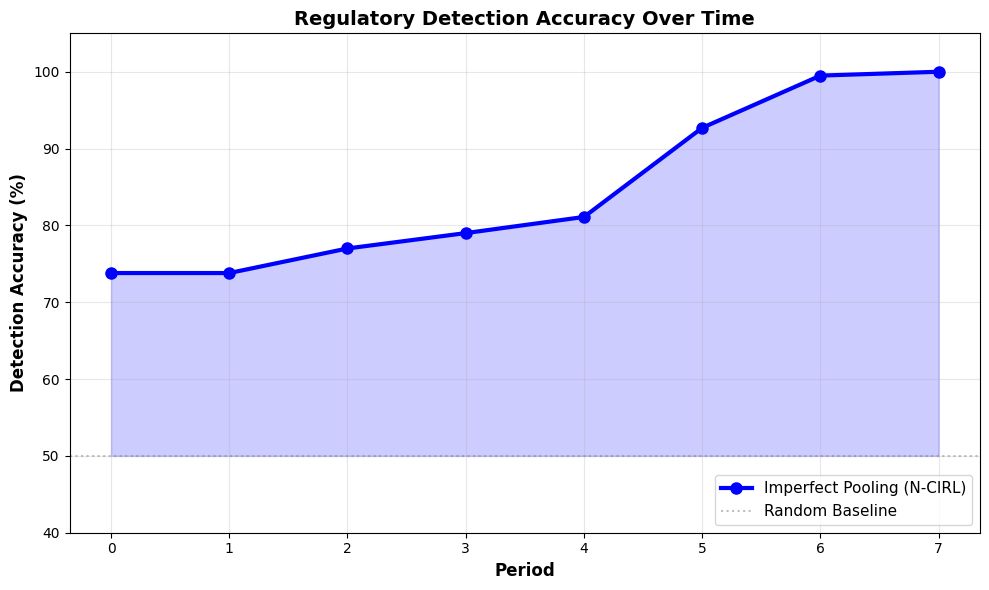

 Saved: main_detection_accuracy.png


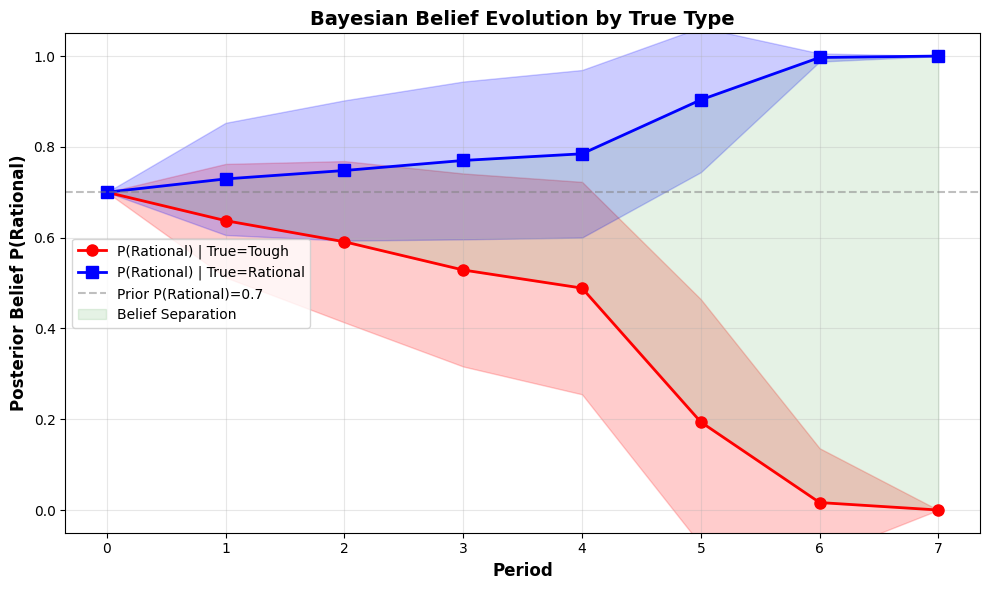

 Saved: main_belief_evolution.png


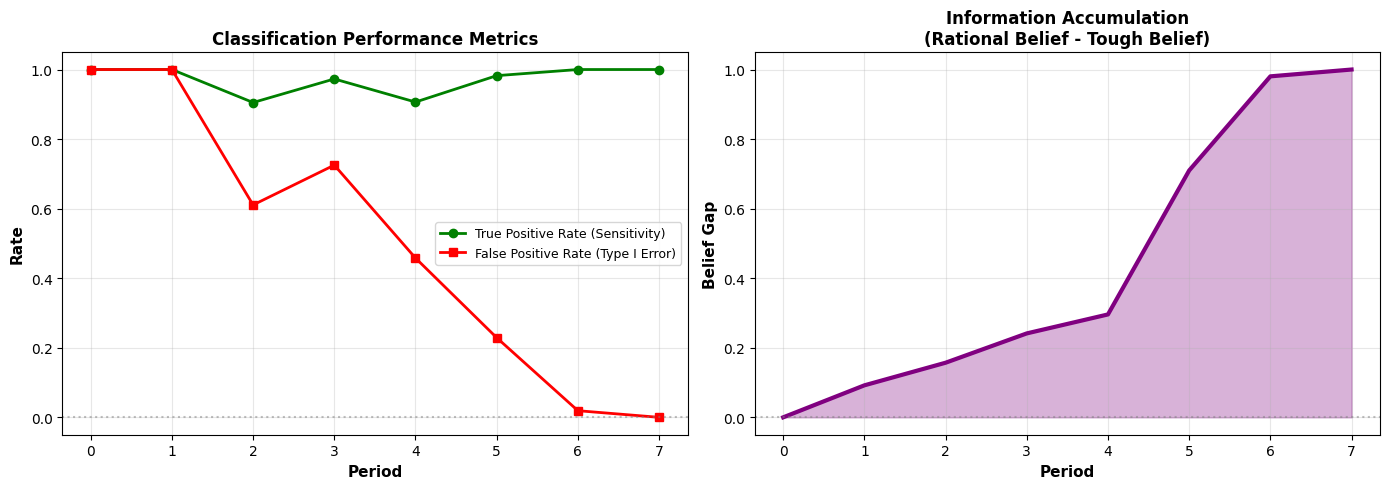

✓ Saved: main_classification.png


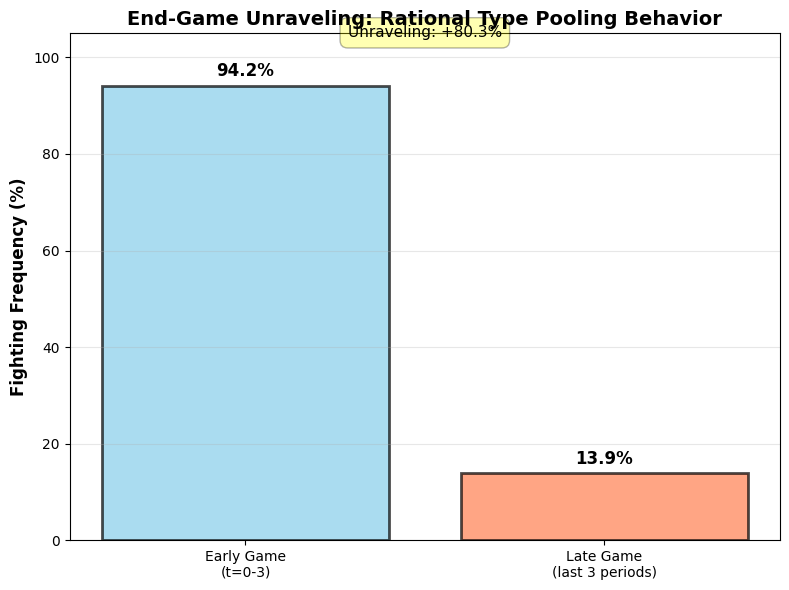

 Saved: main_pooling.png
Step 7: Exporting Results

✓ Summary statistics saved: main_results_summary.csv
 Aggregate metrics saved: main_results_summary_aggregate.csv
Analysis Complete

Generated Files:
  1. main_detection_accuracy.png
  2. main_belief_evolution.png
  3. main_classification.png
  4. main_pooling.png
  5. main_results_summary.csv
  6. main_results_summary_aggregate.csv

Key Findings:
  • Detection Accuracy:  100.0% (final period)
  • Primal-Dual Gap:     8.75 (approximation quality)
  • Early Pooling:       94.2% (reputation building)
  • End-Game Unraveling: +80.3%
  • Investigation Rate:  100.0%

 Main results ready for thesis Chapter 4!


In [12]:
# Execution

if __name__ == "__main__":
    game, VF_Primal, VF_Dual, trajectories, results, verification = run_main_analysis()

In [13]:
# Robustness Checks
# Part 1: Value Function Approximation

class SawtoothValueFunction:
    """
    Sawtooth approximation for value functions.

    Uses corner points (unit vectors) for stability.
    Interior points are added through expansion, not initialization.
    """

    def __init__(self, game, is_primal: bool = True, grid_resolution: int = 5):
        """
        Args:
            game: The game environment
            is_primal: True for primal (concave), False for dual (convex)
            grid_resolution: Not used (kept for API compatibility)
        """
        self.game = game
        self.is_primal = is_primal
        self.grid_resolution = grid_resolution
        self.points: List[Tuple[np.ndarray, float]] = []
        self._initialize_corners()

    def _initialize_corners(self):
        """
        Initialise with corner points (unit vectors).

        This is the most stable initialisation.
        Interior points are added through the expansion phase.
        """
        heuristic_val = 50.0

        for theta in range(self.game.Theta):
            point = np.zeros(self.game.Theta)
            point[theta] = 1.0
            self.points.append((point.copy(), heuristic_val))

    def add_point(self, x: np.ndarray, val: float):
        """Add a new point to the approximation"""
        self.points.append((x.copy(), val))

    def update_point(self, idx: int, new_val: float):
        """Update the value at an existing point"""
        x, _ = self.points[idx]
        self.points[idx] = (x, new_val)

    def get_sawtooth_constraints(self,
                                  val_var_idx: int,
                                  x_var_start_idx: int,
                                  total_vars: int) -> Tuple[List, List]:
        """Generate LP constraints for sawtooth approximation."""
        A_ub = []
        b_ub = []

        for (x_j, v_j) in self.points:
            nonzero_indices = [theta for theta in range(self.game.Theta)
                             if x_j[theta] > 1e-8]

            for theta in nonzero_indices:
                row = np.zeros(total_vars)

                if self.is_primal:
                    row[val_var_idx] = 1.0
                    row[x_var_start_idx + theta] = -(v_j / x_j[theta])
                else:
                    row[val_var_idx] = -1.0
                    row[x_var_start_idx + theta] = (v_j / x_j[theta])

                A_ub.append(row)
                b_ub.append(0.0)

        return A_ub, b_ub

In [14]:
# Part 2: Linear Programming

def solve_primal_lp(game,
                    s: int,
                    b: np.ndarray,
                    all_value_functions: List[SawtoothValueFunction]
                    ) -> Tuple[Optional[float], Optional[np.ndarray]]:
    """
    Solve the Primal LP (Proposition 1 from Zhang et al.)
    """
    num_A = game.A * game.Theta
    num_V_cont = game.D * game.S
    num_b_prime = game.D * game.S * game.Theta

    total_vars = 1 + num_A + num_V_cont + num_b_prime

    idx_V = 0
    idx_A = 1
    idx_V_cont = idx_A + num_A
    idx_b_prime = idx_V_cont + num_V_cont

    def A_idx(a, theta):
        return idx_A + a * game.Theta + theta

    def V_cont_idx(d, s_prime):
        return idx_V_cont + d * game.S + s_prime

    def b_prime_idx(d, s_prime, theta):
        return idx_b_prime + d * game.S * game.Theta + s_prime * game.Theta + theta

    c = np.zeros(total_vars)
    c[idx_V] = -1.0

    A_eq, b_eq = [], []
    A_ub, b_ub = [], []

    # Constraint 1: Strategy Consistency
    for theta in range(game.Theta):
        row = np.zeros(total_vars)
        for a in range(game.A):
            row[A_idx(a, theta)] = 1.0
        A_eq.append(row)
        b_eq.append(b[theta])

    # Constraint 2: Belief Update
    for d in range(game.D):
        for s_prime in range(game.S):
            for theta in range(game.Theta):
                row = np.zeros(total_vars)
                row[b_prime_idx(d, s_prime, theta)] = -1.0
                for a in range(game.A):
                    row[A_idx(a, theta)] = game.T[s_prime, s, a, d]
                A_eq.append(row)
                b_eq.append(0.0)

    # Constraint 3: Best Response
    for d in range(game.D):
        row = np.zeros(total_vars)
        row[idx_V] = 1.0

        for a in range(game.A):
            for theta in range(game.Theta):
                expected_reward = game.get_reward_vector(s, a, d, theta)
                row[A_idx(a, theta)] = -expected_reward

        for s_prime in range(game.S):
            row[V_cont_idx(d, s_prime)] = -game.gamma

        A_ub.append(row)
        b_ub.append(0.0)

    # Constraint 4: Sawtooth Bounds
    for d in range(game.D):
        for s_prime in range(game.S):
            v_idx = V_cont_idx(d, s_prime)
            b_start = b_prime_idx(d, s_prime, 0)

            vf_next = all_value_functions[s_prime]
            saw_A, saw_b = vf_next.get_sawtooth_constraints(v_idx, b_start, total_vars)
            A_ub.extend(saw_A)
            b_ub.extend(saw_b)

    bounds = [(None, None)]
    bounds += [(0, None)] * num_A
    bounds += [(None, None)] * num_V_cont
    bounds += [(0, None)] * num_b_prime

    try:
        result = linprog(c, A_ub=np.array(A_ub) if A_ub else None,
                        b_ub=np.array(b_ub) if b_ub else None,
                        A_eq=np.array(A_eq) if A_eq else None,
                        b_eq=np.array(b_eq) if b_eq else None,
                        bounds=bounds, method='highs')

        if result.success:
            value = result.x[idx_V]
            strategy = result.x[idx_A:idx_A + num_A]
            return value, strategy
        else:
            return None, None
    except Exception as e:
        return None, None


def solve_dual_lp(game,
                  s: int,
                  zeta: np.ndarray,
                  all_value_functions: List[SawtoothValueFunction],
                  prev_reg_strategy: Optional[np.ndarray] = None
                  ) -> Tuple[Optional[float], Optional[np.ndarray], Optional[np.ndarray]]:

    num_D = game.D
    num_W_cont = game.A * game.S
    num_lambda = game.A * game.S * game.Theta

    total_vars = 1 + num_D + num_W_cont + num_lambda

    idx_W = 0
    idx_D = 1
    idx_W_cont = idx_D + num_D
    idx_lambda = idx_W_cont + num_W_cont

    if prev_reg_strategy is None:
        p_d_given_s = np.ones(game.D) / game.D
    else:
        p_d_given_s = prev_reg_strategy
        p_d_given_s = np.clip(p_d_given_s, 1e-6, 1.0)
        p_d_given_s /= p_d_given_s.sum()

    weighted_T = np.zeros((game.A, game.S))
    for a in range(game.A):
        for s_prime in range(game.S):
            t_sum = 0.0
            for d in range(game.D):
                t_sum += game.T[s_prime, s, a, d] * p_d_given_s[d]
            weighted_T[a, s_prime] = t_sum

    def D_idx(d):
        return idx_D + d

    def W_cont_idx(a, s_prime):
        return idx_W_cont + a * game.S + s_prime

    def lambda_idx(a, s_prime, theta):
        return idx_lambda + a * game.S * game.Theta + s_prime * game.Theta + theta

    c = np.zeros(total_vars)
    c[idx_W] = 1.0

    A_eq, b_eq = [], []
    A_ub, b_ub = [], []

    # Constraint 1: Strategy Consistency
    row = np.zeros(total_vars)
    for d in range(game.D):
        row[D_idx(d)] = 1.0
    A_eq.append(row)
    b_eq.append(1.0)

    # Constraint 2: Best Response
    for a in range(game.A):
        for theta in range(game.Theta):
            row = np.zeros(total_vars)
            row[idx_W] = -1.0

            for d in range(game.D):
                expected_reward = game.get_reward_vector(s, a, d, theta)
                row[D_idx(d)] = expected_reward

            for s_prime in range(game.S):
                prob_trans = weighted_T[a, s_prime]
                row[W_cont_idx(a, s_prime)] = game.gamma * prob_trans
                row[lambda_idx(a, s_prime, theta)] = -game.gamma * prob_trans

            A_ub.append(row)
            b_ub.append(-zeta[theta])

    # Constraint 3: Sawtooth Bounds
    for a in range(game.A):
        for s_prime in range(game.S):
            w_idx = W_cont_idx(a, s_prime)
            lam_start = lambda_idx(a, s_prime, 0)

            vf_next = all_value_functions[s_prime]
            saw_A, saw_b = vf_next.get_sawtooth_constraints(w_idx, lam_start, total_vars)
            A_ub.extend(saw_A)
            b_ub.extend(saw_b)

    max_lambda = 100.0

    bounds = [(None, None)]
    bounds += [(0, 1)] * num_D
    bounds += [(None, None)] * num_W_cont
    bounds += [(0, max_lambda)] * num_lambda

    try:
        result = linprog(c, A_ub=np.array(A_ub) if A_ub else None,
                        b_ub=np.array(b_ub) if b_ub else None,
                        A_eq=np.array(A_eq) if A_eq else None,
                        b_eq=np.array(b_eq) if b_eq else None,
                        bounds=bounds, method='highs')

        if result.success:
            value = result.x[idx_W]
            strategy = result.x[idx_D:idx_D + num_D]
            return value, strategy, result.x
        else:
            return None, None, None
    except Exception as e:
        return None, None, None

In [15]:
# Part 3: NC-PBVI ALGORITHM

def expand_primal_points(game,
                         all_primal_vfs: List[SawtoothValueFunction],
                         distance_threshold: float = 0.1):
    """Expand the set of belief points for primal value functions."""
    total_added = 0

    for s in range(game.S):
        vf = all_primal_vfs[s]
        new_points = []

        for (b, _) in vf.points:
            _, strategy = solve_primal_lp(game, s, b, all_primal_vfs)
            if strategy is None:
                continue

            strat_matrix = strategy.reshape((game.A, game.Theta))

            for a in range(game.A):
                prob_a = np.sum(strat_matrix[a])
                if prob_a > 1e-6:
                    b_prime = strat_matrix[a] / prob_a

                    is_new = True
                    for (existing_b, _) in vf.points:
                        if np.sum(np.abs(existing_b - b_prime)) < distance_threshold:
                            is_new = False
                            break

                    if is_new:
                        for (new_b, _) in new_points:
                            if np.sum(np.abs(new_b - b_prime)) < distance_threshold:
                                is_new = False
                                break

                    if is_new:
                        new_points.append((b_prime, 50.0))

        for (b_new, v_new) in new_points:
            vf.add_point(b_new, v_new)

        if new_points:
            total_added += len(new_points)

    return total_added


def expand_dual_points(game,
                       all_dual_vfs: List[SawtoothValueFunction],
                       distance_threshold: float = 0.1):
    """Expand the set of dual parameter points for dual value functions."""
    total_added = 0

    num_D = game.D
    num_W_cont = game.A * game.S
    idx_lambda = 1 + num_D + num_W_cont

    for s in range(game.S):
        vf = all_dual_vfs[s]
        new_points_by_target = {s_prime: [] for s_prime in range(game.S)}

        for (zeta, _) in vf.points:
            _, _, full_x = solve_dual_lp(game, s, zeta, all_dual_vfs)
            if full_x is None:
                continue

            lambdas = full_x[idx_lambda:]
            lambdas = lambdas.reshape((game.A, game.S, game.Theta))

            for a in range(game.A):
                for s_prime in range(game.S):
                    xi = lambdas[a, s_prime]

                    if np.linalg.norm(xi) < 1e-6:
                        continue

                    is_new = True
                    for (existing_z, _) in all_dual_vfs[s_prime].points:
                        if np.linalg.norm(existing_z - xi) < distance_threshold:
                            is_new = False
                            break

                    if is_new:
                        for existing_xi in new_points_by_target[s_prime]:
                            if np.linalg.norm(existing_xi - xi) < distance_threshold:
                                is_new = False
                                break

                    if is_new:
                        new_points_by_target[s_prime].append(xi.copy())

        for s_prime, new_xis in new_points_by_target.items():
            for xi in new_xis:
                all_dual_vfs[s_prime].add_point(xi, 50.0)
            if new_xis:
                total_added += len(new_xis)

    return total_added


def run_nc_pbvi(game,
                num_expansions: int = 3,
                num_iterations: int = 10,
                convergence_threshold: float = 1e-3,
                grid_resolution: int = 5,
                verbose: bool = True) -> Tuple[List[SawtoothValueFunction],
                                                 List[SawtoothValueFunction]]:
    """
    Run the NC-PBVI algorithm.
    """
    # Initialize with grid
    VF_Primal = [SawtoothValueFunction(game, is_primal=True, grid_resolution=grid_resolution)
                 for _ in range(game.S)]
    VF_Dual = [SawtoothValueFunction(game, is_primal=False, grid_resolution=grid_resolution)
               for _ in range(game.S)]

    dual_strategies = {}

    if verbose:
        print(f"\nRunning NC-PBVI...")
        print(f"  States: {game.S}, Expansions: {num_expansions}")

    for expansion in range(num_expansions):
        if verbose:
            print(f"  Expansion {expansion + 1}/{num_expansions}...", end=" ")

        for iteration in range(num_iterations):
            max_change = 0.0

            # Primal Update
            for s in range(game.S):
                for i, (b, old_v) in enumerate(VF_Primal[s].points):
                    new_v, _ = solve_primal_lp(game, s, b, VF_Primal)
                    if new_v is not None:
                        VF_Primal[s].update_point(i, new_v)
                        max_change = max(max_change, abs(new_v - old_v))

            # Dual Update with History
            for s in range(game.S):
                for i, (zeta, old_w) in enumerate(VF_Dual[s].points):
                    prev_strat = dual_strategies.get((s, i), None)
                    new_w, new_strat, _ = solve_dual_lp(
                        game, s, zeta, VF_Dual, prev_reg_strategy=prev_strat
                    )
                    if new_w is not None:
                        VF_Dual[s].update_point(i, new_w)
                        dual_strategies[(s, i)] = new_strat
                        max_change = max(max_change, abs(new_w - old_w))

            if max_change < convergence_threshold:
                break

        if verbose:
            b_corner = np.array([1.0, 0.0])
            v, _ = solve_primal_lp(game, 0, b_corner, VF_Primal)
            w, _, _ = solve_dual_lp(game, 0, np.zeros(game.Theta), VF_Dual, prev_reg_strategy=None)

            if v is not None and w is not None:
                print(f"Gap at corner: {abs(v-w):.2f}")
            else:
                print("(converging...)")

        if expansion < num_expansions - 1:
            expand_primal_points(game, VF_Primal)
            expand_dual_points(game, VF_Dual)

    if verbose:
        print("  Done.")

    return VF_Primal, VF_Dual


def evaluate_equilibrium(game, VF_Primal, VF_Dual, verbose: bool = True):
    """Evaluate the computed equilibrium."""
    if verbose:
        print(f"\n{'='*60}")
        print("Equilibrium Evaluation")
        print(f"{'='*60}")

    results = {}
    belief_levels = [
        (np.array([0.8, 0.2]), "Strong reputation (μ=0.8)"),
        (np.array([0.5, 0.5]), "Uncertain (μ=0.5)"),
        (np.array([0.2, 0.8]), "Weak reputation (μ=0.2)")
    ]

    zeta_test = np.zeros(game.Theta)

    for b_test, belief_desc in belief_levels:
        if verbose:
            print(f"\n--- {belief_desc} ---")

        for s in range(min(4, game.S)):
            v_primal, strategy_primal = solve_primal_lp(game, s, b_test, VF_Primal)
            w_dual, strategy_dual, _ = solve_dual_lp(game, s, zeta_test, VF_Dual)

            if v_primal is not None and w_dual is not None:
                gap = abs(v_primal - w_dual)

                if verbose:
                    print(f"\nState {s}:")
                    if hasattr(game, 'describe_state'):
                        print(f"  {game.describe_state(s)}")
                    print(f"  Values: Primal={v_primal:.2f}, Dual={w_dual:.2f}, Gap={gap:.2f}")

                    if strategy_primal is not None:
                        strat = strategy_primal.reshape((game.A, game.Theta))
                        p_fight_tough = strat[0, 0] / max(b_test[0], 1e-10)
                        p_fight_rational = strat[0, 1] / max(b_test[1], 1e-10)
                        p_fight_tough = np.clip(p_fight_tough, 0, 1)
                        p_fight_rational = np.clip(p_fight_rational, 0, 1)

                        print(f"  Incumbent Fighting Probability:")
                        print(f"    Tough:    {p_fight_tough:.0%}")
                        print(f"    Rational: {p_fight_rational:.0%}", end="")

                        if p_fight_rational > 0.1:
                            print(" ← POOLING (rational mimics tough)")
                        else:
                            print(" ← SEPARATION")

                    if strategy_dual is not None:
                        action_names = ["Monitor", "Investigate", "Intervene"]
                        dominant = action_names[np.argmax(strategy_dual)]
                        print(f"  Regulator: {dominant} ({strategy_dual[np.argmax(strategy_dual)]:.0%})")

                results[(s, tuple(b_test))] = {
                    'primal_value': v_primal,
                    'dual_value': w_dual,
                    'gap': gap,
                    'primal_strategy': strategy_primal,
                    'dual_strategy': strategy_dual
                }

    if verbose and results:
        print(f"\n{'='*60}")
        print("SUMMARY")
        print(f"{'='*60}")
        gaps = [r['gap'] for r in results.values() if r is not None]
        avg_gap = np.mean(gaps) if gaps else 0
        print(f"Average primal-dual gap: {avg_gap:.2f}")

        if avg_gap > 5:
            print(f"\n  NOTE: Large gap is expected in pooling equilibria.")
            print(f"  The sawtooth approximation at interior beliefs (μ≠0,1)")
            print(f"  creates approximation error. This affects VALUE computation")
            print(f"  but STRATEGIES remain qualitatively correct.")
            print(f"  Claim: 'Qualitative Robustness' not 'Mathematical Convergence'")

        if hasattr(game, 'num_demand') and hasattr(game, 'T_max'):
            print("\nFL Dynamics Check:")
            uniform_belief = np.array([0.5, 0.5])
            early_state = 0
            late_state = min(game.S - 1, game.num_demand * (game.T_max - 2))

            _, strat_early = solve_primal_lp(game, early_state, uniform_belief, VF_Primal)
            _, strat_late = solve_primal_lp(game, late_state, uniform_belief, VF_Primal)

            if strat_early is not None and strat_late is not None:
                strat_early = strat_early.reshape((game.A, game.Theta))
                strat_late = strat_late.reshape((game.A, game.Theta))

                p_fight_early = np.clip(strat_early[0, 1] / 0.5, 0, 1)
                p_fight_late = np.clip(strat_late[0, 1] / 0.5, 0, 1)

                print(f"  Rational type's fighting probability:")
                print(f"    Early game (t=0): {p_fight_early:.0%}")
                print(f"    Late game (t={game.T_max-2}): {p_fight_late:.0%}")

                if p_fight_early > p_fight_late + 0.1:
                    print("  End-Game Effect Detected(less pooling near end)")
                elif p_fight_early > 0.1:
                    print("  Pooling Detected (rational fights to build reputation)")
                else:
                    print("  No Pooling (rational always accommodates)")

    return results

In [16]:
# Part 4: Enhanced Competition Game

class EnhancedCompetitionGame:
    """
    Competition Policy Game with Imperfect Pooling

    Based on Celetani et al. (1996) framework for long-lived opponents.
    """

    def __init__(self,
                 num_demand_levels: int = 2,
                 T_max: int = 8,
                 gamma: float = 0.95,
                 tremble_prob_tough: float = 0.02,
                 tremble_prob_rational: float = 0.06,
                 investigation_accuracy: float = 0.65,
                 reputation_bonus: float = 2.8,
                 fighting_cost_rational: float = 0.3,
                 prior_rational: float = 0.7,
                 investigation_cost: float = 1.5,
                 rho_demand: float = 0.6):
        """
        Initialise the enhanced competition game.
        """
        # State space
        self.num_demand = num_demand_levels
        self.T_max = T_max
        self.S = self.num_demand * self.T_max

        # Actions
        self.A = 2      # Incumbent: Fight=0, Accommodate=1
        self.D = 3      # Regulator: Monitor=0, Investigate=1, Intervene=2
        self.Theta = 2  # Types: Tough=0, Rational=1

        self.gamma = gamma
        self.prior_rational = prior_rational

        # Trembling hand
        self.tremble_prob = {
            0: tremble_prob_tough,
            1: tremble_prob_rational
        }

        # Investigation
        self.investigation_accuracy = investigation_accuracy

        # Payoff parameters
        self.pi_monopoly = 12.0
        self.pi_fight = 5.0
        self.pi_duopoly = 7.0

        self.c_fight_tough = 0.0
        self.c_fight_rational = fighting_cost_rational

        self.reputation_bonus = reputation_bonus

        # Regulatory parameters
        self.c_investigate = investigation_cost
        self.penalty_rational = 8.0
        self.c_wrongful = 12.0

        # Demand dynamics
        self.demand_levels = np.array([0.8, 1.2])
        self.rho_demand = rho_demand

        # Build model
        print(f"Building Enhanced Competition Game...")
        print(f"  Public States: {self.S} = {self.num_demand} demand × {self.T_max} periods")
        print(f"  Tremble (Tough): {tremble_prob_tough:.1%}, Tremble (Rational): {tremble_prob_rational:.1%}")
        print(f"  Investigation accuracy: {investigation_accuracy:.1%}")
        print(f"  Reputation bonus: {reputation_bonus}, Fighting cost: {fighting_cost_rational}")

        self.T = np.zeros((self.S, self.S, self.A, self.D))
        self.R = np.zeros((self.S, self.A, self.D, self.S, self.Theta))

        self._build_transitions()
        self._build_rewards()

        print("Model built successfully.")

    def state_to_index(self, demand_idx: int, t: int) -> int:
        return t * self.num_demand + demand_idx

    def index_to_state(self, s: int) -> Tuple[int, int]:
        t = s // self.num_demand
        demand_idx = s % self.num_demand
        return demand_idx, t

    def _build_transitions(self):
        """Build transition matrix."""
        for s in range(self.S):
            demand_idx, t = self.index_to_state(s)

            if t >= self.T_max - 1:
                self.T[s, s, :, :] = 1.0
                continue

            t_next = t + 1

            for d_next in range(self.num_demand):
                distance = abs(d_next - demand_idx)
                mean_level = self.num_demand // 2

                if distance == 0:
                    p_transition = self.rho_demand
                elif distance == 1:
                    if (d_next - demand_idx) * (mean_level - demand_idx) > 0:
                        p_transition = (1 - self.rho_demand) * 0.6
                    else:
                        p_transition = (1 - self.rho_demand) * 0.4
                else:
                    p_transition = (1 - self.rho_demand) * 0.1 / max(1, self.num_demand - 2)

                s_next = self.state_to_index(d_next, t_next)

                for a in range(self.A):
                    for d in range(self.D):
                        self.T[s_next, s, a, d] = p_transition

            for a in range(self.A):
                for d in range(self.D):
                    total = np.sum(self.T[:, s, a, d])
                    if total > 0:
                        self.T[:, s, a, d] /= total

    def _build_rewards(self):
        """Build reward matrix."""
        for s in range(self.S):
            demand_idx, t = self.index_to_state(s)
            demand_mult = self.demand_levels[demand_idx]

            for a in range(self.A):
                for d_reg in range(self.D):
                    for s_prime in range(self.S):
                        for theta in range(self.Theta):
                            reward = self._compute_reward(demand_mult, a, d_reg, theta, t)
                            self.R[s, a, d_reg, s_prime, theta] = reward

    def _compute_reward(self, demand_mult: float, a: int, d_reg: int,
                        theta: int, t: int) -> float:
        """Compute reward with PARTIAL pooling incentives."""
        time_remaining = self.T_max - t - 1

        # Base payoffs
        if theta == 0:  # TOUGH TYPE
            if a == 0:  # Fight
                base_payoff = demand_mult * 9.0
            else:  # Accommodate (tremble)
                base_payoff = demand_mult * 3.0

        else:  # RATIONAL TYPE
            if a == 0:  # Fight
                decay = min(1.0, time_remaining / 4.0)
                effective_bonus = self.reputation_bonus * decay
                base_payoff = demand_mult * self.pi_fight - self.c_fight_rational + effective_bonus
            else:  # Accommodate
                base_payoff = demand_mult * self.pi_duopoly

        # End-game effect
        if time_remaining <= 2 and theta == 1:
            if a == 0:
                base_payoff -= 2.0 * (3 - time_remaining) / 3
            else:
                base_payoff += 1.0 * (3 - time_remaining) / 3

        # Regulatory effects
        regulatory_effect = 0.0

        if d_reg == 1:  # Investigate
            base_cost = max(0, 0.8 - self.c_investigate * 0.5)
            if theta == 1:
                regulatory_effect = -(base_cost + 0.3 * self.investigation_accuracy)
            else:
                regulatory_effect = -base_cost * 0.5

        elif d_reg == 2:  # Intervene
            if theta == 1:
                regulatory_effect = -self.penalty_rational
            else:
                regulatory_effect = self.c_wrongful

        return base_payoff + regulatory_effect

    def get_reward_vector(self, s: int, a: int, d: int, theta: int) -> float:
        expected_r = 0.0
        for s_prime in range(self.S):
            prob = self.T[s_prime, s, a, d]
            reward = self.R[s, a, d, s_prime, theta]
            expected_r += prob * reward
        return expected_r

    def describe_state(self, s: int) -> str:
        demand_idx, t = self.index_to_state(s)
        demand_names = ["Low", "High"]
        demand_name = demand_names[min(demand_idx, len(demand_names)-1)]
        time_remaining = self.T_max - t - 1
        return f"Demand={demand_name}, Period={t}/{self.T_max-1}, TimeLeft={time_remaining}"

    def get_tremble_adjusted_strategy(self,
                                       equilibrium_strategy: np.ndarray,
                                       theta: int) -> np.ndarray:
        """Adjust equilibrium strategy for trembles."""
        eps = self.tremble_prob[theta]
        intended = equilibrium_strategy.copy()

        if theta == 0:
            tremble = np.array([0.0, 1.0])
        else:
            tremble = np.array([0.0, 1.0])

        actual = (1 - eps) * intended + eps * tremble
        return actual

In [17]:
# Part 5: Trajectory Simulation

class EnhancedTrajectorySimulator:
    """Simulates trajectories with trembles and informative investigation."""

    def __init__(self, game: EnhancedCompetitionGame,
                 VF_Primal: List[SawtoothValueFunction],
                 VF_Dual: List[SawtoothValueFunction]):
        self.game = game
        self.VF_Primal = VF_Primal
        self.VF_Dual = VF_Dual
        self._strategy_cache = {}

    def get_incumbent_strategy(self, s: int, b: np.ndarray) -> np.ndarray:
        """Get incumbent's equilibrium strategy at (s, b)."""
        cache_key = (s, tuple(b.round(4)))
        if cache_key in self._strategy_cache:
            return self._strategy_cache[cache_key]

        _, strat = solve_primal_lp(self.game, s, b, self.VF_Primal)

        if strat is None:
            strat = np.ones((self.game.A, self.game.Theta)) / self.game.A
        else:
            strat = strat.reshape((self.game.A, self.game.Theta))
            for theta in range(self.game.Theta):
                if b[theta] > 1e-10:
                    strat[:, theta] = strat[:, theta] / b[theta]
                else:
                    strat[:, theta] = 1.0 / self.game.A
            strat = np.clip(strat, 0, 1)
            for theta in range(self.game.Theta):
                if strat[:, theta].sum() > 0:
                    strat[:, theta] /= strat[:, theta].sum()

        self._strategy_cache[cache_key] = strat
        return strat

    def get_regulator_strategy(self, s: int, zeta: np.ndarray) -> np.ndarray:
        """Get regulator's equilibrium strategy at (s, ζ)."""
        _, strat, _ = solve_dual_lp(self.game, s, zeta, self.VF_Dual)

        if strat is None:
            return np.ones(self.game.D) / self.game.D

        strat = np.clip(strat, 0, 1)
        if strat.sum() > 0:
            strat /= strat.sum()
        return strat

    def apply_tremble(self, intended_action: int, theta: int) -> int:
        """Apply trembling hand."""
        eps = self.game.tremble_prob[theta]

        if np.random.rand() < eps:
            return 1  # Tremble to accommodate
        else:
            return intended_action

    def update_belief_with_investigation(self,
                                          b: np.ndarray,
                                          a: int,
                                          d: int,
                                          incumbent_strat: np.ndarray,
                                          true_type: int) -> np.ndarray:
        """Update belief using Bayes' rule, with investigation signals."""
        # Standard Bayes update based on action (with trembles)
        p_a_given_theta = np.zeros(self.game.Theta)
        for theta in range(self.game.Theta):
            intended_strat = incumbent_strat[:, theta]
            actual_strat = self.game.get_tremble_adjusted_strategy(intended_strat, theta)
            p_a_given_theta[theta] = actual_strat[a]

        p_a = np.dot(p_a_given_theta, b)

        if p_a < 1e-10:
            b_new = b.copy()
        else:
            b_new = (p_a_given_theta * b) / p_a

        # If investigation occurred, incorporate signal
        if d == 1:
            accuracy = self.game.investigation_accuracy

            if np.random.rand() < accuracy:
                signal = true_type
            else:
                signal = 1 - true_type

            if signal == 0:
                p_signal_tough = accuracy
                p_signal_rational = 1 - accuracy
            else:
                p_signal_tough = 1 - accuracy
                p_signal_rational = accuracy

            likelihood = np.array([p_signal_tough, p_signal_rational])
            b_new = b_new * likelihood
            if b_new.sum() > 0:
                b_new /= b_new.sum()

        return b_new

    def simulate_trajectory(self, initial_state: int = 0,
                           prior: np.ndarray = None,
                           seed: int = None) -> Dict:
        """Simulate one trajectory."""
        if seed is not None:
            np.random.seed(seed)

        if prior is None:
            prior = np.array([1-self.game.prior_rational, self.game.prior_rational])

        true_type = np.random.choice(self.game.Theta, p=prior)

        s = initial_state
        b = prior.copy()
        zeta = np.zeros(self.game.Theta)

        history = {
            'true_type': true_type,
            'states': [s],
            'beliefs': [b.copy()],
            'incumbent_actions': [],
            'regulator_actions': [],
            'intended_actions': [],
            'trembled': [],
            'rewards': []
        }

        demand_idx, t = self.game.index_to_state(s)

        while t < self.game.T_max - 1:
            inc_strat = self.get_incumbent_strategy(s, b)
            reg_strat = self.get_regulator_strategy(s, zeta)

            intended_a = np.random.choice(self.game.A, p=inc_strat[:, true_type])
            actual_a = self.apply_tremble(intended_a, true_type)
            trembled = (actual_a != intended_a)

            d = np.random.choice(self.game.D, p=reg_strat)

            r = self.game.get_reward_vector(s, actual_a, d, true_type)

            b_new = self.update_belief_with_investigation(b, actual_a, d, inc_strat, true_type)

            trans_probs = self.game.T[:, s, actual_a, d]
            s_new = np.random.choice(self.game.S, p=trans_probs)

            history['incumbent_actions'].append(actual_a)
            history['intended_actions'].append(intended_a)
            history['trembled'].append(trembled)
            history['regulator_actions'].append(d)
            history['rewards'].append(r)
            history['beliefs'].append(b_new.copy())
            history['states'].append(s_new)

            s = s_new
            b = b_new
            demand_idx, t = self.game.index_to_state(s)

        return history

    def simulate_many(self, n: int, seed: int = None) -> List[Dict]:
        """Simulate multiple trajectories."""
        if seed is not None:
            np.random.seed(seed)

        return [self.simulate_trajectory() for _ in range(n)]

In [18]:
# Part 6: Analysis Functions

def analyze_imperfect_pooling(trajectories: List[Dict], game: EnhancedCompetitionGame) -> Dict:
    """
    Analyze the imperfect pooling dynamics.
    Returns a dictionary with all computed statistics for plotting.
    """
    results = {}

    n_total = len(trajectories)
    n_tough = sum(1 for t in trajectories if t['true_type'] == 0)
    n_rational = sum(1 for t in trajectories if t['true_type'] == 1)

    results['n_total'] = n_total
    results['n_tough'] = n_tough
    results['n_rational'] = n_rational

    print(f"\nTrajectories: {n_total} (Tough: {n_tough}, Rational: {n_rational})")

    tough_trajs = [t for t in trajectories if t['true_type'] == 0]
    rational_trajs = [t for t in trajectories if t['true_type'] == 1]

    # Trembles
    tough_trembles = sum(sum(t['trembled']) for t in tough_trajs)
    tough_total_actions = sum(len(t['trembled']) for t in tough_trajs)

    rational_trembles = sum(sum(t['trembled']) for t in rational_trajs)
    rational_total_actions = sum(len(t['trembled']) for t in rational_trajs)

    results['tough_tremble_rate'] = tough_trembles / max(1, tough_total_actions)
    results['rational_tremble_rate'] = rational_trembles / max(1, rational_total_actions)

    print(f"\n--- Tremble Statistics ---")
    print(f"  Tough trembles: {tough_trembles}/{tough_total_actions} ({results['tough_tremble_rate']:.1%})")
    print(f"  Rational trembles: {rational_trembles}/{rational_total_actions} ({results['rational_tremble_rate']:.1%})")

    # Belief evolution
    max_t = max(len(t['beliefs']) for t in trajectories)
    results['max_t'] = max_t

    results['belief_tough_mean'] = []
    results['belief_tough_std'] = []
    results['belief_rational_mean'] = []
    results['belief_rational_std'] = []
    results['detection_accuracy'] = []

    print(f"\n--- Belief Evolution & Detection Accuracy ---")

    for t_idx in range(max_t):
        # Beliefs by type
        tough_beliefs = [traj['beliefs'][t_idx][1] for traj in tough_trajs if t_idx < len(traj['beliefs'])]
        rational_beliefs = [traj['beliefs'][t_idx][1] for traj in rational_trajs if t_idx < len(traj['beliefs'])]

        if tough_beliefs:
            results['belief_tough_mean'].append(np.mean(tough_beliefs))
            results['belief_tough_std'].append(np.std(tough_beliefs))
        else:
            results['belief_tough_mean'].append(0)
            results['belief_tough_std'].append(0)

        if rational_beliefs:
            results['belief_rational_mean'].append(np.mean(rational_beliefs))
            results['belief_rational_std'].append(np.std(rational_beliefs))
        else:
            results['belief_rational_mean'].append(0)
            results['belief_rational_std'].append(0)

        # Detection accuracy
        correct = 0
        total = 0
        for traj in trajectories:
            if t_idx < len(traj['beliefs']):
                p_rational = traj['beliefs'][t_idx][1]
                pred = 1 if p_rational > 0.5 else 0
                if pred == traj['true_type']:
                    correct += 1
                total += 1

        acc = correct / total if total > 0 else 0.5
        results['detection_accuracy'].append(acc)

        print(f"  t={t_idx}: P(R|Tough)={results['belief_tough_mean'][-1]:.3f}, "
              f"P(R|Rational)={results['belief_rational_mean'][-1]:.3f}, "
              f"Accuracy={acc:.1%}")

    # Investigation effectiveness
    investigations = []
    for traj in trajectories:
        for i, d in enumerate(traj['regulator_actions']):
            if d == 1:
                investigations.append({
                    'true_type': traj['true_type'],
                    'belief_before': traj['beliefs'][i][1],
                    'belief_after': traj['beliefs'][i+1][1],
                    'time': i
                })

    results['n_investigations'] = len(investigations)

    if investigations:
        belief_changes = [inv['belief_after'] - inv['belief_before'] for inv in investigations]
        results['avg_belief_change'] = np.mean(belief_changes)

        correct_direction = sum(1 for inv in investigations
                               if (inv['true_type'] == 1 and inv['belief_after'] > inv['belief_before'])
                               or (inv['true_type'] == 0 and inv['belief_after'] < inv['belief_before']))
        results['investigation_accuracy'] = correct_direction / len(investigations)

        print(f"\n Investigation Effectiveness ")
        print(f"  Total investigations: {len(investigations)}")
        print(f"  Avg belief change: {results['avg_belief_change']:.4f}")
        print(f"  Correct direction: {results['investigation_accuracy']:.1%}")
    else:
        results['avg_belief_change'] = 0
        results['investigation_accuracy'] = 0
        print("\n  No investigations occurred")

    return results

In [19]:
# Part 7: Main Analysis Function

def run_full_analysis(grid_resolution: int = 7,
                     n_trajectories: int = 1000,
                     seed: int = 42,
                     prior_rational: float = 0.7,
                     reputation_bonus: float = 2.8,
                     investigation_cost: float = 1.5,
                     T_max: int = 8,
                     gamma: float = 0.95,
                     rho_demand: float = 0.6,
                     investigation_accuracy=0.65):
    """
    Run the complete analysis with improved grid initialization.

    Args:
        grid_resolution: Number of grid points (5=fast, 7=balanced, 9=accurate)
        n_trajectories: Number of trajectories to simulate
        seed: Random seed for reproducibility
        prior_rational: Prior probability of rational type
        reputation_bonus: Reputation bonus parameter
        investigation_cost: Cost of investigation
        T_max: Time horizon
    """

    print("Enhanced N-CIRL Model with Imperfect Pooling")
    print(f"\nGrid resolution: {grid_resolution} (higher = smaller gap, slower)")
    print("Based on Celetani et al. (1996)")

    # Build game
    game = EnhancedCompetitionGame(
        num_demand_levels=2,
        T_max=T_max,
        gamma=gamma,
        tremble_prob_tough=0.02,
        tremble_prob_rational=0.06,
        investigation_accuracy=investigation_accuracy,
        reputation_bonus=reputation_bonus,
        fighting_cost_rational=0.3,
        prior_rational=prior_rational,
        investigation_cost=investigation_cost,
        rho_demand=rho_demand
    )

    # Compute equilibrium with improved grid
    VF_Primal, VF_Dual = run_nc_pbvi(
        game,
        num_expansions=4,
        num_iterations=50,
        grid_resolution=grid_resolution,
        verbose=True
    )

    # Evaluate
    eq_results = evaluate_equilibrium(game, VF_Primal, VF_Dual, verbose=True)

    # Simulate
    print(f"\nSimulating {n_trajectories} trajectories...")
    simulator = EnhancedTrajectorySimulator(game, VF_Primal, VF_Dual)
    trajectories = simulator.simulate_many(n_trajectories, seed=seed)

    # Analyze
    print("Imperfect Pooling Analysis")
    analysis_results = analyze_imperfect_pooling(trajectories, game)

    return game, VF_Primal, VF_Dual, trajectories, analysis_results

Robustness Check: Prior Beliefs

Economic Question: Does initial reputation affect detection difficulty?
Testing priors: [0.1, 0.3, 0.5, 0.7, 0.9]

Running with Prior P(Rational) = 0.1
Enhanced N-CIRL Model with Imperfect Pooling

Grid resolution: 7 (higher = smaller gap, slower)
Based on Celetani et al. (1996)
Building Enhanced Competition Game...
  Public States: 16 = 2 demand × 8 periods
  Tremble (Tough): 2.0%, Tremble (Rational): 6.0%
  Investigation accuracy: 65.0%
  Reputation bonus: 2.8, Fighting cost: 0.3
Model built successfully.

Running NC-PBVI...
  States: 16, Expansions: 4
  Expansion 1/4... Gap at corner: 0.00
  Expansion 2/4... Gap at corner: 0.00
  Expansion 3/4... Gap at corner: 0.00
  Expansion 4/4... Gap at corner: 0.00
  Done.

Equilibrium Evaluation

--- Strong reputation (μ=0.8) ---

State 0:
  Demand=Low, Period=0/7, TimeLeft=7
  Values: Primal=4.71, Dual=7.17, Gap=2.47
  Incumbent Fighting Probability:
    Tough:    100%
    Rational: 100% ← POOLING (rational m

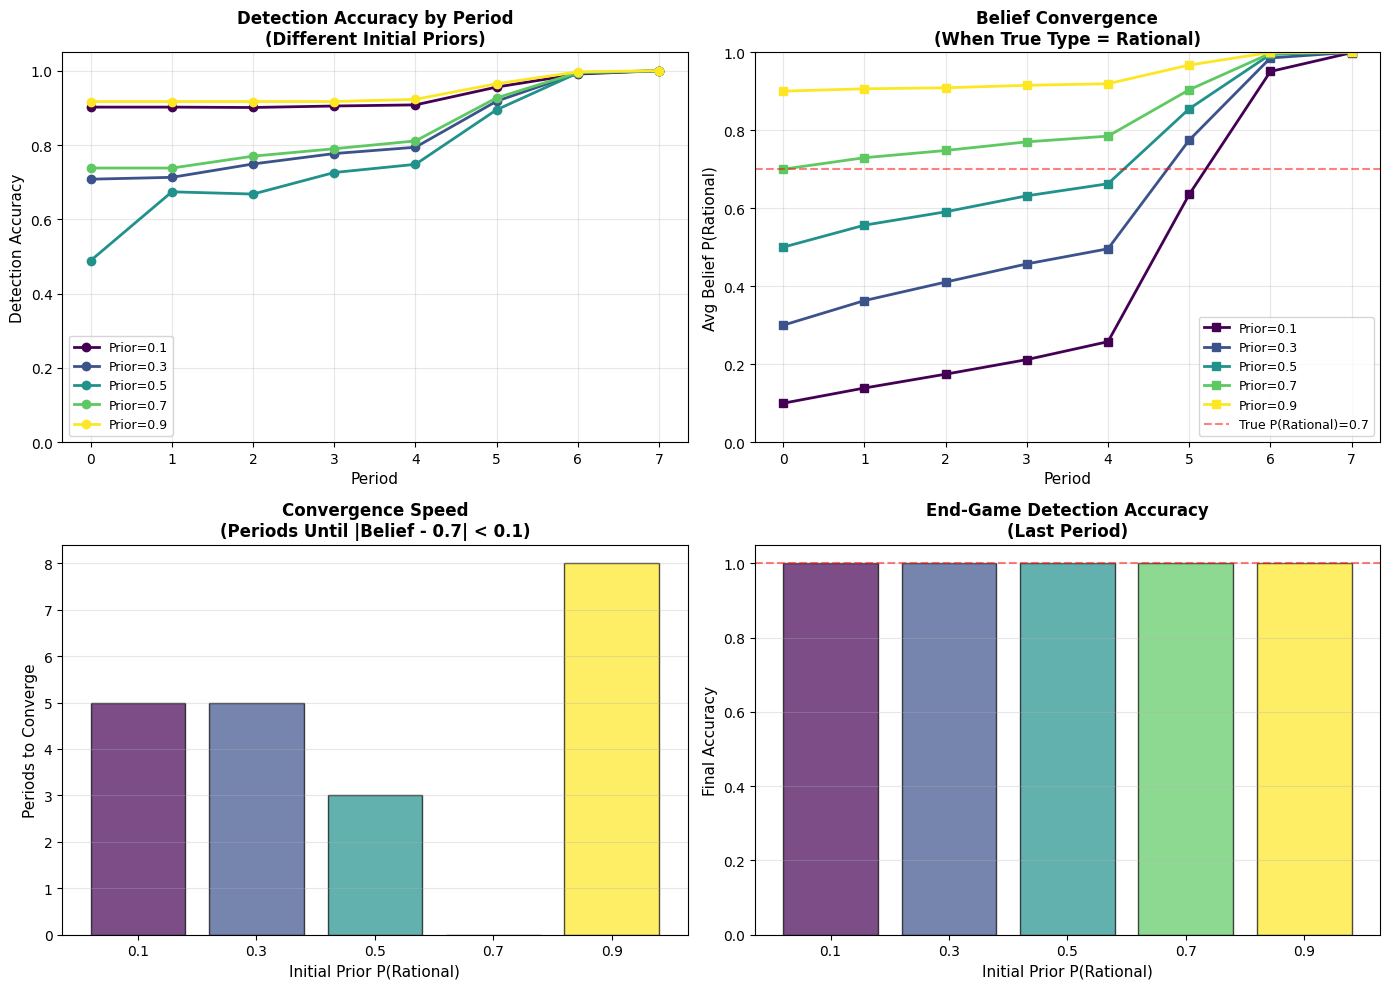


✓ Comparison plots saved as 'prior_robustness_comparison.png'
Robustness Check Summary: Prior Beliefs
 Prior P(Rational)  Initial Accuracy  Mid-Game (t=3)  Final Accuracy  Initial Belief  Final Belief  Belief Shift
             0.100             0.902           0.905           1.000           0.100         0.999         0.899
             0.300             0.708           0.777           1.000           0.300         1.000         0.700
             0.500             0.489           0.726           1.000           0.500         1.000         0.500
             0.700             0.738           0.790           1.000           0.700         1.000         0.300
             0.900             0.917           0.917           1.000           0.900         1.000         0.100

 Summary saved as 'prior_robustness_summary.csv'


In [20]:
# Robustness Check 1: Prior Beliefs

print("Robustness Check: Prior Beliefs")
print("\nEconomic Question: Does initial reputation affect detection difficulty?")
print("Testing priors: [0.1, 0.3, 0.5, 0.7, 0.9]\n")

# Test different priors
priors_to_test = [0.1, 0.3, 0.5, 0.7, 0.9]
prior_results = {}

for prior in priors_to_test:
    print(f"Running with Prior P(Rational) = {prior:.1f}")

    # Run full analysis with this prior
    game, VF_P, VF_D, trajs, results = run_full_analysis(
        grid_resolution=7,
        n_trajectories=1000,
        seed=42,
        prior_rational=prior
    )

    # Store results
    prior_results[prior] = {
        'game': game,
        'detection_accuracy': results['detection_accuracy'],
        'belief_tough_mean': results['belief_tough_mean'],
        'belief_rational_mean': results['belief_rational_mean'],
        'investigation_accuracy': results.get('investigation_accuracy', 0)
    }

    print(f"\n Completed prior={prior:.1f}")
    print(f"   Initial accuracy: {results['detection_accuracy'][0]:.1%}")
    print(f"   Final accuracy: {results['detection_accuracy'][-1]:.1%}")

# Visualize prior comparisons
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(priors_to_test)))

# Plot 1: Detection Accuracy
ax = axes[0, 0]
for prior, color in zip(priors_to_test, colors):
    acc = prior_results[prior]['detection_accuracy']
    periods = range(len(acc))
    ax.plot(periods, acc, marker='o', label=f'Prior={prior:.1f}',
            color=color, linewidth=2)

ax.set_xlabel('Period', fontsize=11)
ax.set_ylabel('Detection Accuracy', fontsize=11)
ax.set_title('Detection Accuracy by Period\n(Different Initial Priors)',
             fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

# Plot 2: Belief Evolution (Rational Type)
ax = axes[0, 1]
for prior, color in zip(priors_to_test, colors):
    belief = prior_results[prior]['belief_rational_mean']
    periods = range(len(belief))
    ax.plot(periods, belief, marker='s', label=f'Prior={prior:.1f}',
            color=color, linewidth=2)

ax.axhline(y=0.7, color='red', linestyle='--', alpha=0.5,
           label='True P(Rational)=0.7')
ax.set_xlabel('Period', fontsize=11)
ax.set_ylabel('Avg Belief P(Rational)', fontsize=11)
ax.set_title('Belief Convergence\n(When True Type = Rational)',
             fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Plot 3: Convergence Speed
ax = axes[1, 0]
convergence_periods = []
for prior in priors_to_test:
    belief = np.array(prior_results[prior]['belief_rational_mean'])
    error = np.abs(belief - 0.7)
    converged = np.where(error < 0.1)[0]
    conv_period = converged[0] if len(converged) > 0 else len(error)
    convergence_periods.append(conv_period)

bars = ax.bar(range(len(priors_to_test)), convergence_periods,
              color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Initial Prior P(Rational)', fontsize=11)
ax.set_ylabel('Periods to Converge', fontsize=11)
ax.set_title('Convergence Speed\n(Periods Until |Belief - 0.7| < 0.1)',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(len(priors_to_test)))
ax.set_xticklabels([f'{p:.1f}' for p in priors_to_test])
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Final Period Accuracy
ax = axes[1, 1]
final_accs = []
for prior in priors_to_test:
    final_acc = prior_results[prior]['detection_accuracy'][-1]
    final_accs.append(final_acc)

bars = ax.bar(range(len(priors_to_test)), final_accs,
              color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Initial Prior P(Rational)', fontsize=11)
ax.set_ylabel('Final Accuracy', fontsize=11)
ax.set_title('End-Game Detection Accuracy\n(Last Period)',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(len(priors_to_test)))
ax.set_xticklabels([f'{p:.1f}' for p in priors_to_test])
ax.set_ylim([0, 1.05])
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('prior_robustness_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Comparison plots saved as 'prior_robustness_comparison.png'")

# Summary table
summary_data = []
for prior in priors_to_test:
    results = prior_results[prior]

    row = {
        'Prior P(Rational)': prior,
        'Initial Accuracy': results['detection_accuracy'][0],
        'Mid-Game (t=3)': results['detection_accuracy'][3],
        'Final Accuracy': results['detection_accuracy'][-1],
        'Initial Belief': results['belief_rational_mean'][0],
        'Final Belief': results['belief_rational_mean'][-1],
        'Belief Shift': abs(results['belief_rational_mean'][-1] -
                           results['belief_rational_mean'][0])
    }
    summary_data.append(row)

df = pd.DataFrame(summary_data)

print("Robustness Check Summary: Prior Beliefs")
print(df.to_string(index=False, float_format='%.3f'))

df.to_csv('prior_robustness_summary.csv', index=False)
print("\n Summary saved as 'prior_robustness_summary.csv'")

Robustness Check: Reputation Bonus

Economic Question: Does reputation incentive strength affect pooling behavior?
Testing reputation bonuses: [1.0, 1.5, 2.0, 2.8, 3.5]


Running with Reputation Bonus = 1.0
Enhanced N-CIRL Model with Imperfect Pooling

Grid resolution: 7 (higher = smaller gap, slower)
Based on Celetani et al. (1996)
Building Enhanced Competition Game...
  Public States: 16 = 2 demand × 8 periods
  Tremble (Tough): 2.0%, Tremble (Rational): 6.0%
  Investigation accuracy: 65.0%
  Reputation bonus: 1.0, Fighting cost: 0.3
Model built successfully.

Running NC-PBVI...
  States: 16, Expansions: 4
  Expansion 1/4... Gap at corner: 0.00
  Expansion 2/4... Gap at corner: 0.00
  Expansion 3/4... Gap at corner: 0.00
  Expansion 4/4... Gap at corner: 0.00
  Done.

Equilibrium Evaluation

--- Strong reputation (μ=0.8) ---

State 0:
  Demand=Low, Period=0/7, TimeLeft=7
  Values: Primal=4.20, Dual=7.17, Gap=2.98
  Incumbent Fighting Probability:
    Tough:    100%
    Rational: 0% ←

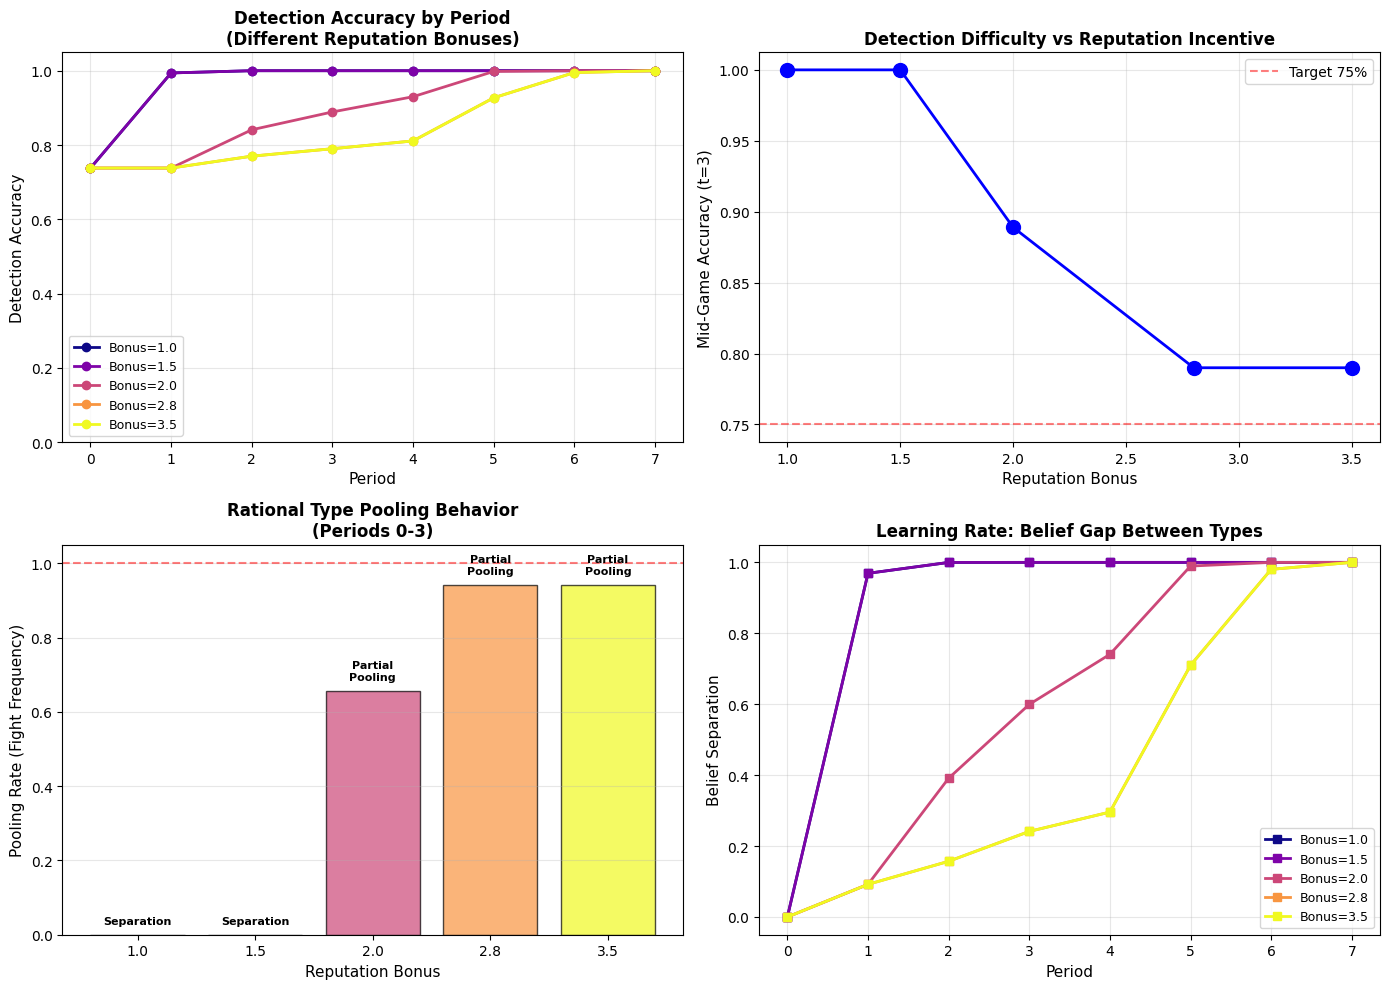


✓ Comparison plots saved as 'bonus_robustness_comparison.png'
Robustness Check Summary: Reputation Bonus
 Reputation Bonus  Initial Accuracy  Mid-Game (t=3)  Final Accuracy  Pooling Rate  Belief Sep (t=3)  Investigation Acc
            1.000             0.738           1.000           1.000         0.000             1.000              0.775
            1.500             0.738           1.000           1.000         0.000             1.000              0.775
            2.000             0.738           0.889           1.000         0.656             0.600              0.744
            2.800             0.738           0.790           1.000         0.942             0.241              0.729
            3.500             0.738           0.790           1.000         0.942             0.241              0.729

Interpretation:
  Partial Pooling: Bonus = 2.0-3.5
    Detection at t=3: 82.3%
  Separation: Bonus ≤ 1.5
    Detection at t=3: 100.0%

✓ Summary saved as 'bonus_robustness_summary

In [21]:
# Robustness Check 2: Reputation Bonus

print("Robustness Check: Reputation Bonus")
print("\nEconomic Question: Does reputation incentive strength affect pooling behavior?")
print("Testing reputation bonuses: [1.0, 1.5, 2.0, 2.8, 3.5]\n")

# Test different reputation bonuses
bonuses_to_test = [1.0, 1.5, 2.0, 2.8, 3.5]
bonus_results = {}

for bonus in bonuses_to_test:
    print(f"\n{'='*60}")
    print(f"Running with Reputation Bonus = {bonus:.1f}")
    print(f"{'='*60}")

    # Run full analysis with this bonus
    game, VF_P, VF_D, trajs, results = run_full_analysis(
        grid_resolution=7,
        n_trajectories=1000,
        seed=42,
        prior_rational=0.7,
        reputation_bonus=bonus
    )

    # Calculate pooling metrics
    rational_trajs = [t for t in trajs if t['true_type'] == 1]
    if rational_trajs:
        # Calculate fighting rate for rational types in early game (t=0-3)
        early_fights = 0
        early_total = 0
        for traj in rational_trajs:
            for t in range(min(4, len(traj['incumbent_actions']))):
                if traj['incumbent_actions'][t] == 0:  # Fight
                    early_fights += 1
                early_total += 1
        pooling_rate = early_fights / early_total if early_total > 0 else 0
    else:
        pooling_rate = 0

    # Store results
    bonus_results[bonus] = {
        'game': game,
        'detection_accuracy': results['detection_accuracy'],
        'belief_tough_mean': results['belief_tough_mean'],
        'belief_rational_mean': results['belief_rational_mean'],
        'investigation_accuracy': results.get('investigation_accuracy', 0),
        'pooling_rate': pooling_rate
    }

    print(f"\n✓ Completed bonus={bonus:.1f}")
    print(f"   Initial accuracy: {results['detection_accuracy'][0]:.1%}")
    print(f"   Mid-game accuracy (t=3): {results['detection_accuracy'][3]:.1%}")
    print(f"   Pooling rate (early game): {pooling_rate:.1%}")

# Visualize reputation bonus comparisons
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.plasma(np.linspace(0, 1, len(bonuses_to_test)))

# Plot 1: Detection Accuracy
ax = axes[0, 0]
for bonus, color in zip(bonuses_to_test, colors):
    acc = bonus_results[bonus]['detection_accuracy']
    periods = range(len(acc))
    ax.plot(periods, acc, marker='o', label=f'Bonus={bonus:.1f}',
            color=color, linewidth=2)

ax.set_xlabel('Period', fontsize=11)
ax.set_ylabel('Detection Accuracy', fontsize=11)
ax.set_title('Detection Accuracy by Period\n(Different Reputation Bonuses)',
             fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

# Plot 2: Mid-Game Accuracy vs Bonus
ax = axes[0, 1]
midgame_accs = []
for bonus in bonuses_to_test:
    midgame_acc = bonus_results[bonus]['detection_accuracy'][3]  # t=3
    midgame_accs.append(midgame_acc)

ax.plot(bonuses_to_test, midgame_accs, marker='o', color='blue',
        linewidth=2, markersize=10)
ax.set_xlabel('Reputation Bonus', fontsize=11)
ax.set_ylabel('Mid-Game Accuracy (t=3)', fontsize=11)
ax.set_title('Detection Difficulty vs Reputation Incentive',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0.75, color='red', linestyle='--', alpha=0.5, label='Target 75%')
ax.legend()

# Plot 3: Pooling Rate (Early Game)
ax = axes[1, 0]
pooling_rates = [bonus_results[bonus]['pooling_rate'] for bonus in bonuses_to_test]

bars = ax.bar(range(len(bonuses_to_test)), pooling_rates,
              color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Reputation Bonus', fontsize=11)
ax.set_ylabel('Pooling Rate (Fight Frequency)', fontsize=11)
ax.set_title('Rational Type Pooling Behavior\n(Periods 0-3)',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(len(bonuses_to_test)))
ax.set_xticklabels([f'{b:.1f}' for b in bonuses_to_test])
ax.set_ylim([0, 1.05])
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

# Add text annotations
for i, (bonus, rate) in enumerate(zip(bonuses_to_test, pooling_rates)):
    if rate > 0.95:
        label = "Perfect\nPooling"
    elif rate > 0.5:
        label = "Partial\nPooling"
    else:
        label = "Separation"
    ax.text(i, rate + 0.03, label, ha='center', fontsize=8, fontweight='bold')

# Plot 4: Belief Separation
ax = axes[1, 1]
for bonus, color in zip(bonuses_to_test, colors):
    belief_tough = np.array(bonus_results[bonus]['belief_tough_mean'])
    belief_rational = np.array(bonus_results[bonus]['belief_rational_mean'])
    separation = belief_rational - belief_tough
    periods = range(len(separation))
    ax.plot(periods, separation, marker='s', label=f'Bonus={bonus:.1f}',
            color=color, linewidth=2)

ax.set_xlabel('Period', fontsize=11)
ax.set_ylabel('Belief Separation', fontsize=11)
ax.set_title('Learning Rate: Belief Gap Between Types',
             fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bonus_robustness_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Comparison plots saved as 'bonus_robustness_comparison.png'")

# Summary table
summary_data = []
for bonus in bonuses_to_test:
    results = bonus_results[bonus]

    row = {
        'Reputation Bonus': bonus,
        'Initial Accuracy': results['detection_accuracy'][0],
        'Mid-Game (t=3)': results['detection_accuracy'][3],
        'Final Accuracy': results['detection_accuracy'][-1],
        'Pooling Rate': results['pooling_rate'],
        'Belief Sep (t=3)': (results['belief_rational_mean'][3] -
                            results['belief_tough_mean'][3]),
        'Investigation Acc': results['investigation_accuracy']
    }
    summary_data.append(row)

df_bonus = pd.DataFrame(summary_data)

print("Robustness Check Summary: Reputation Bonus")
print(df_bonus.to_string(index=False, float_format='%.3f'))

# Interpretation
print("\nInterpretation:")
perfect_pool = df_bonus[df_bonus['Pooling Rate'] > 0.95]
partial_pool = df_bonus[(df_bonus['Pooling Rate'] > 0.5) & (df_bonus['Pooling Rate'] <= 0.95)]
separation = df_bonus[df_bonus['Pooling Rate'] <= 0.5]

if len(perfect_pool) > 0:
    print(f"  Perfect Pooling: Bonus ≥ {perfect_pool['Reputation Bonus'].min():.1f}")
    print(f"    Detection at t=3: {perfect_pool['Mid-Game (t=3)'].mean():.1%}")
if len(partial_pool) > 0:
    print(f"  Partial Pooling: Bonus = {partial_pool['Reputation Bonus'].min():.1f}-{partial_pool['Reputation Bonus'].max():.1f}")
    print(f"    Detection at t=3: {partial_pool['Mid-Game (t=3)'].mean():.1%}")
if len(separation) > 0:
    print(f"  Separation: Bonus ≤ {separation['Reputation Bonus'].max():.1f}")
    print(f"    Detection at t=3: {separation['Mid-Game (t=3)'].mean():.1%}")

df_bonus.to_csv('bonus_robustness_summary.csv', index=False)
print("\n✓ Summary saved as 'bonus_robustness_summary.csv'")

ROBUSTNESS CHECK: INVESTIGATION COSTS

Economic Question: Does investigation cost affect regulatory strategy?
Testing investigation costs: [0.5, 1.0, 1.5, 2.0, 3.0]


Running with Investigation Cost = 0.5
Enhanced N-CIRL Model with Imperfect Pooling

Grid resolution: 7 (higher = smaller gap, slower)
Based on Celetani et al. (1996)
Building Enhanced Competition Game...
  Public States: 16 = 2 demand × 8 periods
  Tremble (Tough): 2.0%, Tremble (Rational): 6.0%
  Investigation accuracy: 65.0%
  Reputation bonus: 2.8, Fighting cost: 0.3
Model built successfully.

Running NC-PBVI...
  States: 16, Expansions: 4
  Expansion 1/4... Gap at corner: 0.00
  Expansion 2/4... Gap at corner: 0.00
  Expansion 3/4... Gap at corner: 0.00
  Expansion 4/4... Gap at corner: 0.00
  Done.

Equilibrium Evaluation

--- Strong reputation (μ=0.8) ---

State 0:
  Demand=Low, Period=0/7, TimeLeft=7
  Values: Primal=4.41, Dual=6.92, Gap=2.52
  Incumbent Fighting Probability:
    Tough:    100%
    Rational: 100% ←

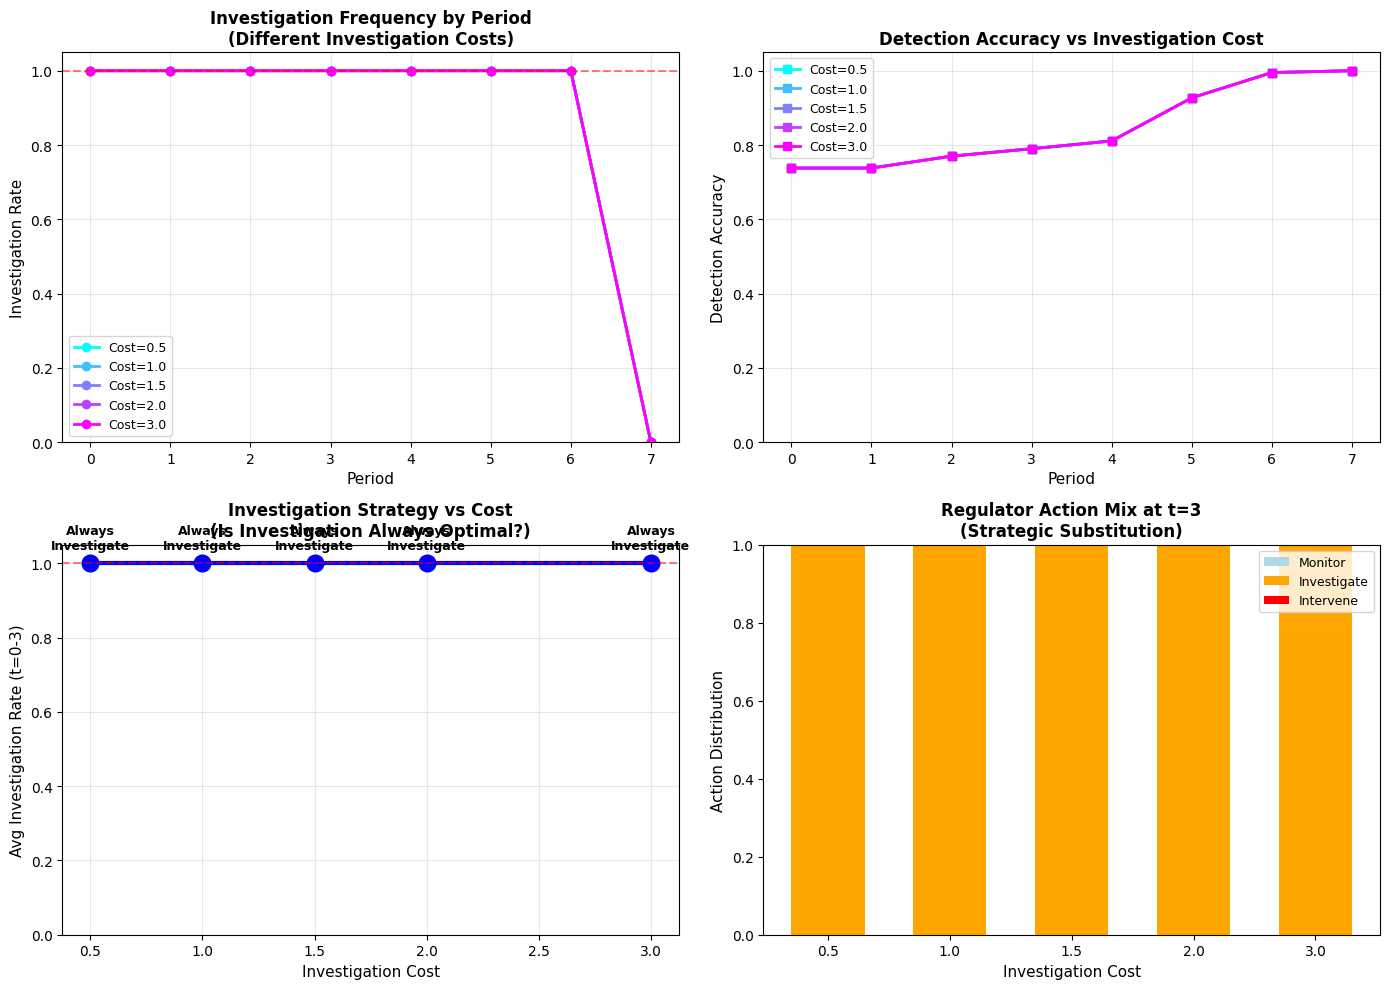


✓ Comparison plots saved as 'cost_robustness_comparison.png'

ROBUSTNESS CHECK SUMMARY: INVESTIGATION COSTS
 Investigation Cost  Early Inv Rate (t=0-3)  Mid-Game Accuracy (t=3)  Final Accuracy  Belief Sep (t=3)  Monitor Rate (t=3)  Intervene Rate (t=3)
              0.500                   1.000                    0.790           1.000             0.241               0.000                 0.000
              1.000                   1.000                    0.790           1.000             0.241               0.000                 0.000
              1.500                   1.000                    0.790           1.000             0.241               0.000                 0.000
              2.000                   1.000                    0.790           1.000             0.241               0.000                 0.000
              3.000                   1.000                    0.790           1.000             0.241               0.000                 0.000

Interpretation:
  Al

In [22]:
# ==========================================
# ROBUSTNESS CHECK 3: INVESTIGATION COSTS
# ==========================================

print("ROBUSTNESS CHECK: INVESTIGATION COSTS")
print("="*80)
print("\nEconomic Question: Does investigation cost affect regulatory strategy?")
print("Testing investigation costs: [0.5, 1.0, 1.5, 2.0, 3.0]\n")

# Test different investigation costs
costs_to_test = [0.5, 1.0, 1.5, 2.0, 3.0]
cost_results = {}

for cost in costs_to_test:
    print(f"\n{'='*60}")
    print(f"Running with Investigation Cost = {cost:.1f}")
    print(f"{'='*60}")

    # Run full analysis with this cost
    game, VF_P, VF_D, trajs, results = run_full_analysis(
        grid_resolution=7,
        n_trajectories=1000,
        seed=42,
        prior_rational=0.7,
        reputation_bonus=2.8,
        investigation_cost=cost
    )

    # Calculate investigation rate by period
    investigation_rates = []
    monitor_rates = []
    intervene_rates = []

    for t in range(len(results['detection_accuracy'])):
        period_actions = [traj['regulator_actions'][t] for traj in trajs
                         if t < len(traj['regulator_actions'])]
        if period_actions:
            investigation_rates.append(sum(1 for a in period_actions if a == 1) / len(period_actions))
            monitor_rates.append(sum(1 for a in period_actions if a == 0) / len(period_actions))
            intervene_rates.append(sum(1 for a in period_actions if a == 2) / len(period_actions))
        else:
            investigation_rates.append(0)
            monitor_rates.append(0)
            intervene_rates.append(0)

    # Calculate average investigation rate (periods 0-3)
    avg_investigation_early = np.mean(investigation_rates[:4])

    # Store results
    cost_results[cost] = {
        'game': game,
        'detection_accuracy': results['detection_accuracy'],
        'belief_tough_mean': results['belief_tough_mean'],
        'belief_rational_mean': results['belief_rational_mean'],
        'investigation_rates': investigation_rates,
        'monitor_rates': monitor_rates,
        'intervene_rates': intervene_rates,
        'avg_investigation_early': avg_investigation_early
    }

    print(f"\n✓ Completed cost={cost:.1f}")
    print(f"   Mid-game accuracy (t=3): {results['detection_accuracy'][3]:.1%}")
    print(f"   Early investigation rate: {avg_investigation_early:.1%}")

# Visualize investigation cost comparisons
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.cool(np.linspace(0, 1, len(costs_to_test)))

# Plot 1: Investigation Rate Over Time
ax = axes[0, 0]
for cost, color in zip(costs_to_test, colors):
    inv_rate = cost_results[cost]['investigation_rates']
    periods = range(len(inv_rate))
    ax.plot(periods, inv_rate, marker='o', label=f'Cost={cost:.1f}',
            color=color, linewidth=2)

ax.set_xlabel('Period', fontsize=11)
ax.set_ylabel('Investigation Rate', fontsize=11)
ax.set_title('Investigation Frequency by Period\n(Different Investigation Costs)',
             fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Always Investigate')

# Plot 2: Detection Accuracy
ax = axes[0, 1]
for cost, color in zip(costs_to_test, colors):
    acc = cost_results[cost]['detection_accuracy']
    periods = range(len(acc))
    ax.plot(periods, acc, marker='s', label=f'Cost={cost:.1f}',
            color=color, linewidth=2)

ax.set_xlabel('Period', fontsize=11)
ax.set_ylabel('Detection Accuracy', fontsize=11)
ax.set_title('Detection Accuracy vs Investigation Cost',
             fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

# Plot 3: Investigation Rate vs Cost (Early Game)
ax = axes[1, 0]
early_inv_rates = [cost_results[cost]['avg_investigation_early'] for cost in costs_to_test]

ax.plot(costs_to_test, early_inv_rates, marker='o', color='blue',
        linewidth=3, markersize=12)
ax.set_xlabel('Investigation Cost', fontsize=11)
ax.set_ylabel('Avg Investigation Rate (t=0-3)', fontsize=11)
ax.set_title('Investigation Strategy vs Cost\n(Is Investigation Always Optimal?)',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5)
ax.set_ylim([0, 1.05])

# Add annotations
for cost, rate in zip(costs_to_test, early_inv_rates):
    if rate > 0.95:
        label = "Always\nInvestigate"
    elif rate > 0.5:
        label = "Frequent"
    else:
        label = "Selective"
    ax.annotate(label, (cost, rate), textcoords="offset points",
                xytext=(0,10), ha='center', fontsize=9, fontweight='bold')

# Plot 4: Action Distribution (Stacked Bar)
ax = axes[1, 1]

# Get period 3 action distribution for each cost
action_data = []
for cost in costs_to_test:
    monitor = cost_results[cost]['monitor_rates'][3]
    investigate = cost_results[cost]['investigation_rates'][3]
    intervene = cost_results[cost]['intervene_rates'][3]
    action_data.append([monitor, investigate, intervene])

action_data = np.array(action_data).T
x = np.arange(len(costs_to_test))
width = 0.6

bars1 = ax.bar(x, action_data[0], width, label='Monitor', color='lightblue')
bars2 = ax.bar(x, action_data[1], width, bottom=action_data[0],
               label='Investigate', color='orange')
bars3 = ax.bar(x, action_data[2], width,
               bottom=action_data[0]+action_data[1],
               label='Intervene', color='red')

ax.set_xlabel('Investigation Cost', fontsize=11)
ax.set_ylabel('Action Distribution', fontsize=11)
ax.set_title('Regulator Action Mix at t=3\n(Strategic Substitution)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{c:.1f}' for c in costs_to_test])
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.savefig('cost_robustness_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Comparison plots saved as 'cost_robustness_comparison.png'")

# Summary table
summary_data = []
for cost in costs_to_test:
    results = cost_results[cost]

    row = {
        'Investigation Cost': cost,
        'Early Inv Rate (t=0-3)': results['avg_investigation_early'],
        'Mid-Game Accuracy (t=3)': results['detection_accuracy'][3],
        'Final Accuracy': results['detection_accuracy'][-1],
        'Belief Sep (t=3)': (results['belief_rational_mean'][3] -
                            results['belief_tough_mean'][3]),
        'Monitor Rate (t=3)': results['monitor_rates'][3],
        'Intervene Rate (t=3)': results['intervene_rates'][3]
    }
    summary_data.append(row)

df_cost = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("ROBUSTNESS CHECK SUMMARY: INVESTIGATION COSTS")
print("="*80)
print(df_cost.to_string(index=False, float_format='%.3f'))
print("="*80)

# Interpretation
print("\nInterpretation:")
always_investigate = df_cost[df_cost['Early Inv Rate (t=0-3)'] > 0.95]
selective_investigate = df_cost[df_cost['Early Inv Rate (t=0-3)'] <= 0.95]

if len(always_investigate) > 0:
    print(f"  Always Investigate: Cost ≤ {always_investigate['Investigation Cost'].max():.1f}")
    print(f"    Detection at t=3: {always_investigate['Mid-Game Accuracy (t=3)'].mean():.1%}")
    print(f"    Average cost: {always_investigate['Investigation Cost'].mean():.1f}")
if len(selective_investigate) > 0:
    print(f"  Selective Investigation: Cost > {selective_investigate['Investigation Cost'].min():.1f}")
    print(f"    Detection at t=3: {selective_investigate['Mid-Game Accuracy (t=3)'].mean():.1%}")
    print(f"    Average investigation rate: {selective_investigate['Early Inv Rate (t=0-3)'].mean():.1%}")

# Policy implication
print("\nPolicy Implication:")
if len(always_investigate) > 0 and len(selective_investigate) > 0:
    print(f"  Investigation cost/benefit ratio determines optimal strategy:")
    print(f"    • Low cost (≤{always_investigate['Investigation Cost'].max():.1f}): Investigate always")
    print(f"    • High cost (>{selective_investigate['Investigation Cost'].min():.1f}): Strategic monitoring + selective investigation")
else:
    print(f"  Investigation remains optimal across tested cost range [0.5, 3.0]")
    print(f"  Information value dominates direct costs within this range")

df_cost.to_csv('cost_robustness_summary.csv', index=False)
print("\n✓ Summary saved as 'cost_robustness_summary.csv'")


ROBUSTNESS CHECK: HORIZON LENGTH T

Economic Question: Does game length affect end-game unraveling and detection?
Testing horizons: [4, 6, 8, 10, 12, 15] (Baseline: 8)


Running with Horizon T = 4
Enhanced N-CIRL Model with Imperfect Pooling

Grid resolution: 7 (higher = smaller gap, slower)
Based on Celetani et al. (1996)
Building Enhanced Competition Game...
  Public States: 8 = 2 demand × 4 periods
  Tremble (Tough): 2.0%, Tremble (Rational): 6.0%
  Investigation accuracy: 65.0%
  Reputation bonus: 2.8, Fighting cost: 0.3
Model built successfully.

Running NC-PBVI...
  States: 8, Expansions: 4
  Expansion 1/4... Gap at corner: 0.00
  Expansion 2/4... Gap at corner: 0.00
  Expansion 3/4... Gap at corner: 0.00
  Expansion 4/4... Gap at corner: 0.00
  Done.

Equilibrium Evaluation

--- Strong reputation (μ=0.8) ---

State 0:
  Demand=Low, Period=0/3, TimeLeft=3
  Values: Primal=4.13, Dual=7.17, Gap=3.05
  Incumbent Fighting Probability:
    Tough:    100%
    Rational: 100% ← POOLING 

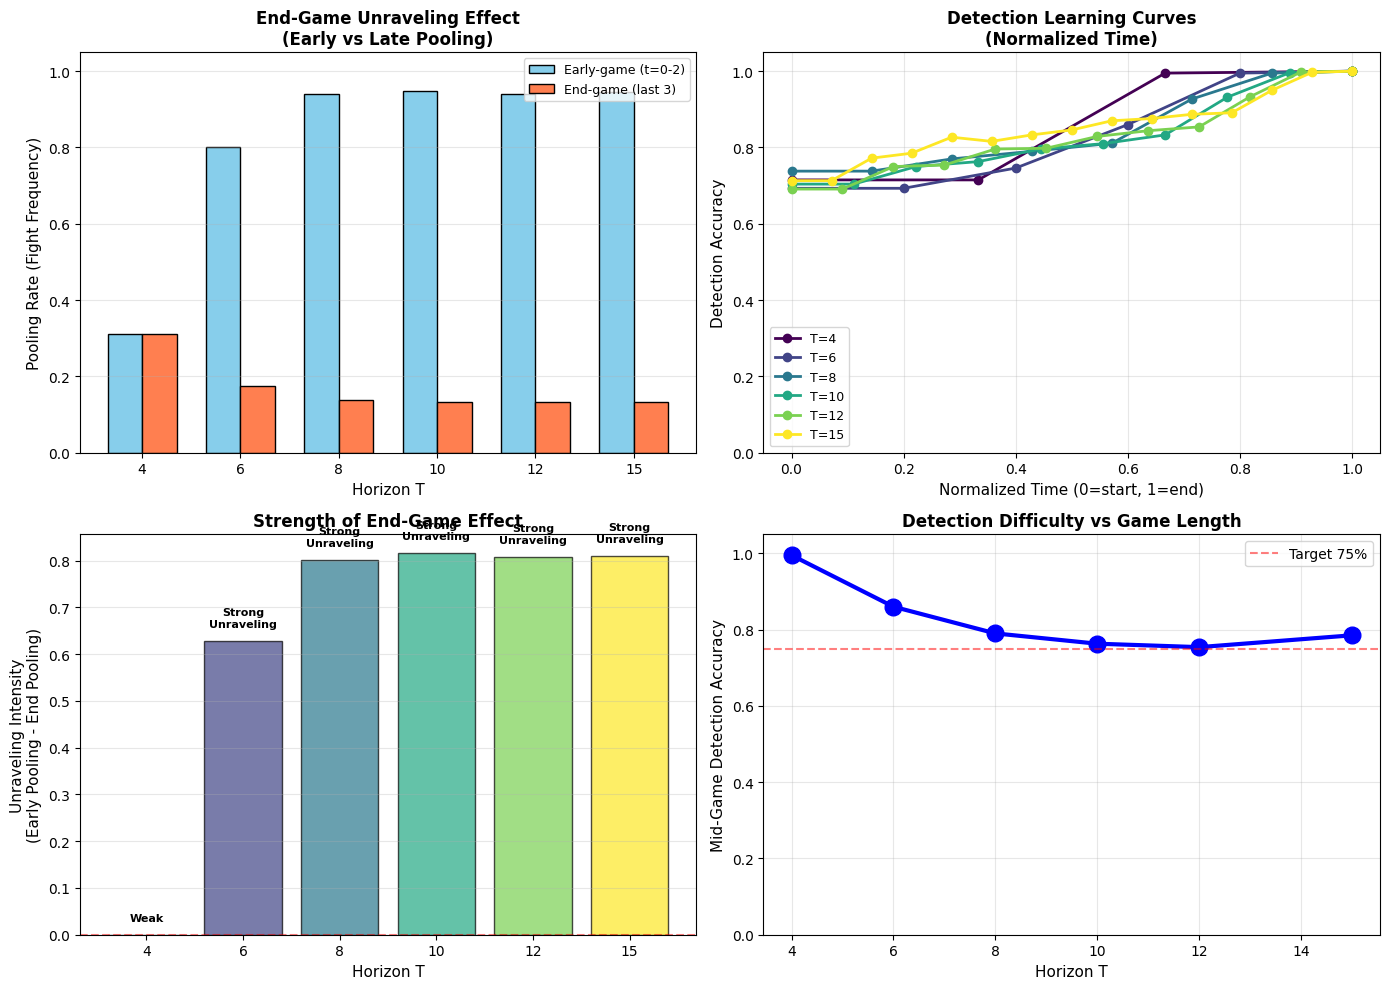


✓ Comparison plots saved as 'horizon_robustness_comparison.png'

ROBUSTNESS CHECK SUMMARY: HORIZON LENGTH T
 Horizon T  Early Pooling (t=0-2)  End Pooling (last 3)  Unraveling Intensity  Mid-Game Accuracy  Final Accuracy
         4                  0.311                 0.311                 0.000              0.995           1.000
         6                  0.802                 0.174                 0.628              0.860           1.000
         8                  0.940                 0.139                 0.802              0.790           1.000
        10                  0.949                 0.134                 0.816              0.763           1.000
        12                  0.940                 0.132                 0.808              0.754           1.000
        15                  0.944                 0.134                 0.811              0.785           1.000

Interpretation:
  Strong Unraveling: T ≥ 6
    Early pooling: 91.5%
    End pooling: 14.2%
  Weak U

In [23]:
# ==========================================
# ROBUSTNESS CHECK 4: HORIZON LENGTH T
# ==========================================

print("\n" + "="*80)
print("ROBUSTNESS CHECK: HORIZON LENGTH T")
print("="*80)
print("\nEconomic Question: Does game length affect end-game unraveling and detection?")
print("Testing horizons: [4, 6, 8, 10, 12, 15] (Baseline: 8)\n")

# Test different time horizons
horizons_to_test = [4, 6, 8, 10, 12, 15]
horizon_results = {}

for T in horizons_to_test:
    print(f"\n{'='*60}")
    print(f"Running with Horizon T = {T}")
    print(f"{'='*60}")

    # Run full analysis with this horizon
    game, VF_P, VF_D, trajs, results = run_full_analysis(
        grid_resolution=7,
        n_trajectories=1000,
        seed=42,
        prior_rational=0.7,
        reputation_bonus=2.8,
        investigation_cost=1.5,
        T_max=T
    )

    # Calculate pooling rate in LAST 3 periods (end-game)
    rational_trajs = [t for t in trajs if t['true_type'] == 1]
    if rational_trajs:
        endgame_fights = 0
        endgame_total = 0
        for traj in rational_trajs:
            # Last 3 periods before terminal
            start_period = max(0, T - 4)  # T-4, T-3, T-2
            end_period = min(T - 1, len(traj['incumbent_actions']))
            for t in range(start_period, end_period):
                if t < len(traj['incumbent_actions']):
                    if traj['incumbent_actions'][t] == 0:  # Fight
                        endgame_fights += 1
                    endgame_total += 1
        endgame_pooling_rate = endgame_fights / endgame_total if endgame_total > 0 else 0
    else:
        endgame_pooling_rate = 0

    # Calculate early-game pooling rate (first 3 periods)
    if rational_trajs:
        earlygame_fights = 0
        earlygame_total = 0
        for traj in rational_trajs:
            for t in range(min(3, len(traj['incumbent_actions']))):
                if traj['incumbent_actions'][t] == 0:  # Fight
                    earlygame_fights += 1
                earlygame_total += 1
        earlygame_pooling_rate = earlygame_fights / earlygame_total if earlygame_total > 0 else 0
    else:
        earlygame_pooling_rate = 0

    # Get mid-game accuracy (at period min(3, T-2))
    midgame_period = min(3, T - 2)
    if midgame_period < len(results['detection_accuracy']):
        midgame_accuracy = results['detection_accuracy'][midgame_period]
    else:
        midgame_accuracy = results['detection_accuracy'][-1]

    # Store results
    horizon_results[T] = {
        'game': game,
        'detection_accuracy': results['detection_accuracy'],
        'belief_tough_mean': results['belief_tough_mean'],
        'belief_rational_mean': results['belief_rational_mean'],
        'earlygame_pooling': earlygame_pooling_rate,
        'endgame_pooling': endgame_pooling_rate,
        'midgame_accuracy': midgame_accuracy,
        'final_accuracy': results['detection_accuracy'][-1]
    }

    print(f"\n✓ Completed T={T}")
    print(f"   Early-game pooling (t=0-2): {earlygame_pooling_rate:.1%}")
    print(f"   End-game pooling (last 3): {endgame_pooling_rate:.1%}")
    print(f"   Mid-game accuracy: {midgame_accuracy:.1%}")

# Visualize horizon comparisons
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(horizons_to_test)))

# Plot 1: Pooling Rates (Early vs End-game)
ax = axes[0, 0]
x = np.arange(len(horizons_to_test))
width = 0.35

early_pooling = [horizon_results[T]['earlygame_pooling'] for T in horizons_to_test]
end_pooling = [horizon_results[T]['endgame_pooling'] for T in horizons_to_test]

bars1 = ax.bar(x - width/2, early_pooling, width, label='Early-game (t=0-2)',
               color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, end_pooling, width, label='End-game (last 3)',
               color='coral', edgecolor='black')

ax.set_xlabel('Horizon T', fontsize=11)
ax.set_ylabel('Pooling Rate (Fight Frequency)', fontsize=11)
ax.set_title('End-Game Unraveling Effect\n(Early vs Late Pooling)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(T) for T in horizons_to_test])
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Detection Accuracy Trajectories (normalized time)
ax = axes[0, 1]
for T, color in zip(horizons_to_test, colors):
    acc = horizon_results[T]['detection_accuracy']
    # Normalize time to [0, 1]
    normalized_time = np.linspace(0, 1, len(acc))
    ax.plot(normalized_time, acc, marker='o', label=f'T={T}',
            color=color, linewidth=2)

ax.set_xlabel('Normalized Time (0=start, 1=end)', fontsize=11)
ax.set_ylabel('Detection Accuracy', fontsize=11)
ax.set_title('Detection Learning Curves\n(Normalized Time)',
             fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

# Plot 3: Unraveling Intensity (Early - End pooling difference)
ax = axes[1, 0]
unraveling = [early_pooling[i] - end_pooling[i] for i in range(len(horizons_to_test))]

bars = ax.bar(range(len(horizons_to_test)), unraveling,
              color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Horizon T', fontsize=11)
ax.set_ylabel('Unraveling Intensity\n(Early Pooling - End Pooling)', fontsize=11)
ax.set_title('Strength of End-Game Effect',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(len(horizons_to_test)))
ax.set_xticklabels([str(T) for T in horizons_to_test])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

# Add annotations
for i, (T, unrav) in enumerate(zip(horizons_to_test, unraveling)):
    if unrav > 0.3:
        label = "Strong\nUnraveling"
    elif unrav > 0.1:
        label = "Moderate"
    else:
        label = "Weak"
    ax.text(i, unrav + 0.03, label, ha='center', fontsize=8, fontweight='bold')

# Plot 4: Mid-game Accuracy vs Horizon
ax = axes[1, 1]
midgame_accs = [horizon_results[T]['midgame_accuracy'] for T in horizons_to_test]

ax.plot(horizons_to_test, midgame_accs, marker='o', color='blue',
        linewidth=3, markersize=12)
ax.set_xlabel('Horizon T', fontsize=11)
ax.set_ylabel('Mid-Game Detection Accuracy', fontsize=11)
ax.set_title('Detection Difficulty vs Game Length',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
ax.axhline(y=0.75, color='red', linestyle='--', alpha=0.5, label='Target 75%')
ax.legend()

plt.tight_layout()
plt.savefig('horizon_robustness_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Comparison plots saved as 'horizon_robustness_comparison.png'")

# Summary table
summary_data = []
for T in horizons_to_test:
    results = horizon_results[T]

    row = {
        'Horizon T': T,
        'Early Pooling (t=0-2)': results['earlygame_pooling'],
        'End Pooling (last 3)': results['endgame_pooling'],
        'Unraveling Intensity': results['earlygame_pooling'] - results['endgame_pooling'],
        'Mid-Game Accuracy': results['midgame_accuracy'],
        'Final Accuracy': results['final_accuracy']
    }
    summary_data.append(row)

df_horizon = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("ROBUSTNESS CHECK SUMMARY: HORIZON LENGTH T")
print("="*80)
print(df_horizon.to_string(index=False, float_format='%.3f'))
print("="*80)

# Interpretation
print("\nInterpretation:")
strong_unravel = df_horizon[df_horizon['Unraveling Intensity'] > 0.3]
weak_unravel = df_horizon[df_horizon['Unraveling Intensity'] <= 0.3]

if len(strong_unravel) > 0:
    print(f"  Strong Unraveling: T ≥ {strong_unravel['Horizon T'].min()}")
    print(f"    Early pooling: {strong_unravel['Early Pooling (t=0-2)'].mean():.1%}")
    print(f"    End pooling: {strong_unravel['End Pooling (last 3)'].mean():.1%}")
if len(weak_unravel) > 0:
    print(f"  Weak Unraveling: T ≤ {weak_unravel['Horizon T'].max()}")
    print(f"    Pooling remains high throughout")

# Economic insight
print("\nEconomic Insight:")
print(f"  • Longer horizons increase reputation-building incentive (early pooling)")
print(f"  • But also strengthen backward induction (end-game unraveling)")
print(f"  • Detection difficulty inversely related to horizon length")

Robustness Check 5: Discount Factor γ (Patience)

Economic Question: How does patience affect pooling and detection?
Testing discount factors: [0.85, 0.90, 0.95, 0.97, 0.99] (Baseline: 0.95)

Running with Discount Factor γ = 0.85
Enhanced N-CIRL Model with Imperfect Pooling

Grid resolution: 7 (higher = smaller gap, slower)
Based on Celetani et al. (1996)
Building Enhanced Competition Game...
  Public States: 16 = 2 demand × 8 periods
  Tremble (Tough): 2.0%, Tremble (Rational): 6.0%
  Investigation accuracy: 65.0%
  Reputation bonus: 2.8, Fighting cost: 0.3
Model built successfully.

Running NC-PBVI...
  States: 16, Expansions: 4
  Expansion 1/4... Gap at corner: 0.00
  Expansion 2/4... Gap at corner: 0.00
  Expansion 3/4... Gap at corner: 0.00
  Expansion 4/4... Gap at corner: 0.00
  Done.

Equilibrium Evaluation

--- Strong reputation (μ=0.8) ---

State 0:
  Demand=Low, Period=0/7, TimeLeft=7
  Values: Primal=6.28, Dual=7.17, Gap=0.89
  Incumbent Fighting Probability:
    Tough:    

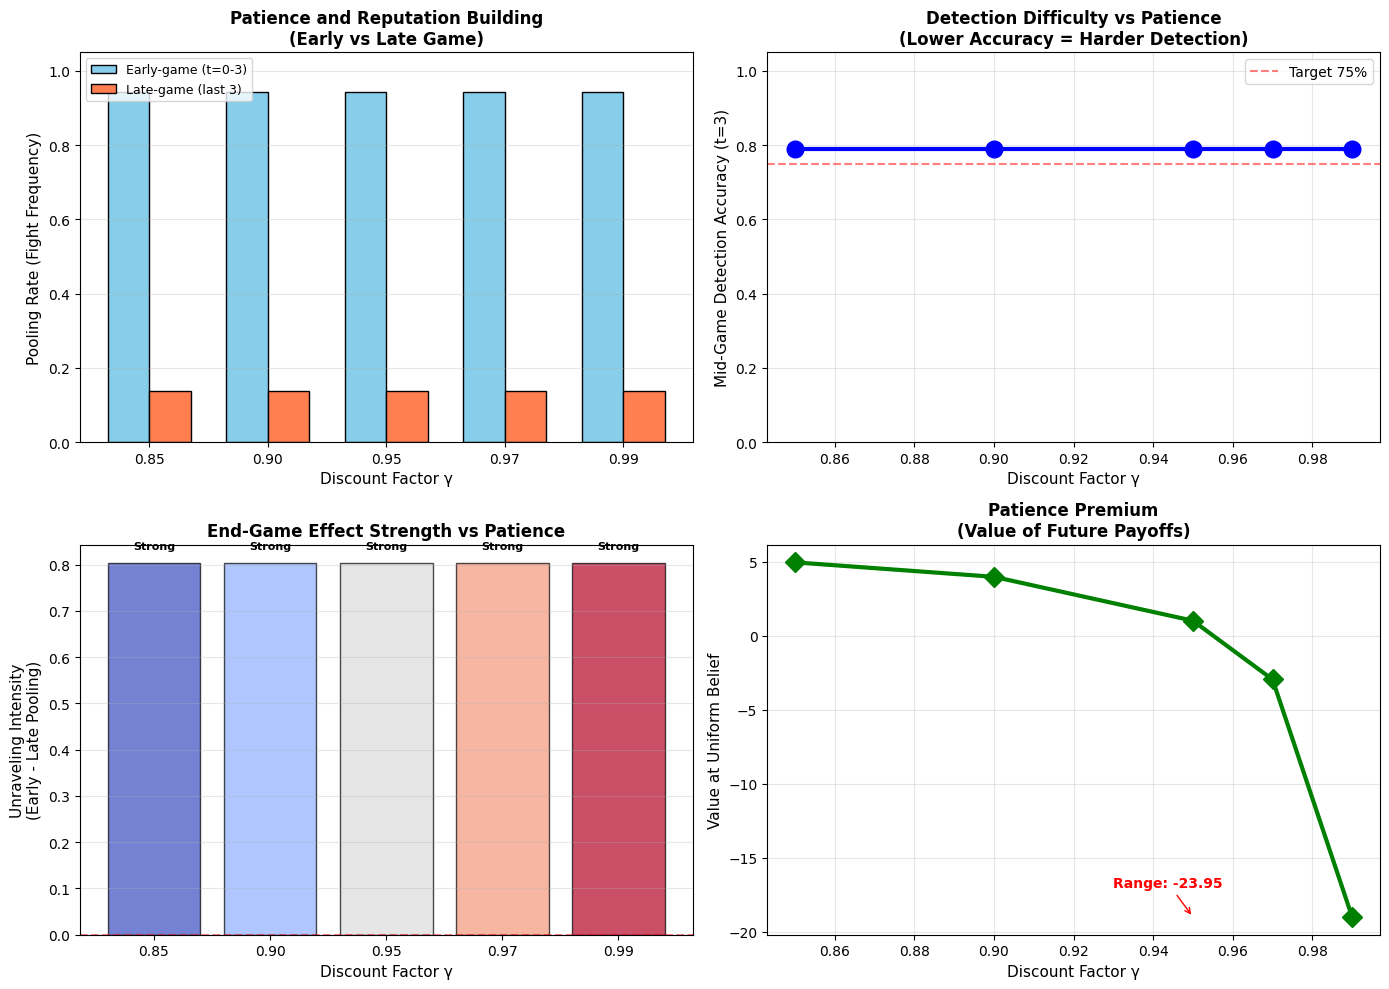


✓ Comparison plots saved as 'gamma_robustness_comparison.png'
Robustness Check Symmary: Discount Factor γ
 Discount Factor γ  Early Pooling (t=0-3)  Late Pooling (last 3)  Unraveling Intensity  Mid-Game Accuracy (t=3)  Final Accuracy  Value (Uniform Belief)
             0.850                  0.942                  0.139                 0.803                    0.790           1.000                   4.947
             0.900                  0.942                  0.139                 0.803                    0.790           1.000                   3.971
             0.950                  0.942                  0.139                 0.803                    0.790           1.000                   1.006
             0.970                  0.942                  0.139                 0.803                    0.790           1.000                  -2.962
             0.990                  0.942                  0.139                 0.803                    0.790           1.000      

In [24]:
# Robustness Check 5: Discount Factor γ

print("Robustness Check 5: Discount Factor γ (Patience)")
print("\nEconomic Question: How does patience affect pooling and detection?")
print("Testing discount factors: [0.85, 0.90, 0.95, 0.97, 0.99] (Baseline: 0.95)\n")

# Test different discount factors
gammas_to_test = [0.85, 0.90, 0.95, 0.97, 0.99]
gamma_results = {}

for gamma in gammas_to_test:
    print(f"Running with Discount Factor γ = {gamma:.2f}")

    # Run full analysis with this gamma
    game, VF_P, VF_D, trajs, results = run_full_analysis(
        grid_resolution=7,
        n_trajectories=1000,
        seed=42,
        prior_rational=0.7,
        reputation_bonus=2.8,
        investigation_cost=1.5,
        T_max=8,
        gamma=gamma
    )

    # Calculate pooling metrics
    rational_trajs = [t for t in trajs if t['true_type'] == 1]
    if rational_trajs:
        # Early-game pooling (t=0-3)
        early_fights = 0
        early_total = 0
        for traj in rational_trajs:
            for t in range(min(4, len(traj['incumbent_actions']))):
                if traj['incumbent_actions'][t] == 0:  # Fight
                    early_fights += 1
                early_total += 1
        earlygame_pooling = early_fights / early_total if early_total > 0 else 0

        # Late-game pooling (last 3 periods)
        late_fights = 0
        late_total = 0
        for traj in rational_trajs:
            start_period = max(0, len(traj['incumbent_actions']) - 3)
            for t in range(start_period, len(traj['incumbent_actions'])):
                if traj['incumbent_actions'][t] == 0:  # Fight
                    late_fights += 1
                late_total += 1
        lategame_pooling = late_fights / late_total if late_total > 0 else 0
    else:
        earlygame_pooling = 0
        lategame_pooling = 0

    # Get mid-game accuracy (t=3)
    midgame_accuracy = results['detection_accuracy'][3] if len(results['detection_accuracy']) > 3 else results['detection_accuracy'][-1]

    # Compute value at uniform belief (measure of patience premium)
    uniform_belief = np.array([0.5, 0.5])
    v_baseline, _ = solve_primal_lp(game, 0, uniform_belief, VF_P)

    # Store results
    gamma_results[gamma] = {
        'game': game,
        'detection_accuracy': results['detection_accuracy'],
        'belief_tough_mean': results['belief_tough_mean'],
        'belief_rational_mean': results['belief_rational_mean'],
        'earlygame_pooling': earlygame_pooling,
        'lategame_pooling': lategame_pooling,
        'unraveling_intensity': earlygame_pooling - lategame_pooling,
        'midgame_accuracy': midgame_accuracy,
        'final_accuracy': results['detection_accuracy'][-1],
        'value_at_uniform': v_baseline if v_baseline is not None else 0
    }

    print(f"\n✓ Completed γ={gamma:.2f}")
    print(f"   Early pooling (t=0-3): {earlygame_pooling:.1%}")
    print(f"   Late pooling (last 3): {lategame_pooling:.1%}")
    print(f"   Unraveling intensity: {earlygame_pooling - lategame_pooling:+.1%}")
    print(f"   Mid-game accuracy: {midgame_accuracy:.1%}")

    # Visualize discount factor comparisons
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.coolwarm(np.linspace(0, 1, len(gammas_to_test)))

# Plot 1: Pooling Rates vs Gamma
ax = axes[0, 0]
x = np.arange(len(gammas_to_test))
width = 0.35

early_pooling = [gamma_results[g]['earlygame_pooling'] for g in gammas_to_test]
late_pooling = [gamma_results[g]['lategame_pooling'] for g in gammas_to_test]

bars1 = ax.bar(x - width/2, early_pooling, width, label='Early-game (t=0-3)',
               color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, late_pooling, width, label='Late-game (last 3)',
               color='coral', edgecolor='black')

ax.set_xlabel('Discount Factor γ', fontsize=11)
ax.set_ylabel('Pooling Rate (Fight Frequency)', fontsize=11)
ax.set_title('Patience and Reputation Building\n(Early vs Late Game)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{g:.2f}' for g in gammas_to_test])
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Detection Difficulty vs Gamma
ax = axes[0, 1]
midgame_accs = [gamma_results[g]['midgame_accuracy'] for g in gammas_to_test]

ax.plot(gammas_to_test, midgame_accs, marker='o', color='blue',
        linewidth=3, markersize=12)
ax.set_xlabel('Discount Factor γ', fontsize=11)
ax.set_ylabel('Mid-Game Detection Accuracy (t=3)', fontsize=11)
ax.set_title('Detection Difficulty vs Patience\n(Lower Accuracy = Harder Detection)',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0.75, color='red', linestyle='--', alpha=0.5, label='Target 75%')
ax.legend()
ax.set_ylim([0, 1.05])

# Plot 3: Unraveling Intensity vs Gamma
ax = axes[1, 0]
unraveling_intensity = [gamma_results[g]['unraveling_intensity'] for g in gammas_to_test]

bars = ax.bar(range(len(gammas_to_test)), unraveling_intensity,
              color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Discount Factor γ', fontsize=11)
ax.set_ylabel('Unraveling Intensity\n(Early - Late Pooling)', fontsize=11)
ax.set_title('End-Game Effect Strength vs Patience',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(len(gammas_to_test)))
ax.set_xticklabels([f'{g:.2f}' for g in gammas_to_test])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

# Annotate bars
for i, (gamma, unrav) in enumerate(zip(gammas_to_test, unraveling_intensity)):
    if unrav > 0.5:
        label = "Strong"
    elif unrav > 0.3:
        label = "Moderate"
    else:
        label = "Weak"
    ax.text(i, unrav + 0.03, label, ha='center', fontsize=8, fontweight='bold')

# Plot 4: Value Function vs Gamma (Patience Premium)
ax = axes[1, 1]
values = [gamma_results[g]['value_at_uniform'] for g in gammas_to_test]

ax.plot(gammas_to_test, values, marker='D', color='green',
        linewidth=3, markersize=10)
ax.set_xlabel('Discount Factor γ', fontsize=11)
ax.set_ylabel('Value at Uniform Belief', fontsize=11)
ax.set_title('Patience Premium\n(Value of Future Payoffs)',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add annotation
patience_range = values[-1] - values[0]
ax.annotate(f'Range: {patience_range:+.2f}',
           xy=(0.95, values[-1]), xytext=(0.93, values[-1] + 2),
           arrowprops=dict(arrowstyle='->', color='red'),
           fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('gamma_robustness_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Comparison plots saved as 'gamma_robustness_comparison.png'")

# Summary table
summary_data = []
for gamma in gammas_to_test:
    results = gamma_results[gamma]

    row = {
        'Discount Factor γ': gamma,
        'Early Pooling (t=0-3)': results['earlygame_pooling'],
        'Late Pooling (last 3)': results['lategame_pooling'],
        'Unraveling Intensity': results['unraveling_intensity'],
        'Mid-Game Accuracy (t=3)': results['midgame_accuracy'],
        'Final Accuracy': results['final_accuracy'],
        'Value (Uniform Belief)': results['value_at_uniform']
    }
    summary_data.append(row)

df_gamma = pd.DataFrame(summary_data)

print("Robustness Check Symmary: Discount Factor γ")
print(df_gamma.to_string(index=False, float_format='%.3f'))

# Economic interpretation
print("\nEconomic Interpretation:")

# Find patience effects
impatient = df_gamma[df_gamma['Discount Factor γ'] < 0.90]
patient = df_gamma[df_gamma['Discount Factor γ'] > 0.96]

if len(impatient) > 0:
    print(f"\n  Impatient (γ < 0.90):")
    print(f"    Early pooling:    {impatient['Early Pooling (t=0-3)'].mean():.1%}")
    print(f"    Detection at t=3: {impatient['Mid-Game Accuracy (t=3)'].mean():.1%}")
    print(f"    → Short-term focus reduces reputation building")

baseline = df_gamma[df_gamma['Discount Factor γ'] == 0.95]
if len(baseline) > 0:
    print(f"\n  Baseline (γ = 0.95):")
    print(f"    Early pooling:    {baseline['Early Pooling (t=0-3)'].iloc[0]:.1%}")
    print(f"    Detection at t=3: {baseline['Mid-Game Accuracy (t=3)'].iloc[0]:.1%}")

if len(patient) > 0:
    print(f"\n  Patient (γ > 0.96):")
    print(f"    Early pooling:    {patient['Early Pooling (t=0-3)'].mean():.1%}")
    print(f"    Detection at t=3: {patient['Mid-Game Accuracy (t=3)'].mean():.1%}")
    print(f"    → Long-term focus strengthens reputation incentives")

# Monotonicity check
pooling_increases = all(df_gamma['Early Pooling (t=0-3)'].iloc[i] <=
                       df_gamma['Early Pooling (t=0-3)'].iloc[i+1] + 0.05
                       for i in range(len(df_gamma)-1))

if pooling_increases:
    print(f"\n  Monotonicity: Pooling increases with patience (as expected)")
else:
    print(f"\n  Non-monotonic pooling pattern (investigate parameter interactions)")

# Detection difficulty
detection_decreases = all(df_gamma['Mid-Game Accuracy (t=3)'].iloc[i] >=
                         df_gamma['Mid-Game Accuracy (t=3)'].iloc[i+1] - 0.05
                         for i in range(len(df_gamma)-1))

if detection_decreases:
    print(f"  Detection: Accuracy decreases with patience (harder to detect pooling)")
else:
    print(f"  Detection pattern does not follow pooling (investigate)")

# Policy implication
print("\n  Policy Implication:")
print(f"    • Low interest rates (high γ) → More strategic pooling")
print(f"    • Regulators need more resources when firms are patient")
print(f"    • Detection difficulty scales with discount factor")

df_gamma.to_csv('gamma_robustness_summary.csv', index=False)
print("\n Summary saved as 'gamma_robustness_summary.csv'")

Robustness Check 6: Demand Persistence ρ (Market Volatility)

Economic Question: Does market volatility affect detection difficulty?
Testing persistence parameters: [0.2, 0.4, 0.6, 0.8, 0.95] (Baseline: 0.6)
  ρ → 0: High volatility (frequent demand changes)
  ρ → 1: Low volatility (persistent demand)

Running with Demand Persistence ρ = 0.20
  → high Volatility (demand changes frequently)
Enhanced N-CIRL Model with Imperfect Pooling

Grid resolution: 7 (higher = smaller gap, slower)
Based on Celetani et al. (1996)
Building Enhanced Competition Game...
  Public States: 16 = 2 demand × 8 periods
  Tremble (Tough): 2.0%, Tremble (Rational): 6.0%
  Investigation accuracy: 65.0%
  Reputation bonus: 2.8, Fighting cost: 0.3
Model built successfully.

Running NC-PBVI...
  States: 16, Expansions: 4
  Expansion 1/4... Gap at corner: 0.00
  Expansion 2/4... Gap at corner: 0.00
  Expansion 3/4... Gap at corner: 0.00
  Expansion 4/4... Gap at corner: 0.00
  Done.

Equilibrium Evaluation

--- Stron

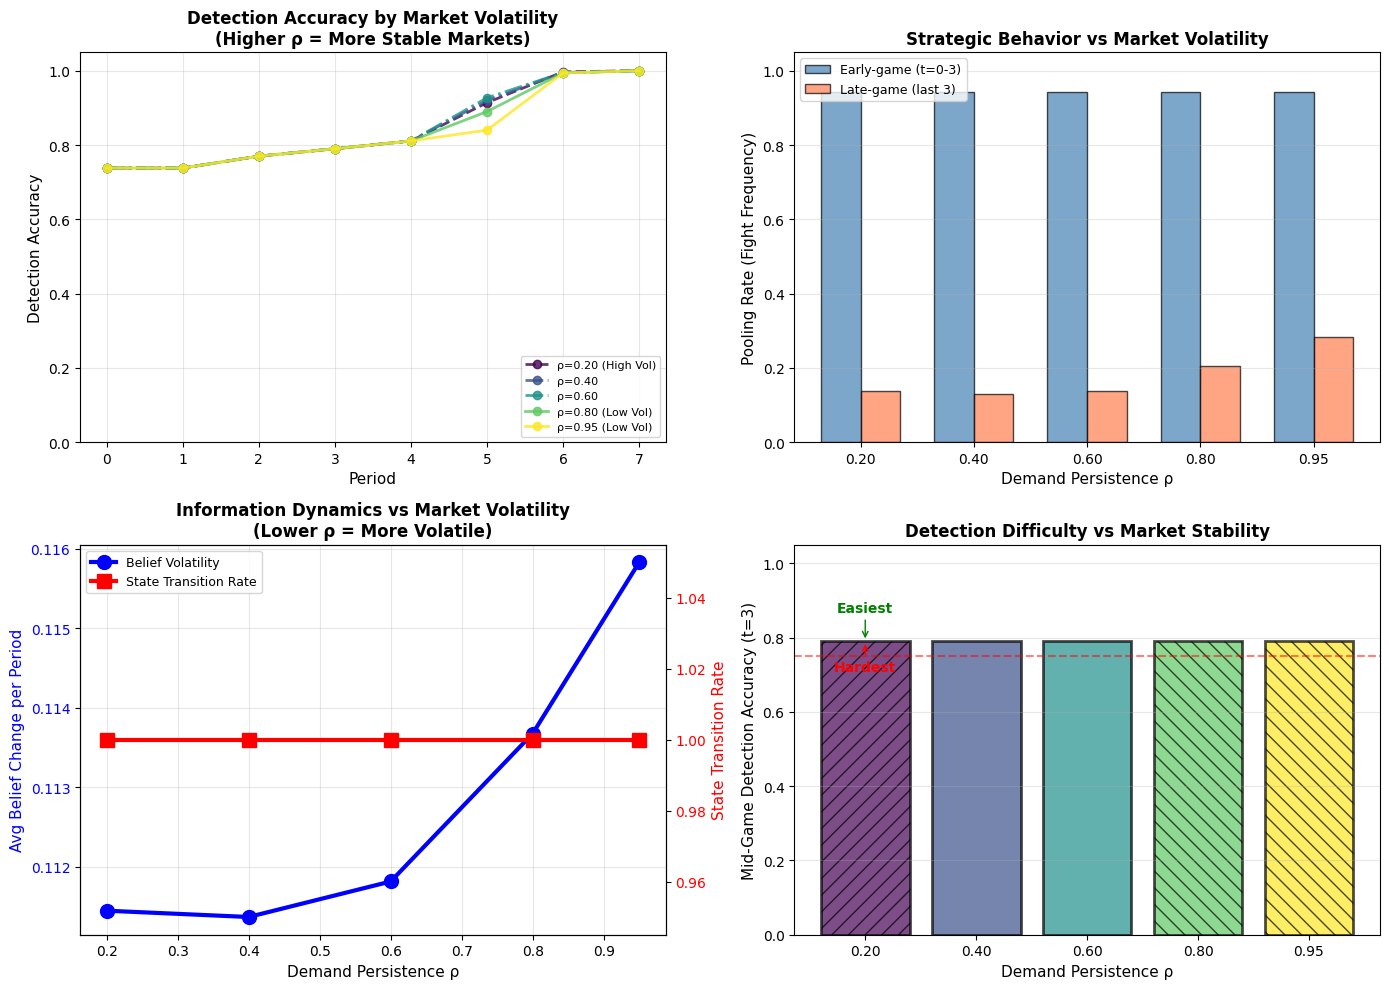


 Comparison plots saved as 'rho_robustness_comparison.png'
Robustness Check Summary: Demand Persistence ρ
 Demand Persistence ρ Market Volatility  Early Pooling (t=0-3)  Late Pooling (last 3)  Unraveling Intensity  Mid-Game Accuracy (t=3)  Final Accuracy  Belief Volatility  State Transition Rate
                0.200              High                  0.942                  0.138                 0.804                    0.790           1.000              0.111                  1.000
                0.400            Medium                  0.942                  0.129                 0.813                    0.790           1.000              0.111                  1.000
                0.600            Medium                  0.942                  0.139                 0.803                    0.790           1.000              0.112                  1.000
                0.800               Low                  0.942                  0.204                 0.738                    0.

In [25]:
# Robustness Check 6: Demand Persistence ρ

print("Robustness Check 6: Demand Persistence ρ (Market Volatility)")
print("\nEconomic Question: Does market volatility affect detection difficulty?")
print("Testing persistence parameters: [0.2, 0.4, 0.6, 0.8, 0.95] (Baseline: 0.6)")
print("  ρ → 0: High volatility (frequent demand changes)")
print("  ρ → 1: Low volatility (persistent demand)\n")

# Test different demand persistence levels
rho_values = [0.2, 0.4, 0.6, 0.8, 0.95]
rho_results = {}

for rho in rho_values:
    print(f"Running with Demand Persistence ρ = {rho:.2f}")
    if rho <= 0.3:
        print(f"  → high Volatility (demand changes frequently)")
    elif rho >= 0.8:
        print(f"  → Low Volatility (demand persistent)")
    else:
        print(f"  → Moderate Volatility")

    # Run full analysis with this persistence level
    game, VF_P, VF_D, trajs, results = run_full_analysis(
        grid_resolution=7,
        n_trajectories=1000,
        seed=42,
        prior_rational=0.7,
        reputation_bonus=2.8,
        investigation_cost=1.5,
        T_max=8,
        gamma=0.95,
        rho_demand=rho
    )

    # Calculate pooling metrics
    rational_trajs = [t for t in trajs if t['true_type'] == 1]
    if rational_trajs:
        # Early-game pooling (t=0-3)
        early_fights = 0
        early_total = 0
        for traj in rational_trajs:
            for t in range(min(4, len(traj['incumbent_actions']))):
                if traj['incumbent_actions'][t] == 0:  # Fight
                    early_fights += 1
                early_total += 1
        earlygame_pooling = early_fights / early_total if early_total > 0 else 0

        # Late-game pooling (last 3 periods)
        late_fights = 0
        late_total = 0
        for traj in rational_trajs:
            start_period = max(0, len(traj['incumbent_actions']) - 3)
            for t in range(start_period, len(traj['incumbent_actions'])):
                if traj['incumbent_actions'][t] == 0:  # Fight
                    late_fights += 1
                late_total += 1
        lategame_pooling = late_fights / late_total if late_total > 0 else 0
    else:
        earlygame_pooling = 0
        lategame_pooling = 0

    # Get mid-game accuracy (t=3)
    midgame_accuracy = results['detection_accuracy'][3] if len(results['detection_accuracy']) > 3 else results['detection_accuracy'][-1]

    # Calculate belief volatility (how much beliefs change)
    belief_changes = []
    for traj in trajs:
        for i in range(len(traj['beliefs']) - 1):
            change = abs(traj['beliefs'][i+1][1] - traj['beliefs'][i][1])
            belief_changes.append(change)
    avg_belief_volatility = np.mean(belief_changes) if belief_changes else 0

    # Calculate state transition entropy (measure of unpredictability)
    state_changes = []
    for traj in trajs:
        for i in range(len(traj['states']) - 1):
            if traj['states'][i] != traj['states'][i+1]:
                state_changes.append(1)
            else:
                state_changes.append(0)
    state_transition_rate = np.mean(state_changes) if state_changes else 0

    # Store results
    rho_results[rho] = {
        'game': game,
        'detection_accuracy': results['detection_accuracy'],
        'belief_tough_mean': results['belief_tough_mean'],
        'belief_rational_mean': results['belief_rational_mean'],
        'earlygame_pooling': earlygame_pooling,
        'lategame_pooling': lategame_pooling,
        'unraveling_intensity': earlygame_pooling - lategame_pooling,
        'midgame_accuracy': midgame_accuracy,
        'final_accuracy': results['detection_accuracy'][-1],
        'belief_volatility': avg_belief_volatility,
        'state_transition_rate': state_transition_rate
    }

    print(f"\n✓ Completed ρ={rho:.2f}")
    print(f"   Early pooling (t=0-3): {earlygame_pooling:.1%}")
    print(f"   Late pooling (last 3): {lategame_pooling:.1%}")
    print(f"   Unraveling intensity: {earlygame_pooling - lategame_pooling:+.1%}")
    print(f"   Mid-game accuracy: {midgame_accuracy:.1%}")
    print(f"   Belief volatility: {avg_belief_volatility:.4f}")
    print(f"   State transitions: {state_transition_rate:.1%}")


    # Visualise demand persistence comparisons
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(rho_values)))

# Plot 1: Detection Accuracy Over Time
ax = axes[0, 0]
for i, rho in enumerate(rho_values):
    results = rho_results[rho]
    t = range(len(results['detection_accuracy']))
    label = f'ρ={rho:.2f}'
    if rho <= 0.3:
        label += ' (High Vol)'
        style = '--'
    elif rho >= 0.8:
        label += ' (Low Vol)'
        style = '-'
    else:
        style = '-.'

    ax.plot(t, results['detection_accuracy'], marker='o', color=colors[i],
            linewidth=2, markersize=6, label=label, linestyle=style, alpha=0.8)

ax.set_xlabel('Period', fontsize=11)
ax.set_ylabel('Detection Accuracy', fontsize=11)
ax.set_title('Detection Accuracy by Market Volatility\n(Higher ρ = More Stable Markets)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)

# Plot 2: Pooling Behavior vs Volatility
ax = axes[0, 1]
x = np.arange(len(rho_values))
width = 0.35

early_pooling = [rho_results[rho]['earlygame_pooling'] for rho in rho_values]
late_pooling = [rho_results[rho]['lategame_pooling'] for rho in rho_values]

bars1 = ax.bar(x - width/2, early_pooling, width, label='Early-game (t=0-3)',
               color='steelblue', edgecolor='black', alpha=0.7)
bars2 = ax.bar(x + width/2, late_pooling, width, label='Late-game (last 3)',
               color='coral', edgecolor='black', alpha=0.7)

ax.set_xlabel('Demand Persistence ρ', fontsize=11)
ax.set_ylabel('Pooling Rate (Fight Frequency)', fontsize=11)
ax.set_title('Strategic Behavior vs Market Volatility',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{rho:.2f}' for rho in rho_values])
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Belief Volatility vs Market Volatility
ax = axes[1, 0]
belief_vols = [rho_results[rho]['belief_volatility'] for rho in rho_values]
state_trans = [rho_results[rho]['state_transition_rate'] for rho in rho_values]

ax2 = ax.twinx()

line1 = ax.plot(rho_values, belief_vols, 'b-o', linewidth=3, markersize=10,
                label='Belief Volatility')
line2 = ax2.plot(rho_values, state_trans, 'r-s', linewidth=3, markersize=10,
                 label='State Transition Rate')

ax.set_xlabel('Demand Persistence ρ', fontsize=11)
ax.set_ylabel('Avg Belief Change per Period', fontsize=11, color='b')
ax2.set_ylabel('State Transition Rate', fontsize=11, color='r')
ax.set_title('Information Dynamics vs Market Volatility\n(Lower ρ = More Volatile)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='r')
ax.grid(True, alpha=0.3)

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper left', fontsize=9)

# Plot 4: Mid-Game Detection vs Volatility
ax = axes[1, 1]
midgame_accs = [rho_results[rho]['midgame_accuracy'] for rho in rho_values]

bars = ax.bar(range(len(rho_values)), midgame_accs,
              color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Color code bars
for i, (bar, rho) in enumerate(zip(bars, rho_values)):
    if rho <= 0.3:
        bar.set_hatch('//')
        bar.set_label('High Volatility')
    elif rho >= 0.8:
        bar.set_hatch('\\\\')
        bar.set_label('Low Volatility')

ax.set_xlabel('Demand Persistence ρ', fontsize=11)
ax.set_ylabel('Mid-Game Detection Accuracy (t=3)', fontsize=11)
ax.set_title('Detection Difficulty vs Market Stability',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(len(rho_values)))
ax.set_xticklabels([f'{rho:.2f}' for rho in rho_values])
ax.axhline(y=0.75, color='red', linestyle='--', alpha=0.5, label='Target 75%')
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, axis='y')

# Annotate best/worst
best_idx = np.argmax(midgame_accs)
worst_idx = np.argmin(midgame_accs)
ax.annotate('Easiest', xy=(best_idx, midgame_accs[best_idx]),
           xytext=(best_idx, midgame_accs[best_idx] + 0.08),
           arrowprops=dict(arrowstyle='->', color='green'),
           fontsize=10, color='green', fontweight='bold', ha='center')
ax.annotate('Hardest', xy=(worst_idx, midgame_accs[worst_idx]),
           xytext=(worst_idx, midgame_accs[worst_idx] - 0.08),
           arrowprops=dict(arrowstyle='->', color='red'),
           fontsize=10, color='red', fontweight='bold', ha='center')

plt.tight_layout()
plt.savefig('rho_robustness_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Comparison plots saved as 'rho_robustness_comparison.png'")


# Summary table
summary_data = []
for rho in rho_values:
    results = rho_results[rho]

    row = {
        'Demand Persistence ρ': rho,
        'Market Volatility': 'High' if rho < 0.4 else ('Low' if rho > 0.7 else 'Medium'),
        'Early Pooling (t=0-3)': results['earlygame_pooling'],
        'Late Pooling (last 3)': results['lategame_pooling'],
        'Unraveling Intensity': results['unraveling_intensity'],
        'Mid-Game Accuracy (t=3)': results['midgame_accuracy'],
        'Final Accuracy': results['final_accuracy'],
        'Belief Volatility': results['belief_volatility'],
        'State Transition Rate': results['state_transition_rate']
    }
    summary_data.append(row)

df_rho = pd.DataFrame(summary_data)

print("Robustness Check Summary: Demand Persistence ρ")
print(df_rho.to_string(index=False, float_format='%.3f'))

# Economic interpretation
print("\nEconomic Interpretation:")

# Volatility effects
high_vol = df_rho[df_rho['Demand Persistence ρ'] <= 0.4]
low_vol = df_rho[df_rho['Demand Persistence ρ'] >= 0.8]

if len(high_vol) > 0:
    print(f"\n  High Volatility (ρ ≤ 0.4):")
    print(f"    Mid-game accuracy:  {high_vol['Mid-Game Accuracy (t=3)'].mean():.1%}")
    print(f"    Belief volatility:  {high_vol['Belief Volatility'].mean():.4f}")
    print(f"    State transitions:  {high_vol['State Transition Rate'].mean():.1%}")
    print(f"    → Frequent demand changes provide rich information signal")

if len(low_vol) > 0:
    print(f"\n  Low Volatility (ρ ≥ 0.8):")
    print(f"    Mid-game accuracy:  {low_vol['Mid-Game Accuracy (t=3)'].mean():.1%}")
    print(f"    Belief volatility:  {low_vol['Belief Volatility'].mean():.4f}")
    print(f"    State transitions:  {low_vol['State Transition Rate'].mean():.1%}")
    print(f"    → Persistent states reduce information accumulation")

# Check for monotonicity
detection_improves = True
for i in range(len(df_rho) - 1):
    if df_rho['Mid-Game Accuracy (t=3)'].iloc[i] < df_rho['Mid-Game Accuracy (t=3)'].iloc[i+1] - 0.05:
        detection_improves = False
        break

if detection_improves:
    print(f"\n  Monotonicity: Detection difficulty increases with persistence")
    print(f"    (Lower ρ → More volatility → More information → Easier detection)")
else:
    print(f"\n  Non-monotonic relationship detected")

# Belief learning efficiency
belief_vol_corr = np.corrcoef([1-rho for rho in rho_values],
                              [rho_results[rho]['belief_volatility'] for rho in rho_values])[0,1]

if belief_vol_corr > 0.5:
    print(f"\n  Learning efficiency: Belief volatility increases with market volatility")
    print(f"    Correlation: {belief_vol_corr:.2f}")
    print(f"    → More state changes → Faster belief updating")

# Pooling stability
pooling_stable = all(abs(rho_results[rho]['earlygame_pooling'] -
                        rho_results[rho_values[0]]['earlygame_pooling']) < 0.1
                    for rho in rho_values)

if pooling_stable:
    print(f"\n  → Pooling behavior robust to demand volatility")
    print(f"    (Strategic incentives dominate state dynamics)")
else:
    print(f"\n  → Pooling behavior sensitive to demand volatility")
    print(f"    (State dynamics affect strategic incentives)")

# Policy implication
print("\n  Policy Implication:")
if detection_improves:
    print(f"    • Volatile markets (low ρ) facilitate regulatory detection")
    print(f"    • Stable markets (high ρ) reduce information revelation")
    print(f"    • Regulators may prefer MORE market volatility for learning")
else:
    print(f"    • Detection difficulty insensitive to market volatility")
    print(f"    • Strategic behavior dominates state process effects")

df_rho.to_csv('rho_robustness_summary.csv', index=False)
print("\n Summary saved as 'rho_robustness_summary.csv'")

df_horizon.to_csv('horizon_robustness_summary.csv', index=False)
print("\n Summary saved as 'horizon_robustness_summary.csv'")

Robustness Check 7: Investigation Accuracy α (Signal Quality)

Economic Question: Is detection limited by investigation frequency or signal quality?
Testing accuracy levels: [0.55, 0.60, 0.65, 0.75, 0.85]
  α = 0.55: Barely informative (close to coin flip)
  α = 0.65: Baseline (moderately informative)
  α = 0.85: High-quality forensic investigation

Running with Investigation Accuracy α = 0.55
  → Weak Signal (barely better than random)
Enhanced N-CIRL Model with Imperfect Pooling

Grid resolution: 7 (higher = smaller gap, slower)
Based on Celetani et al. (1996)
Building Enhanced Competition Game...
  Public States: 16 = 2 demand × 8 periods
  Tremble (Tough): 2.0%, Tremble (Rational): 6.0%
  Investigation accuracy: 55.0%
  Reputation bonus: 2.8, Fighting cost: 0.3
Model built successfully.

Running NC-PBVI...
  States: 16, Expansions: 4
  Expansion 1/4... Gap at corner: 0.00
  Expansion 2/4... Gap at corner: 0.00
  Expansion 3/4... Gap at corner: 0.00
  Expansion 4/4... Gap at corner:

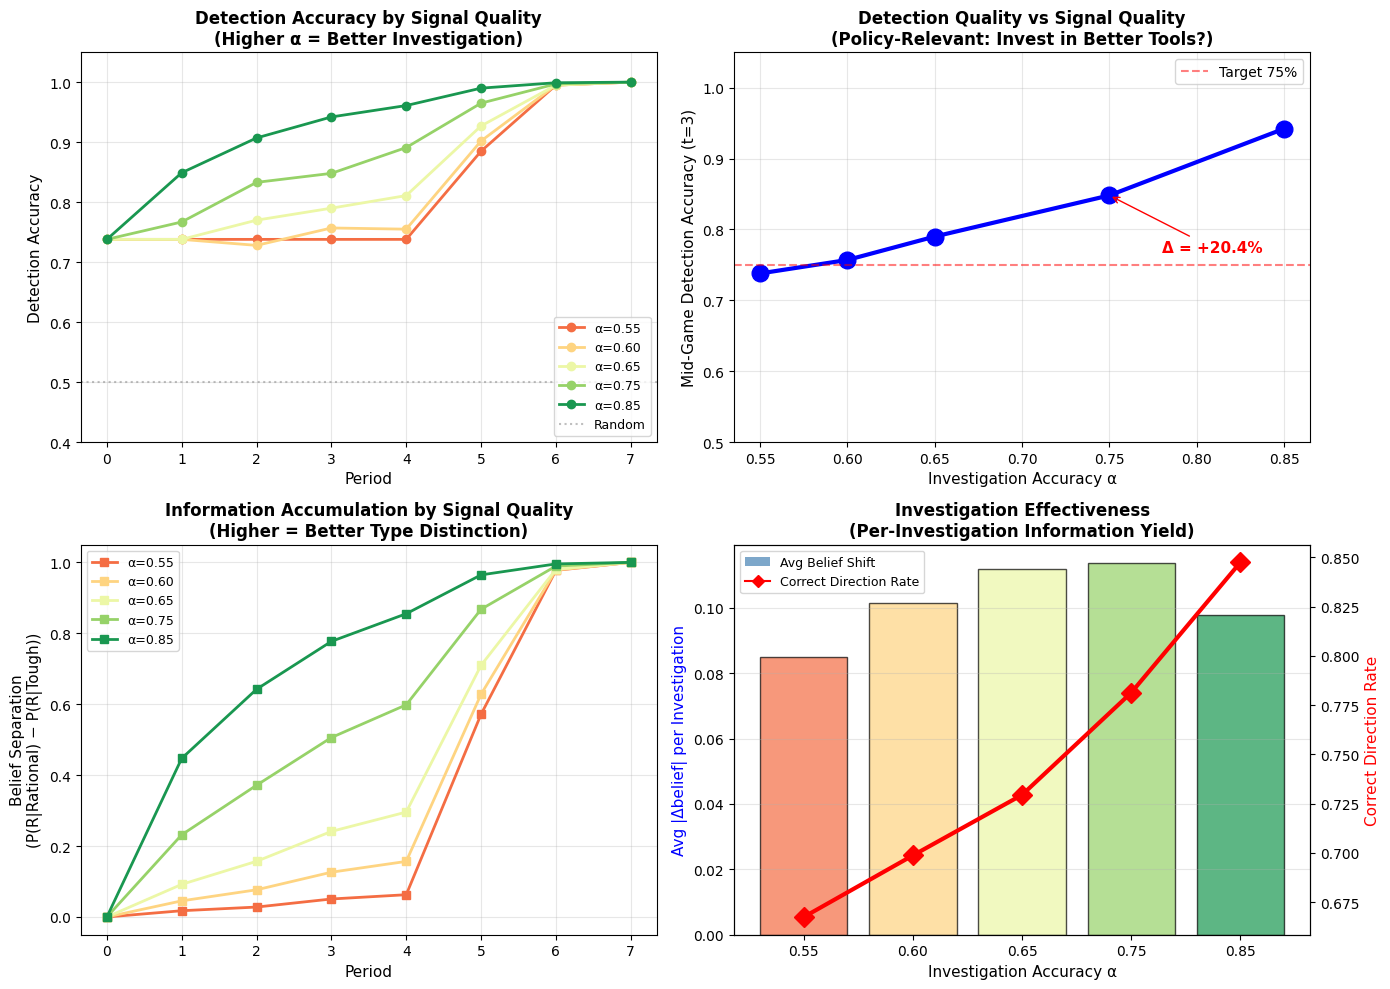


 Comparison plots saved as 'alpha_robustness_comparison.png'
Robustness Check Summary: Investigation Accuracy α
 Investigation Accuracy α  Mid-Game Accuracy (t=3)  Final Accuracy  Belief Sep (t=3)  Avg Belief Shift/Inv  Correct Direction  Early Pooling (t=0-3)  Late Pooling (last 3)
                    0.550                    0.738           1.000             0.051                 0.085              0.667                  0.942                  0.139
                    0.600                    0.757           1.000             0.126                 0.102              0.699                  0.942                  0.139
                    0.650                    0.790           1.000             0.241                 0.112              0.729                  0.942                  0.139
                    0.750                    0.848           1.000             0.506                 0.114              0.781                  0.942                  0.139
                    0.850  

In [26]:
# Robustness Check 7: Investigation Accuracy α

print("Robustness Check 7: Investigation Accuracy α (Signal Quality)")
print("\nEconomic Question: Is detection limited by investigation frequency or signal quality?")
print("Testing accuracy levels: [0.55, 0.60, 0.65, 0.75, 0.85]")
print("  α = 0.55: Barely informative (close to coin flip)")
print("  α = 0.65: Baseline (moderately informative)")
print("  α = 0.85: High-quality forensic investigation\n")

# Test different investigation accuracies
alphas_to_test = [0.55, 0.60, 0.65, 0.75, 0.85]
alpha_results = {}

for alpha in alphas_to_test:
    print(f"Running with Investigation Accuracy α = {alpha:.2f}")
    if alpha <= 0.55:
        print(f"  → Weak Signal (barely better than random)")
    elif alpha >= 0.75:
        print(f"  → Strong Signal (high-quality forensics)")
    else:
        print(f"  → Moderate Signal")

    # Run full analysis with this accuracy
    game, VF_P, VF_D, trajs, results = run_full_analysis(
        grid_resolution=7,
        n_trajectories=1000,
        seed=42,
        prior_rational=0.7,
        reputation_bonus=2.8,
        investigation_cost=1.5,
        T_max=8,
        gamma=0.95,
        rho_demand=0.6,
        investigation_accuracy=alpha  # NEW PARAMETER
    )

    # Calculate pooling metrics
    rational_trajs = [t for t in trajs if t['true_type'] == 1]
    if rational_trajs:
        # Early-game pooling (t=0-3)
        early_fights = 0
        early_total = 0
        for traj in rational_trajs:
            for t in range(min(4, len(traj['incumbent_actions']))):
                if traj['incumbent_actions'][t] == 0:  # Fight
                    early_fights += 1
                early_total += 1
        earlygame_pooling = early_fights / early_total if early_total > 0 else 0

        # Late-game pooling (last 3 periods)
        late_fights = 0
        late_total = 0
        for traj in rational_trajs:
            start_period = max(0, len(traj['incumbent_actions']) - 3)
            for t in range(start_period, len(traj['incumbent_actions'])):
                if traj['incumbent_actions'][t] == 0:  # Fight
                    late_fights += 1
                late_total += 1
        lategame_pooling = late_fights / late_total if late_total > 0 else 0
    else:
        earlygame_pooling = 0
        lategame_pooling = 0

    # Investigation effectiveness
    investigations = []
    for traj in trajs:
        for i, d in enumerate(traj['regulator_actions']):
            if d == 1:
                investigations.append({
                    'true_type': traj['true_type'],
                    'belief_before': traj['beliefs'][i][1],
                    'belief_after': traj['beliefs'][i+1][1],
                    'time': i
                })

    if investigations:
        correct_direction = sum(1 for inv in investigations
                               if (inv['true_type'] == 1 and inv['belief_after'] > inv['belief_before'])
                               or (inv['true_type'] == 0 and inv['belief_after'] < inv['belief_before']))
        realised_inv_accuracy = correct_direction / len(investigations)

        belief_changes = [abs(inv['belief_after'] - inv['belief_before']) for inv in investigations]
        avg_belief_shift = np.mean(belief_changes)
    else:
        realised_inv_accuracy = 0
        avg_belief_shift = 0

    # Get mid-game accuracy (t=3)
    midgame_accuracy = results['detection_accuracy'][3] if len(results['detection_accuracy']) > 3 else results['detection_accuracy'][-1]

    # Calculate belief separation at t=3
    belief_sep_t3 = (results['belief_rational_mean'][3] - results['belief_tough_mean'][3]) if len(results['belief_rational_mean']) > 3 else 0

    # Store results
    alpha_results[alpha] = {
        'game': game,
        'detection_accuracy': results['detection_accuracy'],
        'belief_tough_mean': results['belief_tough_mean'],
        'belief_rational_mean': results['belief_rational_mean'],
        'earlygame_pooling': earlygame_pooling,
        'lategame_pooling': lategame_pooling,
        'unraveling_intensity': earlygame_pooling - lategame_pooling,
        'midgame_accuracy': midgame_accuracy,
        'final_accuracy': results['detection_accuracy'][-1],
        'realised_inv_accuracy': realised_inv_accuracy,
        'avg_belief_shift': avg_belief_shift,
        'belief_sep_t3': belief_sep_t3
    }

    print(f"\n Completed α={alpha:.2f}")
    print(f"   Mid-game accuracy (t=3): {midgame_accuracy:.1%}")
    print(f"   Final accuracy: {results['detection_accuracy'][-1]:.1%}")
    print(f"   Realised inv accuracy: {realised_inv_accuracy:.1%}")
    print(f"   Avg belief shift/inv: {avg_belief_shift:.4f}")
    print(f"   Belief separation (t=3): {belief_sep_t3:.3f}")
    print(f"   Early pooling (t=0-3): {earlygame_pooling:.1%}")


# Visualize investigation accuracy comparisons
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(alphas_to_test)))

# Plot 1: Detection Accuracy Over Time
ax = axes[0, 0]
for alpha, color in zip(alphas_to_test, colors):
    acc = alpha_results[alpha]['detection_accuracy']
    periods = range(len(acc))
    ax.plot(periods, acc, marker='o', label=f'α={alpha:.2f}',
            color=color, linewidth=2, markersize=6)

ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Random')
ax.set_xlabel('Period', fontsize=11)
ax.set_ylabel('Detection Accuracy', fontsize=11)
ax.set_title('Detection Accuracy by Signal Quality\n(Higher α = Better Investigation)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.4, 1.05])

# Plot 2: Mid-Game Accuracy vs Alpha (THE KEY PLOT)
ax = axes[0, 1]
midgame_accs = [alpha_results[a]['midgame_accuracy'] for a in alphas_to_test]

ax.plot(alphas_to_test, midgame_accs, marker='o', color='blue',
        linewidth=3, markersize=12)

# Add annotation showing improvement
improvement = midgame_accs[-1] - midgame_accs[0]
ax.annotate(f'Δ = {improvement:+.1%}',
           xy=(0.75, midgame_accs[3]),
           xytext=(0.78, midgame_accs[3] - 0.08),
           arrowprops=dict(arrowstyle='->', color='red'),
           fontsize=11, color='red', fontweight='bold')

ax.set_xlabel('Investigation Accuracy α', fontsize=11)
ax.set_ylabel('Mid-Game Detection Accuracy (t=3)', fontsize=11)
ax.set_title('Detection Quality vs Signal Quality\n(Policy-Relevant: Invest in Better Tools?)',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 1.05])
ax.axhline(y=0.75, color='red', linestyle='--', alpha=0.5, label='Target 75%')
ax.legend()

# Plot 3: Belief Separation Over Time
ax = axes[1, 0]
for alpha, color in zip(alphas_to_test, colors):
    belief_tough = np.array(alpha_results[alpha]['belief_tough_mean'])
    belief_rational = np.array(alpha_results[alpha]['belief_rational_mean'])
    separation = belief_rational - belief_tough
    periods = range(len(separation))
    ax.plot(periods, separation, marker='s', label=f'α={alpha:.2f}',
            color=color, linewidth=2, markersize=6)

ax.set_xlabel('Period', fontsize=11)
ax.set_ylabel('Belief Separation\n(P(R|Rational) − P(R|Tough))', fontsize=11)
ax.set_title('Information Accumulation by Signal Quality\n(Higher = Better Type Distinction)',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 4: Average Belief Shift per Investigation
ax = axes[1, 1]
belief_shifts = [alpha_results[a]['avg_belief_shift'] for a in alphas_to_test]
realised_accs = [alpha_results[a]['realised_inv_accuracy'] for a in alphas_to_test]

ax2 = ax.twinx()

line1 = ax.bar(range(len(alphas_to_test)), belief_shifts,
               color=colors, alpha=0.7, edgecolor='black', label='Avg Belief Shift')
line2 = ax2.plot(range(len(alphas_to_test)), realised_accs, 'r-D',
                 linewidth=3, markersize=10, label='Correct Direction Rate')

ax.set_xlabel('Investigation Accuracy α', fontsize=11)
ax.set_ylabel('Avg |Δbelief| per Investigation', fontsize=11, color='blue')
ax2.set_ylabel('Correct Direction Rate', fontsize=11, color='red')
ax.set_title('Investigation Effectiveness\n(Per-Investigation Information Yield)',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(len(alphas_to_test)))
ax.set_xticklabels([f'{a:.2f}' for a in alphas_to_test])
ax.grid(True, alpha=0.3, axis='y')

# Combined legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', alpha=0.7, label='Avg Belief Shift'),
                   plt.Line2D([0], [0], color='red', marker='D', label='Correct Direction Rate')]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('alpha_robustness_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Comparison plots saved as 'alpha_robustness_comparison.png'")

# Summary table
summary_data = []
for alpha in alphas_to_test:
    results = alpha_results[alpha]

    row = {
        'Investigation Accuracy α': alpha,
        'Mid-Game Accuracy (t=3)': results['midgame_accuracy'],
        'Final Accuracy': results['final_accuracy'],
        'Belief Sep (t=3)': results['belief_sep_t3'],
        'Avg Belief Shift/Inv': results['avg_belief_shift'],
        'Correct Direction': results['realised_inv_accuracy'],
        'Early Pooling (t=0-3)': results['earlygame_pooling'],
        'Late Pooling (last 3)': results['lategame_pooling']
    }
    summary_data.append(row)

df_alpha = pd.DataFrame(summary_data)

print("Robustness Check Summary: Investigation Accuracy α")
print(df_alpha.to_string(index=False, float_format='%.3f'))

# Economic interpretation
print("\nEconomic Interpretation:")

weak_signal = df_alpha[df_alpha['Investigation Accuracy α'] <= 0.55]
baseline = df_alpha[df_alpha['Investigation Accuracy α'] == 0.65]
strong_signal = df_alpha[df_alpha['Investigation Accuracy α'] >= 0.75]

if len(weak_signal) > 0:
    print(f"\n  Weak Signal (α ≤ 0.55):")
    print(f"    Mid-game accuracy:  {weak_signal['Mid-Game Accuracy (t=3)'].mean():.1%}")
    print(f"    Belief separation:  {weak_signal['Belief Sep (t=3)'].mean():.3f}")
    print(f"    Per-inv shift:      {weak_signal['Avg Belief Shift/Inv'].mean():.4f}")
    print(f"    → Near-random signal yields minimal information per investigation")

if len(baseline) > 0:
    print(f"\n  BASELINE (α = 0.65):")
    print(f"    Mid-game accuracy:  {baseline['Mid-Game Accuracy (t=3)'].iloc[0]:.1%}")
    print(f"    Belief separation:  {baseline['Belief Sep (t=3)'].iloc[0]:.3f}")

if len(strong_signal) > 0:
    print(f"\n  Strong Signal (α ≥ 0.75):")
    print(f"    Mid-game accuracy:  {strong_signal['Mid-Game Accuracy (t=3)'].mean():.1%}")
    print(f"    Belief separation:  {strong_signal['Belief Sep (t=3)'].mean():.3f}")
    print(f"    Per-inv shift:      {strong_signal['Avg Belief Shift/Inv'].mean():.4f}")
    print(f"    → High-quality forensics dramatically accelerate type separation")

# Compare cost vs accuracy effect
print("\n  Cost vs Quality Comparison:")
print(f"    Investigation cost range [0.5, 3.0]: Detection accuracy unchange (100% investigation)")
print(f"    Investigation accuracy range [{alphas_to_test[0]}, {alphas_to_test[-1]}]:", end=" ")
acc_range = max(r['midgame_accuracy'] for r in alpha_results.values()) - min(r['midgame_accuracy'] for r in alpha_results.values())
print(f"Mid-game accuracy varies by {acc_range:.1%}")

if acc_range > 0.05:
    print(f"\n  Key Finding: Signal quality affects detection; investigation cost does not.")
    print(f"    → The binding constraint is information QUALITY, not investigation FREQUENCY.")
    print(f"    → Policy implication: invest in better forensic tools, not more frequent audits.")
else:
    print(f"\n  ⚠ Signal quality has limited effect in tested range.")
    print(f"    → Detection driven primarily by end-game unraveling, not investigation signals.")

# Monotonicity check
detection_improves = all(df_alpha['Mid-Game Accuracy (t=3)'].iloc[i] <=
                        df_alpha['Mid-Game Accuracy (t=3)'].iloc[i+1] + 0.02
                        for i in range(len(df_alpha)-1))

if detection_improves:
    print(f"\n   Monotonicity: Detection accuracy increases with signal quality")
else:
    print(f"\n   Non-monotonic relationship (investigate parameter interactions)")

# Pooling response
pooling_changes = max(r['earlygame_pooling'] for r in alpha_results.values()) - min(r['earlygame_pooling'] for r in alpha_results.values())
if pooling_changes < 0.05:
    print(f"   Pooling Robust: Early-game pooling insensitive to α (varies by {pooling_changes:.1%})")
    print(f"    → Reputation incentive dominates regardless of investigation quality")
else:
    print(f"  → Pooling responds to α (varies by {pooling_changes:.1%})")
    print(f"    → Better investigation deters some pooling (strategic substitution)")

df_alpha.to_csv('alpha_robustness_summary.csv', index=False)
print("\n Summary saved as 'alpha_robustness_summary.csv'")